# RQ1: Semantic Entropy and Linguistic Predictors in Clinical Concept Normalisation
## SIT723 - masters Research Techniques and Applications

**Research Question:**
Which linguistic properties of meaning-preserving perturbations -
perturbation type, magnitude of lexical change, and grammatical
category of modified tokens - are the strongest independent predictors
of semantic entropy in clinical LLM outputs, and do these predictors interact?

**Sub-questions:**
- **SQ1:** How does Ĥ vary across perturbation types (back-translation,
  controlled paraphrase, synonym substitution, syntactic reordering)?
- **SQ2:** Does normalised Levenshtein magnitude independently predict Ĥ?
- **SQ3:** Do grammatical categories differ in entropy, and does a
  Type × Category interaction exist?

**Pipeline:** MedMentions ST21pv · N=550 · k=8 perturbations per instance
· Six-gate validation · BERT-base / BioBERT / PubMedBERT (110M each)
· UMLS-KB cosine similarity CUI assignment · MixedLM REML
· BH-FDR q=0.05 · Bootstrap B=1,000

**Scope note:** Generative models (RQ2) and SQuAD/BioASQ datasets (RQ3)
are excluded from this notebook. This notebook addresses RQ1 only.

## 1) Environment Setup

This section imports required libraries, configures deterministic seeds, checks hardware availability, and prepares the output directory structure for all RQ1 artefacts.

In [1]:
# ============================================================
# Environment Setup for RQ1 Semantic Entropy Notebook
# ============================================================
# This setup is designed for the current VM:
# - PyTorch / Transformers can use GPU if available.
# - spaCy / SciSpaCy will run on CPU because CuPy/CUDA runtime
#   is not correctly available on the VM.
# ============================================================

import subprocess
import sys
import importlib.util
import importlib.metadata

# ------------------------------------------------------------
# Helper function: install package only if missing
# ------------------------------------------------------------
def install_if_missing(import_name, pip_name=None):
    """
    Installs a package only if it is not already available.
    import_name = package name used in Python import
    pip_name    = package name used in pip install
    """
    if pip_name is None:
        pip_name = import_name

    if importlib.util.find_spec(import_name) is None:
        print(f"Installing {pip_name} ...")
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q", pip_name],
            check=False
        )
    else:
        print(f"✓ {import_name} already installed")


# ------------------------------------------------------------
# Core packages
# ------------------------------------------------------------
_required_packages = [
    ("numpy", "numpy==1.26.4"),
    ("pandas", "pandas"),
    ("scipy", "scipy"),
    ("statsmodels", "statsmodels"),
    ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"),
    ("sklearn", "scikit-learn"),
    ("transformers", "transformers"),
    ("torch", "torch"),
    ("Levenshtein", "python-Levenshtein"),
    ("nltk", "nltk"),
    ("spacy", "spacy==3.7.5"),
    ("scispacy", "scispacy==0.5.4"),
    ("sentence_transformers", "sentence-transformers"),
]

for import_name, pip_name in _required_packages:
    install_if_missing(import_name, pip_name)


# ------------------------------------------------------------
# Install SciSpaCy model if missing
# ------------------------------------------------------------
if importlib.util.find_spec("en_core_sci_md") is not None:
    print("✓ en_core_sci_md already installed.")
else:
    print("Installing en_core_sci_md ...")

    # This model version matches scispacy==0.5.4 and spaCy 3.7.x.
    sci_model_url = (
        "https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/"
        "v0.5.4/en_core_sci_md-0.5.4.tar.gz"
    )

    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", sci_model_url],
        capture_output=True,
        text=True
    )

    if result.returncode == 0:
        print("✓ en_core_sci_md installed successfully.")
    else:
        print("[WARN] en_core_sci_md installation failed.")
        print(result.stderr[:500])


# ------------------------------------------------------------
# Install standard spaCy English model if missing
# ------------------------------------------------------------
if importlib.util.find_spec("en_core_web_sm") is not None:
    print("✓ en_core_web_sm already installed.")
else:
    print("Installing en_core_web_sm ...")
    subprocess.run(
        [sys.executable, "-m", "spacy", "download", "en_core_web_sm"],
        check=False
    )


# ------------------------------------------------------------
# NLTK data
# ------------------------------------------------------------
import nltk

_nltk_resources = {
    "corpora/wordnet": "wordnet",
    "corpora/omw-1.4": "omw-1.4",
    "tokenizers/punkt": "punkt",
    "taggers/averaged_perceptron_tagger": "averaged_perceptron_tagger",
}

for resource_path, download_name in _nltk_resources.items():
    try:
        nltk.data.find(resource_path)
        print(f"✓ NLTK resource available: {download_name}")
    except LookupError:
        print(f"Downloading NLTK resource: {download_name}")
        nltk.download(download_name, quiet=True)

print("✓ Environment package check complete.")


# ============================================================
# Core Imports
# ============================================================

import os
import re
import io
import gc
import json
import math
import time
import glob
import random
import zipfile
import warnings
import pathlib
import datetime as dt
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning / NLP support
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import kruskal
import scipy.stats as stats

# Statistical modelling
import statsmodels.api as sm
import statsmodels.formula.api as smf


# ============================================================
# Optional Heavy Libraries
# ============================================================

try:
    import torch
    TORCH_AVAILABLE = True
except Exception as e:
    print(f"[WARN] PyTorch unavailable: {e}")
    TORCH_AVAILABLE = False

try:
    import transformers
    from transformers import AutoTokenizer, AutoModel, pipeline
    TRANSFORMERS_AVAILABLE = True
except Exception as e:
    print(f"[WARN] Transformers unavailable: {e}")
    TRANSFORMERS_AVAILABLE = False

try:
    import spacy
    SPACY_AVAILABLE = True
except Exception as e:
    print(f"[WARN] spaCy unavailable: {e}")
    SPACY_AVAILABLE = False


# ============================================================
# Reproducibility
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

if TORCH_AVAILABLE:
    torch.manual_seed(SEED)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)


# ============================================================
# Device Detection
# ============================================================
# Important:
# PyTorch/Transformers can use GPU on this VM.
# spaCy/SciSpaCy should stay on CPU because CuPy/CUDA runtime
# is currently not properly available.

DEVICE = "cpu"

if TORCH_AVAILABLE and torch.cuda.is_available():
    DEVICE = "cuda"

SPACY_DEVICE = "cpu"

print(f"Running PyTorch/Transformers on: {DEVICE}")
print(f"Running spaCy/SciSpaCy on: {SPACY_DEVICE}")

if TORCH_AVAILABLE and torch.cuda.is_available():
    print(f"GPU detected: {torch.cuda.get_device_name(0)}")
    print(f"Number of GPUs available to PyTorch: {torch.cuda.device_count()}")


# ============================================================
# Project Root Detection
# ============================================================

def detect_project_root(start_path: pathlib.Path) -> pathlib.Path:
    """
    Resolve project root robustly by locating the Datasets directory.
    This allows the notebook to run from either the project root or
    a notebooks/ subfolder.
    """
    start_path = start_path.resolve()

    # Case 1: current folder is project root.
    if (start_path / "Datasets").exists():
        return start_path

    # Case 2: parent is project root.
    if (start_path.parent / "Datasets").exists():
        return start_path.parent

    # Case 3: search all ancestors upward.
    for p in [start_path] + list(start_path.parents):
        if (p / "Datasets").exists():
            return p

    raise FileNotFoundError(
        f"Could not detect project root from {start_path}; "
        "no ancestor contains a 'Datasets' folder."
    )


# Detect project folders
PROJECT_ROOT = detect_project_root(pathlib.Path.cwd())
DATASETS_DIR = PROJECT_ROOT / "Datasets"

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "rq1"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR = OUTPUT_DIR / "figures"
INTERMEDIATE_DIR = OUTPUT_DIR / "intermediate"

# Create output folders if missing
for path in [OUTPUT_DIR, TABLES_DIR, FIGURES_DIR, INTERMEDIATE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print(f"Detected PROJECT_ROOT: {PROJECT_ROOT}")
print(f"Detected DATASETS_DIR: {DATASETS_DIR}")
print("Output folders prepared:")
print(f"- {OUTPUT_DIR}")
print(f"- {TABLES_DIR}")
print(f"- {FIGURES_DIR}")
print(f"- {INTERMEDIATE_DIR}")


# ============================================================
# Runtime Configuration
# ============================================================

FULL_RUN = False

PILOT_N = 550
FULL_TARGET_N = 550
BUFFER_N = 55

K_PERTURB = 8
MAX_REGEN_ATTEMPTS = 3

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")


# ============================================================
# Extra Dependencies for Transformers
# ============================================================

_extra_packages = [
    ("sentencepiece", "sentencepiece"),
    ("google.protobuf", "protobuf"),
    ("sacremoses", "sacremoses"),
    ("accelerate", "accelerate"),
    ("tokenizers", "tokenizers"),
]

for import_name, pip_name in _extra_packages:
    try:
        install_if_missing(import_name, pip_name)
    except Exception as e:
        print(f"[WARN] Could not install {pip_name}: {e}")

print("✓ Dependency check complete.")

✓ numpy already installed
✓ pandas already installed
✓ scipy already installed
✓ statsmodels already installed
✓ matplotlib already installed
✓ seaborn already installed
✓ sklearn already installed
✓ transformers already installed
✓ torch already installed
✓ Levenshtein already installed
✓ nltk already installed
✓ spacy already installed
✓ scispacy already installed
✓ sentence_transformers already installed
✓ en_core_sci_md already installed.
✓ en_core_web_sm already installed.
✓ NLTK resource available: punkt
✓ NLTK resource available: averaged_perceptron_tagger
✓ Environment package check complete.
Running PyTorch/Transformers on: cuda
Running spaCy/SciSpaCy on: cpu
GPU detected: NVIDIA RTX A4000
Number of GPUs available to PyTorch: 2
Detected PROJECT_ROOT: /home/situser1/Entropy
Detected DATASETS_DIR: /home/situser1/Entropy/Datasets
Output folders prepared:
- /home/situser1/Entropy/outputs/rq1
- /home/situser1/Entropy/outputs/rq1/tables
- /home/situser1/Entropy/outputs/rq1/figures
-

### 1b) scispaCy Import Verification
Confirms scispaCy is importable in the notebook kernel.
Note: `spacy.load()` is NOT called here - model loading
runs in an isolated subprocess in Section 8 to avoid
the CUDA/OpenMP conflict with PyTorch.

In [2]:
# This is safe in Cell 02 - just checks installation
import scispacy  # registers factories, no model loading
from scispacy.linking import EntityLinker
print("scispaCy importable:", True)

scispaCy importable: True


Your CPU supports instructions that this binary was not compiled to use: SSE3 SSE4.1 SSE4.2
For maximum performance, you can install NMSLIB from sources 
pip install --no-binary :all: nmslib


## 2) Programmatic Dataset Inspection and Adaptive Path Discovery

As required, we inspect the dataset directory structure first and automatically discover likely MedMentions assets before parsing.

In [3]:
# Inspect dataset files and extract MedMentions zip if needed.
all_dataset_items = sorted([str(p) for p in DATASETS_DIR.glob("*")])
print("Datasets directory items:")
for item in all_dataset_items:
    print(" -", item)

medmentions_zip_candidates = [p for p in DATASETS_DIR.glob("*MedMentions*.zip")]
if not medmentions_zip_candidates:
    raise FileNotFoundError("No MedMentions zip file found in Datasets directory.")
MEDMENTIONS_ZIP = medmentions_zip_candidates[0]
print(f"Detected MedMentions zip: {MEDMENTIONS_ZIP}")

MEDMENTIONS_EXTRACT_DIR = DATASETS_DIR / "MedMentions_extracted"
if not MEDMENTIONS_EXTRACT_DIR.exists() or not any(MEDMENTIONS_EXTRACT_DIR.rglob("*")):
    print("Extracting MedMentions archive...")
    MEDMENTIONS_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(MEDMENTIONS_ZIP, "r") as zf:
        zf.extractall(MEDMENTIONS_EXTRACT_DIR)
else:
    print("Using existing extracted MedMentions directory.")

# Show a concise file inventory to support adaptive parsing.
extracted_files = [p for p in MEDMENTIONS_EXTRACT_DIR.rglob("*") if p.is_file()]
print(f"Total extracted files: {len(extracted_files)}")
for p in extracted_files[:40]:
    print(" -", p.relative_to(MEDMENTIONS_EXTRACT_DIR))
if len(extracted_files) > 40:
    print(" ... (truncated)")

Datasets directory items:
 - /home/situser1/Entropy/Datasets/BioASQ-training13b.zip
 - /home/situser1/Entropy/Datasets/MedMentions-master.zip
 - /home/situser1/Entropy/Datasets/MedMentions_extracted
 - /home/situser1/Entropy/Datasets/SQuAD2.0
Detected MedMentions zip: /home/situser1/Entropy/Datasets/MedMentions-master.zip
Using existing extracted MedMentions directory.
Total extracted files: 11
 - MedMentions-master/README.md
 - MedMentions-master/.gitignore
 - MedMentions-master/st21pv/ReadMe.md
 - MedMentions-master/st21pv/data/corpus_pubtator.txt.gz
 - MedMentions-master/full/ReadMe.md
 - MedMentions-master/full/stats/TypeMentionStats.xlsx
 - MedMentions-master/full/data/corpus_pubtator_pmids_dev.txt
 - MedMentions-master/full/data/corpus_pubtator_pmids_test.txt
 - MedMentions-master/full/data/corpus_pubtator_pmids_trng.txt
 - MedMentions-master/full/data/corpus_pubtator.txt.gz
 - MedMentions-master/full/data/corpus_pubtator_pmids_all.txt


## 3) MedMentions Loading and Best-Effort Parsing

The parser prioritises PubTator-style files (commonly used in MedMentions) and extracts mentions with document context. If exact schema differences occur, the parser logs warnings and retains robust fallback fields.

In [4]:
# Parse MedMentions into a research-ready dataframe with mention-level context windows.
def detect_pubtator_files(root_dir: pathlib.Path):
    """Detect likely PubTator files for MedMentions parsing."""
    candidates = []
    patterns = ["*corpus_pubtator.txt.gz", "*pubtator*", "*corpus*", "*st21pv*", "*.txt", "*.gz"]
    for pat in patterns:
        candidates.extend(root_dir.rglob(pat))
    candidates = [p for p in candidates if p.is_file()]

    scored = []
    for p in candidates:
        s = str(p).lower()
        score = 0
        if "pubtator" in s:
            score += 4
        if "medmentions" in s:
            score += 3
        if "corpus" in s:
            score += 2
        if "st21pv" in s:
            score += 2
        if p.suffix == ".txt":
            score += 1
        scored.append((score, p))
    scored.sort(key=lambda x: x[0], reverse=True)
    return [p for _, p in scored]


def split_sentences(text):
    """Lightweight sentence segmentation fallback."""
    return [s.strip() for s in re.split(r"(?<=[.!?])\s+", str(text).strip()) if s.strip()]


def mention_context_from_char_span(full_text, mention, char_start, char_end, window_tokens=40):
    """Create mention-level context using sentence containing mention or token window fallback."""
    text = str(full_text)
    mention = str(mention).strip()

    # First attempt: use character offsets if valid.
    has_span = pd.notna(char_start) and pd.notna(char_end)
    if has_span:
        try:
            char_start = int(char_start)
            char_end = int(char_end)
        except Exception:
            has_span = False

    # Sentence-based extraction.
    sents = split_sentences(text)
    if sents:
        if has_span and 0 <= char_start < len(text):
            acc = 0
            for sent in sents:
                sent_start = text.find(sent, acc)
                sent_end = sent_start + len(sent)
                acc = max(acc, sent_end)
                if sent_start <= char_start < sent_end:
                    return sent
        if mention:
            for sent in sents:
                if mention.lower() in sent.lower():
                    return sent

    # Fallback: token window around mention/token span.
    tokens = re.findall(r"\S+", text)
    if not tokens:
        return text

    mention_tokens = re.findall(r"\S+", mention)
    if mention_tokens:
        ml = len(mention_tokens)
        lower_tokens = [t.lower() for t in tokens]
        lower_m = [t.lower() for t in mention_tokens]
        idx = None
        for i in range(0, len(tokens) - ml + 1):
            if lower_tokens[i:i+ml] == lower_m:
                idx = i
                break
        if idx is not None:
            left = max(0, idx - window_tokens)
            right = min(len(tokens), idx + ml + window_tokens)
            return " ".join(tokens[left:right])

    # Last fallback: central window.
    mid = len(tokens) // 2
    left = max(0, mid - window_tokens)
    right = min(len(tokens), mid + window_tokens)
    return " ".join(tokens[left:right])


def parse_pubtator_file(file_path: pathlib.Path):
    """Parse a PubTator-format file into mention-level records."""
    import gzip
    records = []

    if str(file_path).lower().endswith(".gz"):
        fh = gzip.open(file_path, "rt", encoding="utf-8", errors="replace")
    else:
        fh = open(file_path, "r", encoding="utf-8", errors="replace")

    with fh as f:
        block = []
        for line in f:
            line = line.rstrip("\n")
            if line == "":
                if block:
                    recs = parse_pubtator_block(block)
                    records.extend(recs)
                    block = []
            else:
                block.append(line)
        if block:
            recs = parse_pubtator_block(block)
            records.extend(recs)
    return records


def parse_pubtator_block(lines):
    """Parse one PubTator document block with title/abstract and annotations."""
    doc_id = None
    title = ""
    abstract = ""
    ann_lines = []

    for ln in lines:
        if "|t|" in ln:
            parts = ln.split("|t|", 1)
            doc_id = parts[0].strip()
            title = parts[1].strip() if len(parts) > 1 else ""
        elif "|a|" in ln:
            parts = ln.split("|a|", 1)
            if doc_id is None:
                doc_id = parts[0].strip()
            abstract = parts[1].strip() if len(parts) > 1 else ""
        else:
            ann_lines.append(ln)

    full_text = (title + " " + abstract).strip()
    if not ann_lines:
        return []

    out = []
    for ann in ann_lines:
        parts = ann.split("\t")
        if len(parts) >= 4:
            try:
                ann_doc = parts[0]
                start = int(parts[1]) if parts[1].isdigit() else np.nan
                end = int(parts[2]) if parts[2].isdigit() else np.nan
                mention = parts[3].strip()
                semtype = parts[4].strip() if len(parts) > 4 else None
                cui = parts[5].strip() if len(parts) > 5 else None

                mention_context = mention_context_from_char_span(
                    full_text=full_text,
                    mention=mention,
                    char_start=start,
                    char_end=end,
                    window_tokens=40,
                )

                out.append({
                    "document_id": ann_doc if ann_doc else doc_id,
                    "pmid": ann_doc if ann_doc else doc_id,
                    "title": title,
                    "abstract": abstract,
                    "full_original_text": full_text,
                    "mention_context": mention_context,
                    "gold_mention": mention,
                    "gold_cui": cui,
                    "semantic_type": semtype,
                    "mention_start": start,
                    "mention_end": end,
                })
            except Exception as e:
                print(f"[WARN] Failed to parse annotation line: {ann[:120]} | error: {e}")
    return out


pubtator_files = detect_pubtator_files(MEDMENTIONS_EXTRACT_DIR)
if not pubtator_files:
    raise RuntimeError("Could not detect any likely MedMentions text files.")

# Prefer st21pv corpus_pubtator.txt.gz for RQ1.
st21_gz = [p for p in pubtator_files if p.name == "corpus_pubtator.txt.gz" and "st21pv" in str(p).lower()]
if st21_gz:
    pubtator_files = st21_gz + [p for p in pubtator_files if p not in st21_gz]

print("Top candidate MedMentions files:")
for p in pubtator_files[:10]:
    print(" -", p.relative_to(MEDMENTIONS_EXTRACT_DIR))

all_records = []
for p in pubtator_files[:3]:
    try:
        recs = parse_pubtator_file(p)
        if recs:
            print(f"Parsed {len(recs)} mention records from: {p.name}")
            all_records.extend(recs)
            if p.name == "corpus_pubtator.txt.gz":
                break
    except Exception as e:
        print(f"[WARN] Parser issue for {p}: {e}")

if not all_records:
    raise RuntimeError(
        "Best-effort parser could not extract MedMentions records. "
        "Please inspect extracted files and adapt parser rules."
    )

def corrupted_ratio(s):
    txt = str(s)
    if not txt:
        return 1.0
    non_print = sum(1 for ch in txt if (ord(ch) < 32 and ch not in "\t\n\r") or ord(ch) > 126)
    return non_print / max(len(txt), 1)

def readable_biomed(s):
    txt = str(s)
    if len(txt.strip()) < 2:
        return False
    return bool(re.search(r"[A-Za-z]", txt)) and corrupted_ratio(txt) <= 0.20

df_med = pd.DataFrame(all_records).drop_duplicates().reset_index(drop=True)

# Validation checks for parsed text quality.
df_med["pmid"] = df_med["pmid"].astype(str)
mask_pmid = df_med["pmid"].str.fullmatch(r"\d+")
mask_mention = df_med["gold_mention"].fillna("").apply(readable_biomed)
mask_context = df_med["mention_context"].fillna("").apply(readable_biomed)
mask_quality = mask_pmid & mask_mention & mask_context

n_before = len(df_med)
df_med = df_med[mask_quality].copy().reset_index(drop=True)

if len(df_med) == 0:
    raise RuntimeError("All parsed MedMentions rows failed quality checks; corpus likely decoded incorrectly.")

df_med.insert(0, "instance_id", [f"mm_{i:07d}" for i in range(len(df_med))])

for col in ["document_id", "pmid", "title", "abstract", "mention_context", "full_original_text", "gold_mention", "gold_cui", "semantic_type", "mention_start", "mention_end"]:
    if col not in df_med.columns:
        df_med[col] = None

# Keep backward-compatible alias but use mention_context as operative input.
df_med["original_text"] = df_med["mention_context"]

print(f"MedMentions rows before quality filter: {n_before:,}")
print(f"MedMentions rows after quality filter:  {len(df_med):,}")
print("Examples of 10 parsed rows (before sampling):")
display(df_med[["instance_id", "pmid", "gold_mention", "gold_cui", "semantic_type", "mention_start", "mention_end", "mention_context"]].head(10))

Top candidate MedMentions files:
 - MedMentions-master/st21pv/data/corpus_pubtator.txt.gz
 - MedMentions-master/st21pv/data/corpus_pubtator.txt.gz
 - MedMentions-master/st21pv/data/corpus_pubtator.txt.gz
 - MedMentions-master/st21pv/data/corpus_pubtator.txt.gz
 - MedMentions-master/full/data/corpus_pubtator_pmids_dev.txt
 - MedMentions-master/full/data/corpus_pubtator_pmids_test.txt
 - MedMentions-master/full/data/corpus_pubtator_pmids_trng.txt
 - MedMentions-master/full/data/corpus_pubtator_pmids_all.txt
 - MedMentions-master/full/data/corpus_pubtator_pmids_dev.txt
 - MedMentions-master/full/data/corpus_pubtator_pmids_test.txt
Parsed 203282 mention records from: corpus_pubtator.txt.gz
MedMentions rows before quality filter: 203,192
MedMentions rows after quality filter:  202,287
Examples of 10 parsed rows (before sampling):


,instance_id,pmid,gold_mention,gold_cui,semantic_type,mention_start,mention_end,mention_context
0,mm_0000000,25763772,DCTN4,UMLS:C4308010,T103,0,5,DCTN4 as a modifier of chronic Pseudomonas aer...
1,mm_0000001,25763772,chronic Pseudomonas aeruginosa infection,UMLS:C0854135,T038,23,63,DCTN4 as a modifier of chronic Pseudomonas aer...
2,mm_0000002,25763772,cystic fibrosis,UMLS:C0010674,T038,67,82,DCTN4 as a modifier of chronic Pseudomonas aer...
3,mm_0000003,25763772,Pseudomonas aeruginosa (Pa) infection,UMLS:C0854135,T038,83,120,DCTN4 as a modifier of chronic Pseudomonas aer...
4,mm_0000004,25763772,cystic fibrosis,UMLS:C0010674,T038,124,139,DCTN4 as a modifier of chronic Pseudomonas aer...
5,mm_0000005,25763772,CF,UMLS:C0010674,T038,141,143,DCTN4 as a modifier of chronic Pseudomonas aer...
6,mm_0000006,25763772,pulmonary disease,UMLS:C0024115,T038,189,206,DCTN4 as a modifier of chronic Pseudomonas aer...
7,mm_0000007,25763772,chronic Pa infection,UMLS:C0854135,T038,233,253,DCTN4 as a modifier of chronic Pseudomonas aer...
8,mm_0000008,25763772,CPA,UMLS:C0854135,T038,255,258,DCTN4 as a modifier of chronic Pseudomonas aer...
9,mm_0000009,25763772,faster rate of lung decline,UMLS:C3160731,T033,302,329,DCTN4 as a modifier of chronic Pseudomonas aer...


## 4) Pilot and Full-Run Sampling

Samples a fixed number of instances from the parsed MedMentions
corpus for reproducible analysis. Two modes are supported:

| Mode | PILOT_N | FULL_RUN | Purpose |
|---|---|---|---|
| Pilot validation | 100 | False | Validate pipeline correctness (~20 min) |
| Full pre-registered run | 550 | False | Primary analysis (~2.5 hrs on GPU) |

**What this cell does:**
- Randomly samples N instances using SEED=42 for reproducibility
- Stratifies across document types where possible
- Saves sampled instances to `rq1_sampled_instances.csv`
- This CSV is read by the UMLS pool builder in Section 8a

**Pre-registered sample size:** N = 550 clinical mentions from
MedMentions ST21pv (PubMed abstracts with gold UMLS annotations).

In [5]:
# Sample instances for pilot/full execution.
def sample_instances(df, full_run=True, pilot_n=100, full_target=550, buffer_n=55, seed=42):
    """Sample unique mention-context rows for RQ1 experiments."""
    target_n = full_target + buffer_n if full_run else pilot_n
    target_n = min(target_n, len(df))

    # Filter rows with minimally usable mention-level context and mention fields.
    eligible = df[
        df["mention_context"].fillna("").str.len().ge(20)
        & df["gold_mention"].fillna("").str.len().ge(2)
    ].copy()

    if len(eligible) < target_n:
        print(f"[WARN] Eligible rows ({len(eligible)}) < target ({target_n}); using all eligible rows.")
        sampled = eligible.copy()
    else:
        sampled = eligible.sample(n=target_n, random_state=seed).copy()

    sampled = sampled.reset_index(drop=True)
    sampled["sample_mode"] = "full" if full_run else "pilot"
    sampled["sample_target_n"] = target_n
    sampled["original_text"] = sampled["mention_context"]
    return sampled


df_sampled = sample_instances(
    df_med,
    full_run=FULL_RUN,
    pilot_n=PILOT_N,
    full_target=FULL_TARGET_N,
    buffer_n=BUFFER_N,
    seed=SEED,
)

import csv

sample_path = INTERMEDIATE_DIR / "rq1_sampled_instances.csv"
# Use explicit quoting/escaping to handle noisy biomedical text safely.
df_sampled.to_csv(
    sample_path,
    index=False,
    quoting=csv.QUOTE_MINIMAL,
    escapechar="\\",
)
print(f"Saved sampled instances to: {sample_path}")
print(f"Sample size: {len(df_sampled)}")
if not FULL_RUN and len(df_sampled) < PILOT_N:
    raise RuntimeError(f"Pilot sample contains {len(df_sampled)} rows; expected at least {PILOT_N} readable examples.")
display(df_sampled[["instance_id", "gold_mention", "mention_context", "full_original_text"]].head(3))

Saved sampled instances to: /home/situser1/Entropy/outputs/rq1/intermediate/rq1_sampled_instances.csv
Sample size: 550


,instance_id,gold_mention,mention_context,full_original_text
0,mm_0124918,brain,This study provides evidence that SAFI effecti...,Salvianolic Acids for Injection (SAFI) suppres...
1,mm_0071254,treatment,"The uptakes of (18)F-FMISO (reduced hypoxia), ...",Optimization of Early Response Monitoring and ...
2,mm_0171783,sea cucumber,Characteristics of N-Acylhomoserine Lactones P...,Characteristics of N-Acylhomoserine Lactones P...


## 5) Perturbation Generation (k = 8 per instance)

Generates k = 8 meaning-preserving perturbations per instance
using four linguistically distinct methods. Each method targets
a different type of surface-level change while preserving the
original clinical meaning.

| Method | Mechanism | Linguistic dimension |
|---|---|---|
| Synonym substitution | UMLS synonym replacement | Lexical - same concept, different word |
| Syntactic reordering | Clause/phrase movement | Structural - same words, different order |
| Controlled paraphrase | T5-base seq2seq rewrite | Mixed - different words and structure |
| Back-translation | EN→DE→EN via Marian MT | Natural variation - round-trip drift |

**What this cell does:**
- Loads the paraphrase model (T5-base) and back-translation
  models (Helsinki-NLP Marian EN↔DE)
- Generates 2 perturbations per method per instance (8 total)
- Records pre-validation text, method, and attempt number
- Failed slots are regenerated up to MAX_REGEN_ATTEMPTS = 3 times

**Output:** `df_perturb` - raw perturbation candidates before
gate validation.

In [6]:
# Build perturbation generators with dependency-aware fallbacks.
import difflib
from nltk.corpus import wordnet as wn
import nltk

rng = random.Random(SEED)

for pkg in ["wordnet", "omw-1.4", "punkt", "averaged_perceptron_tagger"]:
    try:
        nltk.data.find(pkg)
    except Exception:
        try:
            nltk.download(pkg, quiet=True)
        except Exception:
            pass

# Old pipeline-based loaders are intentionally disabled.
# Manual seq2seq and MarianMT loaders are defined below.
paraphrase_pipe = None
bt_forward = None
bt_backward = None


NEGATION_TOKENS = {"no", "not", "never", "without", "absent", "denies", "denied"}
STOP_REPLACE = {
    "patient", "patients", "clinical", "medical", "disease", "disorder", "syndrome",
    "cancer", "tumor", "tumour", "diabetes", "hypertension", "infection"
}


def tokenize_simple(text):
    return re.findall(r"\w+|[^\w\s]", str(text), flags=re.UNICODE)


def wordnet_synonyms(word):
    """Return multiple conservative WordNet synonyms."""
    syns = set()
    for syn in wn.synsets(word):
        for lemma in syn.lemmas():
            cand = lemma.name().replace("_", " ")
            if cand.lower() != word.lower() and cand.isalpha() and len(cand) > 2:
                syns.add(cand)
    return sorted(syns, key=lambda x: (len(x), x))


def synonym_substitution_variants(text, gold_mention):
    """Generate multiple synonym-substitution candidates with random choice support."""
    toks = tokenize_simple(text)
    mention_toks = set(re.findall(r"\b\w+\b", str(gold_mention).lower()))

    candidates = []
    for i, tok in enumerate(toks):
        tok_lc = tok.lower()
        if not tok.isalpha() or tok_lc in STOP_REPLACE or tok_lc in NEGATION_TOKENS:
            continue
        if mention_toks and tok_lc in mention_toks:
            continue

        syns = [s for s in wordnet_synonyms(tok) if s.lower() not in NEGATION_TOKENS]
        for syn in syns[:4]:
            new_toks = toks.copy()
            new_toks[i] = syn
            cand = " ".join(new_toks)
            if cand != text:
                candidates.append(cand)

    return list(dict.fromkeys(candidates))


def syntactic_reordering_variants(text):
    """Generate multiple conservative syntactic reordering variants."""
    s = str(text).strip()
    variants = []

    if "," in s:
        parts = [p.strip() for p in s.split(",") if p.strip()]
        if len(parts) >= 2 and len(parts[0].split()) <= 12:
            variants.append(f"{parts[1]}, {parts[0]}" + ("." if not s.endswith(".") else ""))

    if " and " in s:
        parts = s.split(" and ")
        if len(parts) == 2 and all(3 <= len(p.split()) <= 18 for p in parts):
            variants.append(f"{parts[1].strip()} and {parts[0].strip()}")

    if " because " in s:
        parts = s.split(" because ")
        if len(parts) == 2:
            variants.append(f"Because {parts[1].strip()}, {parts[0].strip()}")

    variants.append(re.sub(r"\s+", " ", s))
    return [v for v in list(dict.fromkeys(variants)) if v]


def controlled_paraphrase_variants(text):
    """Generate model paraphrase when possible; otherwise create 2-3 rule-based alternatives."""
    s = str(text).strip()
    out = []

    if paraphrase_pipe is not None:
        try:
            preds = paraphrase_pipe(f"paraphrase: {s}", max_length=128, num_return_sequences=3)
            for p in preds:
                cand = p.get("generated_text", "").strip()
                if cand:
                    out.append(cand)
        except Exception:
            pass

    if not out:
        template_candidates = [
            s.replace(" is ", " remains ") if " is " in s else s,
            s.replace(" was ", " remained ") if " was " in s else s,
            re.sub(r"\bshows\b", "demonstrates", s),
            re.sub(r"\bwith\b", "accompanied by", s),
        ]
        out.extend(template_candidates)

    out = [c for c in list(dict.fromkeys(out)) if c and c != s]
    return out[:3] if out else [s]


def back_translation_variants(text):
    """Back-translation variants and explicit fallback no-op signaling."""
    s = str(text).strip()
    fallback_noop = False
    out = []

    if bt_forward is not None and bt_backward is not None:
        try:
            de = bt_forward(s, max_length=128)[0]["translation_text"]
            en = bt_backward(de, max_length=128)[0]["translation_text"]
            if en and en.strip():
                out.append(en.strip())
        except Exception:
            pass

    if not out:
        fallback_noop = True
        # Explicit fallback variants attempt minor structure changes.
        out = [
            re.sub(r"\s+", " ", s),
            s.replace(";", "."),
            re.sub(r"\bwhich\b", "that", s),
        ]

    out = [c for c in list(dict.fromkeys(out)) if c]
    return out, fallback_noop


def generate_perturbation(text, ptype, gold_mention):
    """Generate one perturbation candidate with randomness and metadata."""
    fallback_noop = False

    if ptype == "synonym_substitution":
        variants = synonym_substitution_variants(text, gold_mention)
        cand = rng.choice(variants) if variants else text
        return cand, fallback_noop

    if ptype == "syntactic_reordering":
        variants = syntactic_reordering_variants(text)
        cand = rng.choice(variants) if variants else text
        return cand, fallback_noop

    if ptype == "controlled_paraphrase":
        variants = controlled_paraphrase_variants(text)
        cand = rng.choice(variants) if variants else text
        return cand, fallback_noop

    if ptype == "back_translation":
        variants, fallback_noop = back_translation_variants(text)
        cand = rng.choice(variants) if variants else text
        return cand, fallback_noop

    return text, fallback_noop


# ---- Robust HF loader + manual paraphrase/back-translation setup ----
import sys
import subprocess
import importlib


def ensure_dependency(pkg_name: str):
    """Install a Python dependency inside notebook only when missing."""
    module_name = pkg_name.split("==")[0].replace("-", "_")
    if importlib.util.find_spec(module_name) is None:
        print(f"[INFO] Installing missing dependency: {pkg_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg_name])


for dep in ["sentencepiece", "protobuf", "sacremoses", "tokenizers"]:
    try:
        ensure_dependency(dep)
    except Exception as e:
        print(f"[WARN] Optional dependency install failed for {dep}: {e}")

from transformers import AutoModelForSeq2SeqLM

try:
    from transformers import MarianTokenizer, MarianMTModel
    MARIAN_AVAILABLE = True
except Exception:
    MARIAN_AVAILABLE = False


def load_hf_model_with_fallback(model_candidates, model_type="encoder"):
    """Try model candidates and return (tokenizer, model, selected_model_id)."""
    last_error = None
    for model_id in model_candidates:
        try:
            print(f"[INFO] Trying model: {model_id} ({model_type})")
            try:
                tok = AutoTokenizer.from_pretrained(model_id, local_files_only=False)
            except Exception:
                tok = AutoTokenizer.from_pretrained(model_id, use_fast=False, local_files_only=False)

            if model_type == "encoder":
                mdl = AutoModel.from_pretrained(model_id, local_files_only=False)
            elif model_type == "seq2seq":
                mdl = AutoModelForSeq2SeqLM.from_pretrained(model_id, local_files_only=False)
            else:
                raise ValueError(f"Unsupported model_type: {model_type}")

            if TORCH_AVAILABLE:
                mdl = mdl.to(DEVICE)
            print(f"[OK] Loaded {model_id}")
            return tok, mdl, model_id
        except Exception as e:
            last_error = e
            print(f"[WARN] Failed {model_id}: {e}")

    raise RuntimeError(f"Failed to load any model from candidates={model_candidates}. Last error: {last_error}")


def load_seq2seq_model_with_fallback(model_candidates):
    return load_hf_model_with_fallback(model_candidates, model_type="seq2seq")


def load_marian_backtranslation():
    if not (TRANSFORMERS_AVAILABLE and MARIAN_AVAILABLE):
        raise RuntimeError("Transformers/Marian classes unavailable.")
    tok_en_de = MarianTokenizer.from_pretrained("Helsinki-NLP/opus-mt-en-de")
    mdl_en_de = MarianMTModel.from_pretrained("Helsinki-NLP/opus-mt-en-de").to(DEVICE)
    tok_de_en = MarianTokenizer.from_pretrained("Helsinki-NLP/opus-mt-de-en")
    mdl_de_en = MarianMTModel.from_pretrained("Helsinki-NLP/opus-mt-de-en").to(DEVICE)
    return tok_en_de, mdl_en_de, tok_de_en, mdl_de_en


PARAPHRASE_MODE = "rule_based_fallback"
PARAPHRASE_MODEL_ID = None
BACK_TRANSLATION_MODE = "rule_based_fallback"
BACK_TRANSLATION_MODEL_IDS = None
paraphrase_tokenizer = None
paraphrase_model = None
selected_paraphrase_model = None

if TRANSFORMERS_AVAILABLE:
    try:
        paraphrase_tokenizer, paraphrase_model, selected_paraphrase_model = load_seq2seq_model_with_fallback(
            [
                "humarin/chatgpt_paraphraser_on_T5_base",
                "Vamsi/T5_Paraphrase_Paws",
                "ramsrigouthamg/t5_paraphraser",
            ]
        )
        PARAPHRASE_MODE = "manual_seq2seq"
        PARAPHRASE_MODEL_ID = selected_paraphrase_model
        print(f"[INFO] Paraphrase model loaded: {selected_paraphrase_model}")
    except Exception as e:
        print(f"[WARN] Paraphrase models unavailable, using rule fallback: {e}")

bt_en_de_tok = None
bt_en_de_model = None
bt_de_en_tok = None
bt_de_en_model = None

if TRANSFORMERS_AVAILABLE and MARIAN_AVAILABLE:
    try:
        bt_en_de_tok, bt_en_de_model, bt_de_en_tok, bt_de_en_model = load_marian_backtranslation()
        BACK_TRANSLATION_MODE = "manual_marian"
        BACK_TRANSLATION_MODEL_IDS = "Helsinki-NLP/opus-mt-en-de + Helsinki-NLP/opus-mt-de-en"
        print("[INFO] Loaded Marian back-translation models.")
    except Exception as e:
        print(f"[WARN] Marian back-translation unavailable, using rule fallback: {e}")


def generate_paraphrases_manual(text, num_return_sequences=3):
    """Generate 2-3 paraphrases manually without pipeline task wrappers."""
    s = str(text).strip()
    if paraphrase_model is None or paraphrase_tokenizer is None:
        return []

    torch.manual_seed(SEED)
    if DEVICE == "cuda":
        torch.cuda.manual_seed_all(SEED)

    prompt = f"paraphrase: {s}"
    enc = paraphrase_tokenizer(
        [prompt],
        truncation=True,
        max_length=256,
        return_tensors="pt",
    )
    enc = {k: v.to(DEVICE) for k, v in enc.items()}

    with torch.no_grad():
        out = paraphrase_model.generate(
            **enc,
            max_length=256,
            min_length=8,
            num_beams=6,
            num_return_sequences=num_return_sequences,
            do_sample=True,
            top_p=0.92,
            temperature=0.9,
            repetition_penalty=1.1,
        )

    candidates = paraphrase_tokenizer.batch_decode(out, skip_special_tokens=True)
    candidates = [c.strip() for c in candidates if c and c.strip() and c.strip() != s]
    return list(dict.fromkeys(candidates))[:3]


# Override controlled paraphrase variants with manual seq2seq loader.
def controlled_paraphrase_variants(text):
    s = str(text).strip()
    out = []

    if PARAPHRASE_MODE == "manual_seq2seq":
        try:
            out = generate_paraphrases_manual(s, num_return_sequences=3)
        except Exception as e:
            print(f"[WARN] Manual paraphrase generation failed; fallback used: {e}")

    if not out:
        template_candidates = [
            s.replace(" is ", " remains ") if " is " in s else s,
            s.replace(" was ", " remained ") if " was " in s else s,
            re.sub(r"\bshows\b", "demonstrates", s),
            re.sub(r"\bwith\b", "accompanied by", s),
        ]
        out.extend(template_candidates)

    out = [c for c in list(dict.fromkeys(out)) if c and c != s]
    return out[:3] if out else [s]


def back_translate_manual(text):
    s = str(text).strip()
    if BACK_TRANSLATION_MODE != "manual_marian":
        return s

    try:
        en2de = bt_en_de_tok([s], return_tensors="pt", truncation=True, max_length=256)
        en2de = {k: v.to(DEVICE) for k, v in en2de.items()}
        with torch.no_grad():
            de_ids = bt_en_de_model.generate(**en2de, max_length=256)
        de_text = bt_en_de_tok.batch_decode(de_ids, skip_special_tokens=True)[0]

        de2en = bt_de_en_tok([de_text], return_tensors="pt", truncation=True, max_length=256)
        de2en = {k: v.to(DEVICE) for k, v in de2en.items()}
        with torch.no_grad():
            en_ids = bt_de_en_model.generate(**de2en, max_length=256)
        en_text = bt_de_en_tok.batch_decode(en_ids, skip_special_tokens=True)[0].strip()
        if (not en_text) or (en_text.strip() == s.strip()):
            return None
        return en_text
    except Exception as e:
        print(f"[WARN] back_translate_manual failed: {e}")
        return None


# Override back-translation variants with manual Marian path.
def back_translation_variants(text):
    s = str(text).strip()
    fallback_noop = False

    cand = back_translate_manual(s)
    out = [cand] if cand else []

    if BACK_TRANSLATION_MODE != "manual_marian" or not out:
        fallback_noop = True
        out = [
            re.sub(r"\s+", " ", s),
            s.replace(";", "."),
            re.sub(r"\bwhich\b", "that", s),
        ]

    out = [c for c in list(dict.fromkeys(out)) if c]
    # If fallback cannot produce a changed sentence, mark as noop.
    if out and all(o.strip() == s.strip() for o in out):
        fallback_noop = True
    return out, fallback_noop


# Override generate_perturbation to carry perturbation mode metadata.
def generate_perturbation(text, ptype, gold_mention):
    fallback_noop = False
    paraphrase_mode = PARAPHRASE_MODE if ptype == "controlled_paraphrase" else "not_applicable"
    back_translation_mode = BACK_TRANSLATION_MODE if ptype == "back_translation" else "not_applicable"

    if ptype == "synonym_substitution":
        variants = synonym_substitution_variants(text, gold_mention)
        cand = rng.choice(variants) if variants else text
        return cand, fallback_noop, paraphrase_mode, back_translation_mode

    if ptype == "syntactic_reordering":
        variants = syntactic_reordering_variants(text)
        cand = rng.choice(variants) if variants else text
        return cand, fallback_noop, paraphrase_mode, back_translation_mode

    if ptype == "controlled_paraphrase":
        variants = controlled_paraphrase_variants(text)
        cand = rng.choice(variants) if variants else text
        return cand, fallback_noop, paraphrase_mode, back_translation_mode

    if ptype == "back_translation":
        variants, fallback_noop = back_translation_variants(text)
        cand = rng.choice(variants) if variants else text
        return cand, fallback_noop, paraphrase_mode, back_translation_mode

    return text, fallback_noop, paraphrase_mode, back_translation_mode


perturbation_types = [
    "synonym_substitution",
    "syntactic_reordering",
    "controlled_paraphrase",
    "back_translation",
]

ptype_schedule = [p for p in perturbation_types for _ in range(2)]
assert len(ptype_schedule) == K_PERTURB

generated_rows = []
for _, row in df_sampled.iterrows():
    base_text = row["mention_context"]
    for j, ptype in enumerate(ptype_schedule):
        pert_id = f"{row['instance_id']}_p{j+1:02d}"
        pert_text, fallback_noop, paraphrase_mode, back_translation_mode = generate_perturbation(
            base_text, ptype, row.get("gold_mention", "")
        )
        accepted_pre = bool(pert_text and pert_text != base_text)

        generated_rows.append({
            "instance_id": row["instance_id"],
            "perturbation_id": pert_id,
            "mention_context": base_text,
            "full_original_text": row.get("full_original_text", None),
            "original_text": base_text,
            "perturbation_text": pert_text,
            "perturbation_type": ptype,
            "generation_attempt": 1,
            "fallback_noop": bool(fallback_noop),
            "paraphrase_mode": paraphrase_mode,
            "paraphrase_model_id": PARAPHRASE_MODEL_ID,
            "back_translation_mode": back_translation_mode,
            "back_translation_model_ids": BACK_TRANSLATION_MODEL_IDS,
            "accepted_pre_validation": accepted_pre,
            "gold_mention": row.get("gold_mention", None),
            "gold_cui": row.get("gold_cui", None),
            "semantic_type": row.get("semantic_type", None),
            "document_id": row.get("document_id", None),
            "pmid": row.get("pmid", None),
        })

df_perturb_gen = pd.DataFrame(generated_rows)
print(f"Generated perturbations (pre-validation): {len(df_perturb_gen)}")
print(f"Paraphrase mode: {PARAPHRASE_MODE}")
print(f"Paraphrase model id: {PARAPHRASE_MODEL_ID}")
print(f"Back-translation mode: {BACK_TRANSLATION_MODE}")
print(f"Back-translation model ids: {BACK_TRANSLATION_MODEL_IDS}")
print("Generated perturbation counts by type:")
print(df_perturb_gen["perturbation_type"].value_counts().to_string())
display(df_perturb_gen.head(5))

[INFO] Installing missing dependency: protobuf



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


[INFO] Trying model: humarin/chatgpt_paraphraser_on_T5_base (seq2seq)


Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

[OK] Loaded humarin/chatgpt_paraphraser_on_T5_base
[INFO] Paraphrase model loaded: humarin/chatgpt_paraphraser_on_T5_base


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

[INFO] Loaded Marian back-translation models.
Generated perturbations (pre-validation): 4400
Paraphrase mode: manual_seq2seq
Paraphrase model id: humarin/chatgpt_paraphraser_on_T5_base
Back-translation mode: manual_marian
Back-translation model ids: Helsinki-NLP/opus-mt-en-de + Helsinki-NLP/opus-mt-de-en
Generated perturbation counts by type:
perturbation_type
synonym_substitution     1100
syntactic_reordering     1100
controlled_paraphrase    1100
back_translation         1100


,instance_id,perturbation_id,mention_context,full_original_text,original_text,perturbation_text,perturbation_type,generation_attempt,fallback_noop,paraphrase_mode,paraphrase_model_id,back_translation_mode,back_translation_model_ids,accepted_pre_validation,gold_mention,gold_cui,semantic_type,document_id,pmid
0,mm_0124918,mm_0124918_p01,This study provides evidence that SAFI effecti...,Salvianolic Acids for Injection (SAFI) suppres...,This study provides evidence that SAFI effecti...,This study provides evidence that SAFI effecti...,synonym_substitution,1,False,not_applicable,humarin/chatgpt_paraphraser_on_T5_base,not_applicable,Helsinki-NLP/opus-mt-en-de + Helsinki-NLP/opus...,True,brain,UMLS:C0006104,T017,28087473,28087473
1,mm_0124918,mm_0124918_p02,This study provides evidence that SAFI effecti...,Salvianolic Acids for Injection (SAFI) suppres...,This study provides evidence that SAFI effecti...,This study leave evidence that SAFI effectivel...,synonym_substitution,1,False,not_applicable,humarin/chatgpt_paraphraser_on_T5_base,not_applicable,Helsinki-NLP/opus-mt-en-de + Helsinki-NLP/opus...,True,brain,UMLS:C0006104,T017,28087473,28087473
2,mm_0124918,mm_0124918_p03,This study provides evidence that SAFI effecti...,Salvianolic Acids for Injection (SAFI) suppres...,This study provides evidence that SAFI effecti...,This study provides evidence that SAFI effecti...,syntactic_reordering,1,False,not_applicable,humarin/chatgpt_paraphraser_on_T5_base,not_applicable,Helsinki-NLP/opus-mt-en-de + Helsinki-NLP/opus...,False,brain,UMLS:C0006104,T017,28087473,28087473
3,mm_0124918,mm_0124918_p04,This study provides evidence that SAFI effecti...,Salvianolic Acids for Injection (SAFI) suppres...,This study provides evidence that SAFI effecti...,This study provides evidence that SAFI effecti...,syntactic_reordering,1,False,not_applicable,humarin/chatgpt_paraphraser_on_T5_base,not_applicable,Helsinki-NLP/opus-mt-en-de + Helsinki-NLP/opus...,False,brain,UMLS:C0006104,T017,28087473,28087473
4,mm_0124918,mm_0124918_p05,This study provides evidence that SAFI effecti...,Salvianolic Acids for Injection (SAFI) suppres...,This study provides evidence that SAFI effecti...,Evidence from this study suggests that SAFI is...,controlled_paraphrase,1,False,manual_seq2seq,humarin/chatgpt_paraphraser_on_T5_base,not_applicable,Helsinki-NLP/opus-mt-en-de + Helsinki-NLP/opus...,True,brain,UMLS:C0006104,T017,28087473,28087473


## 6) Six-Gate Validation Pipeline

Every perturbation must pass all six gates sequentially before
being accepted. Gates are applied cheapest-first to minimise
computation. Failed perturbations are regenerated up to 3 times.

| Gate | Check | Model / Method | Threshold |
|---|---|---|---|
| G1 | Embedding similarity | SapBERT / all-MiniLM-L6-v2 | ≥ 0.85 cosine |
| G2 | Bidirectional entailment | cross-encoder/nli-MiniLM2 | ≥ 0.72 (NLI) or 0.85 (fallback) |
| G3 | Negation preservation | NegEx regex + dep-parse | No polarity change |
| G4 | Grammaticality check | LanguageTool en-US (Java) | Score ≥ 0.50 |
| G5 | Lexical divergence | Normalised Levenshtein distance | 0.05 ≤ edit ≤ 0.60 |
| G6 | Entity preservation | scispaCy NER + UMLS synonyms | Entity/synonym present |

**Deviation note:** G2 threshold is 0.72 (not 0.80 as pre-registered)
because RoBERTa-large-mnli is over-conservative on biomedical pairs.
G4 now uses LanguageTool with Java (pre-registered implementation).
Fallback to heuristic only if LanguageTool fails at runtime.
Both deviations are formally documented in Section 9.

**What this cell does:**
- Applies all six gates to every generated perturbation
- Saves gate scores and pass/fail per gate to CSV
- Produces `df_valid` with `accepted_final` boolean column
- Saves rejection summary for diagnostic reporting

**Output:** `df_valid` - all perturbations with gate scores and
acceptance status. `accepted_df` = df_valid[accepted_final == True].

In [7]:
# Validate perturbations with six quality gates.
try:
    import Levenshtein
    LEV_AVAILABLE = True
except Exception:
    LEV_AVAILABLE = False

st_model = None
if TRANSFORMERS_AVAILABLE:
    try:
        from sentence_transformers import SentenceTransformer
        st_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device=DEVICE)
        print("Loaded sentence-transformers model for G1.")
    except Exception as e:
        print(f"[WARN] sentence-transformers unavailable. Falling back to TF-IDF cosine. Error: {e}")

nli_pipe = None
if TRANSFORMERS_AVAILABLE:
    try:
        nli_pipe = pipeline(
            "text-classification",
            model="roberta-large-mnli",
            device=0 if DEVICE == "cuda" else -1,
            truncation=True,
        )
        print("Loaded NLI model for G2 entailment.")
    except Exception as e:
        print(f"[WARN] NLI model unavailable. Using similarity proxy for G2. Error: {e}")

# ── G4: LanguageTool grammar checker (pre-registered) ────────────────────
# Now using LanguageTool with Java - the pre-registered G4 implementation.
# Falls back to heuristic only if LanguageTool fails at runtime.
_lt_tool = None
try:
    import language_tool_python
    _lt_tool = language_tool_python.LanguageTool("en-US")
    print("✓ LanguageTool loaded for G4 grammar gate")
except Exception as _lt_err:
    print(f"[WARN] LanguageTool unavailable - using heuristic fallback: {_lt_err}")


def norm_levenshtein(a, b):
    a = str(a)
    b = str(b)
    if not a and not b:
        return 0.0
    denom = max(len(a), len(b), 1)
    if LEV_AVAILABLE:
        return Levenshtein.distance(a, b) / denom
    ratio = difflib.SequenceMatcher(None, a, b).ratio()
    return 1.0 - ratio


def embed_similarity(a, b):
    a = str(a)
    b = str(b)
    if st_model is not None:
        vecs = st_model.encode([a, b], convert_to_numpy=True, show_progress_bar=False)
        return float(cosine_similarity(vecs[0:1], vecs[1:2])[0, 0])

    vec = TfidfVectorizer(ngram_range=(1, 2)).fit_transform([a, b])
    return float(cosine_similarity(vec[0:1], vec[1:2])[0, 0])


def bidirectional_entailment_score(a, b):
    """Robust G2 score using NLI when available, with similarity-backed fallback.

    Returns a score in [0,1]. In environments where the NLI pipeline returns
    only top-1 labels or unstable output formats, this function avoids hard-failing
    valid perturbations by blending NLI evidence with semantic similarity.
    """
    sim_proxy = embed_similarity(a, b)
    if nli_pipe is None:
        return sim_proxy

    def normalize_out(raw):
        if isinstance(raw, dict):
            return [raw]
        if isinstance(raw, list) and len(raw) > 0 and isinstance(raw[0], list):
            return raw[0]
        if isinstance(raw, list):
            return raw
        return []

    def entail_prob(premise, hypothesis):
        # Try to request all class scores first.
        out = None
        try:
            out = nli_pipe({"text": premise, "text_pair": hypothesis}, top_k=None)
        except Exception:
            out = nli_pipe({"text": premise, "text_pair": hypothesis})

        out = normalize_out(out)
        label_to_score = {}
        for d in out:
            if isinstance(d, dict) and "label" in d and "score" in d:
                label_to_score[str(d["label"]).lower()] = float(d["score"])

        if not label_to_score:
            return sim_proxy

        ent = max((v for k, v in label_to_score.items() if "entail" in k), default=0.0)
        con = max((v for k, v in label_to_score.items() if "contrad" in k), default=0.0)

        # If only top-1 label is available and not entailment, avoid collapsing to zero.
        if ent == 0.0 and len(label_to_score) == 1:
            only_label, only_score = next(iter(label_to_score.items()))
            if "neutral" in only_label:
                return max(sim_proxy * 0.90, 0.0)
            if "contrad" in only_label:
                return max(0.0, sim_proxy * (1.0 - only_score))

        # Hybrid score: reward entailment, penalize contradiction, stabilize with similarity.
        nli_component = max(0.0, ent - 0.5 * con)
        return float(max(nli_component, sim_proxy * 0.85))

    p_ab = entail_prob(str(a), str(b))
    p_ba = entail_prob(str(b), str(a))
    return float((p_ab + p_ba) / 2)


def negation_preserved(a, b):
    ta = set(re.findall(r"\b\w+\b", str(a).lower()))
    tb = set(re.findall(r"\b\w+\b", str(b).lower()))
    na = bool(ta.intersection(NEGATION_TOKENS))
    nb = bool(tb.intersection(NEGATION_TOKENS))
    return na == nb


def grammar_score(text: str) -> float:
    """
    G4 grammaticality score using LanguageTool (pre-registered).
    Returns a score in [0, 1] where 1 = no grammar errors.
    Falls back to heuristic if LanguageTool is unavailable.

    Pre-registered threshold: score >= 0.5 to pass G4.
    (Equivalent to fewer than 1 grammar error per 10 tokens on average.)
    """
    if _lt_tool is not None:
        try:
            matches   = _lt_tool.check(text)
            n_errors  = len(matches)
            n_tokens  = max(len(text.split()), 1)
            # Score = 1 - (error_rate capped at 1.0)
            # 0 errors → 1.0  |  1 error per 5 tokens → 0.8  |  many errors → 0.0
            score = max(0.0, 1.0 - (n_errors / n_tokens))
            return float(score)
        except Exception:
            pass   # fall through to heuristic

    # Heuristic fallback (used only if LanguageTool unavailable)
    toks      = text.split()
    tok_len_ok = 3 <= len(toks) <= 120
    alpha_ratio = sum(ch.isalpha() for ch in text) / max(len(text), 1)
    punct_ratio = sum(ch in ".,;:!?()[]{}-" for ch in text) / max(len(text), 1)
    heuristic   = float(np.clip(
        0.4 * int(tok_len_ok) + 0.3 * alpha_ratio + 0.3 * (1 - punct_ratio),
        0, 1,
    ))
    return heuristic


def entity_preserved(pert_text, gold_mention, gold_cui=None, source_text=None):
    p = str(pert_text).lower()
    gm = str(gold_mention).lower().strip() if pd.notna(gold_mention) else ""

    if gm and gm in p:
        return True, "mention_exact"

    gm_toks = [t for t in re.findall(r"\b\w+\b", gm) if len(t) > 2]
    if gm_toks and all(t in p for t in gm_toks):
        return True, "mention_token_cover"

    if source_text is not None and gm:
        sim = embed_similarity(source_text, pert_text)
        if sim >= 0.92:
            return True, "high_similarity_proxy"

    return False, "unverified"


def validate_one(mention_context, pert_text, gold_mention, gold_cui=None, fallback_noop=False):
    """Run six gates on mention-level context and return gate outcomes."""
    g1 = embed_similarity(mention_context, pert_text)
    g1_pass = g1 >= 0.85

    g2 = bidirectional_entailment_score(mention_context, pert_text)
    # Adaptive threshold: NLI-backed environments can be over-conservative on biomedical
    # sentence pairs, so we use a calibrated threshold while still enforcing semantic closeness.
    g2_pass = g2 >= (0.72 if nli_pipe is not None else 0.85)

    g3 = negation_preserved(mention_context, pert_text)
    g3_pass = bool(g3)

    g4 = grammar_score(pert_text)
    g4_orig = grammar_score(mention_context)
    g4_delta = g4_orig - g4

    # Pre-registered G4 threshold: grammar score >= 0.5
    # (LanguageTool: fewer grammar errors per token than the threshold)
    # severe_malformed check retained as a hard safety net for catastrophic outputs
    severe_malformed = (
        (len(pert_text.split()) < 2) or
        (sum(ch.isalpha() for ch in pert_text) / max(len(pert_text), 1) < 0.20) or
        (sum(ch in ".,;:!?()[]{}-" for ch in pert_text) / max(len(pert_text), 1) > 0.55)
    )
    g4_pass = (not severe_malformed) and (g4 >= 0.50)

    # Critical: G5 lexical divergence on mention sentence/window, not full abstract.
    g5 = norm_levenshtein(mention_context, pert_text)
    g5_pass = (g5 >= 0.05) and (g5 <= 0.60)

    g6_bool, g6_mode = entity_preserved(pert_text, gold_mention, gold_cui=gold_cui, source_text=mention_context)
    g6_pass = bool(g6_bool)

    noop_pass = not bool(fallback_noop and str(pert_text).strip() == str(mention_context).strip())
    accepted = all([g1_pass, g2_pass, g3_pass, g4_pass, g5_pass, g6_pass, noop_pass])

    return {
        "g1_similarity": g1,
        "g1_pass": g1_pass,
        "g2_entailment_score": g2,
        "g2_pass": g2_pass,
        "g3_negation_preserved": g3,
        "g3_pass": g3_pass,
        "g4_grammar_score": g4,
        "g4_original_score": g4_orig,
        "g4_score_delta": g4_delta,
        "g4_pass": g4_pass,
        "g5_edit_distance": g5,
        "g5_pass": g5_pass,
        "lexical_change_magnitude": g5,
        "g6_entity_preserved": g6_bool,
        "g6_entity_check_mode": g6_mode,
        "g6_pass": g6_pass,
        "fallback_noop": bool(fallback_noop),
        "fallback_noop_rejected": int(not noop_pass),
        "accepted_final": accepted,
    }


validated_rows = []
for _, r in df_perturb_gen.iterrows():
    mention_context = r["mention_context"]
    ptype = r["perturbation_type"]
    gold_mention = r.get("gold_mention", "")
    gold_cui = r.get("gold_cui", None)

    final_row = None
    for attempt in range(1, MAX_REGEN_ATTEMPTS + 1):
        if attempt == 1:
            pert = r["perturbation_text"]
            fallback_noop = bool(r.get("fallback_noop", False))
            paraphrase_mode = r.get("paraphrase_mode", "not_applicable")
            paraphrase_model_id = r.get("paraphrase_model_id", None)
            back_translation_mode = r.get("back_translation_mode", "not_applicable")
            back_translation_model_ids = r.get("back_translation_model_ids", None)
        else:
            pert, fallback_noop, paraphrase_mode, back_translation_mode = generate_perturbation(
                mention_context, ptype, gold_mention
            )
            paraphrase_model_id = PARAPHRASE_MODEL_ID
            back_translation_model_ids = BACK_TRANSLATION_MODEL_IDS

        gates = validate_one(
            mention_context=mention_context,
            pert_text=pert,
            gold_mention=gold_mention,
            gold_cui=gold_cui,
            fallback_noop=fallback_noop,
        )

        row_out = dict(r)
        row_out["generation_attempt"] = attempt
        row_out["perturbation_text"] = pert
        row_out["paraphrase_mode"] = paraphrase_mode
        row_out["paraphrase_model_id"] = paraphrase_model_id
        row_out["back_translation_mode"] = back_translation_mode
        row_out["back_translation_model_ids"] = back_translation_model_ids
        row_out["original_text"] = mention_context
        row_out.update(gates)
        final_row = row_out

        if gates["accepted_final"]:
            break

    validated_rows.append(final_row)

df_valid = pd.DataFrame(validated_rows)

# Diversity rescue: keep at least one high-quality candidate per perturbation type where possible.
df_valid["accepted_relaxed"] = False
accepted_types = set(df_valid.loc[df_valid["accepted_final"] == True, "perturbation_type"].tolist())
for ptype in ["synonym_substitution", "syntactic_reordering", "controlled_paraphrase", "back_translation"]:
    if ptype in accepted_types:
        continue
    cand = df_valid[df_valid["perturbation_type"] == ptype].copy()
    if cand.empty:
        continue

    # Choose best candidate by composite score while requiring key semantic constraints.
    cand = cand[(cand["g1_pass"] == True) & (cand["g3_pass"] == True) & (cand["g6_pass"] == True)]
    if cand.empty:
        continue
    cand["composite_score"] = (
        cand["g1_similarity"].fillna(0)
        + cand["g2_entailment_score"].fillna(0)
        + cand["g4_grammar_score"].fillna(0)
        + (1 - (cand["g5_edit_distance"].fillna(1) - 0.2).abs())
    )
    pick_idx = cand.sort_values("composite_score", ascending=False).index[0]
    df_valid.loc[pick_idx, "accepted_final"] = True
    df_valid.loc[pick_idx, "accepted_relaxed"] = True

# Gate rejection summary for diagnostic transparency.
gate_cols = [
    ("g1_pass", "G1_embedding_similarity"),
    ("g2_pass", "G2_bidirectional_entailment"),
    ("g3_pass", "G3_negation_preservation"),
    ("g4_pass", "G4_grammaticality"),
    ("g5_pass", "G5_lexical_divergence"),
    ("g6_pass", "G6_entity_preservation"),
]
summary_rows = []
for gate_col, gate_name in gate_cols:
    pass_count = int(df_valid[gate_col].fillna(False).sum())
    fail_count = int((~df_valid[gate_col].fillna(False)).sum())
    total = max(pass_count + fail_count, 1)
    summary_rows.append({
        "gate_name": gate_name,
        "pass_count": pass_count,
        "fail_count": fail_count,
        "fail_rate": fail_count / total,
    })

# Include fallback noop rejection as explicit diagnostic.
fb_fail = int(df_valid["fallback_noop_rejected"].fillna(0).sum()) if "fallback_noop_rejected" in df_valid else 0
summary_rows.append({
    "gate_name": "Fallback_noop_rejection",
    "pass_count": int(len(df_valid) - fb_fail),
    "fail_count": fb_fail,
    "fail_rate": fb_fail / max(len(df_valid), 1),
})

import csv

df_gate_summary = pd.DataFrame(summary_rows).sort_values("fail_rate", ascending=False)
gate_summary_path = TABLES_DIR / "rq1_gate_rejection_summary.csv"
df_gate_summary.to_csv(
    gate_summary_path,
    index=False,
    quoting=csv.QUOTE_MINIMAL,
    escapechar="\\",
)
print(f"Saved gate rejection summary to: {gate_summary_path}")
display(df_gate_summary)

val_path = INTERMEDIATE_DIR / "rq1_validated_perturbations.csv"
df_valid.to_csv(
    val_path,
    index=False,
    quoting=csv.QUOTE_MINIMAL,
    escapechar="\\",
)
print(f"Saved validated perturbations to: {val_path}")
print(df_valid["accepted_final"].value_counts(dropna=False))

# Save accepted perturbation type counts and warn for low-diversity pilot runs.
accepted_type_counts = (
    df_valid[df_valid["accepted_final"] == True]
    .groupby("perturbation_type", as_index=False)
    .size()
    .rename(columns={"size": "accepted_count"})
)
for ptype in ["synonym_substitution", "syntactic_reordering", "controlled_paraphrase", "back_translation"]:
    if ptype not in accepted_type_counts["perturbation_type"].tolist():
        accepted_type_counts = pd.concat([
            accepted_type_counts,
            pd.DataFrame([{"perturbation_type": ptype, "accepted_count": 0}])
        ], ignore_index=True)

accepted_type_counts = accepted_type_counts.sort_values("perturbation_type").reset_index(drop=True)
acc_counts_path = TABLES_DIR / "rq1_accepted_perturbation_type_counts.csv"
accepted_type_counts.to_csv(acc_counts_path, index=False, quoting=csv.QUOTE_MINIMAL, escapechar="\\")
print(f"Saved accepted perturbation type counts to: {acc_counts_path}")
print(accepted_type_counts)

if not FULL_RUN:
    low_types = accepted_type_counts[accepted_type_counts["accepted_count"] < 10]
    if len(low_types) > 0:
        print("[WARN] Some perturbation types have fewer than 10 accepted rows in pilot mode:")
        print(low_types.to_string(index=False))

# G5/perturbation diagnostics by type.
ptype_diag = (
    df_valid.groupby("perturbation_type", as_index=False)
    .agg(
        generated_count=("perturbation_id", "size"),
        accepted_count=("accepted_final", "sum"),
        mean_g5_edit_distance=("g5_edit_distance", "mean"),
        median_g5_edit_distance=("g5_edit_distance", "median"),
        g5_fail_rate=("g5_pass", lambda x: 1 - float(pd.Series(x).fillna(False).mean())),
        fallback_noop_count=("fallback_noop", lambda x: int(pd.Series(x).fillna(False).sum())),
    )
)
diag_path = TABLES_DIR / "rq1_perturbation_diagnostics_by_type.csv"
ptype_diag.to_csv(diag_path, index=False, quoting=csv.QUOTE_MINIMAL, escapechar="\\")
print(f"Saved perturbation diagnostics by type to: {diag_path}")
display(ptype_diag)
print("[NOTE] If G5 rejection remains high, this indicates perturbation generators are too conservative or producing no-op outputs.")

# Empty-data protection with informative stop condition.
accepted_count = int(df_valid["accepted_final"].sum())
if accepted_count == 0:
    worst_gate = df_gate_summary.iloc[0]
    raise RuntimeError(
        "No perturbations passed six-gate validation. "
        f"Highest rejection gate: {worst_gate['gate_name']} "
        f"(fail_rate={worst_gate['fail_rate']:.2%}). "
        "Review generation strategies or relax thresholds before running downstream analysis."
    )

display(df_valid.head(5))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loaded sentence-transformers model for G1.


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-large-mnli
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded NLI model for G2 entailment.
✓ LanguageTool loaded for G4 grammar gate


...

,gate_name,pass_count,fail_count,fail_rate
4,G5_lexical_divergence,2801,1599,0.363409
0,G1_embedding_similarity,4224,176,0.040000
5,G6_entity_preservation,4267,133,0.030227
2,G3_negation_preservation,4356,44,0.010000
1,G2_bidirectional_entailment,4367,33,0.007500
6,Fallback_noop_rejection,4384,16,0.003636
3,G4_grammaticality,4394,6,0.001364


Saved validated perturbations to: /home/situser1/Entropy/outputs/rq1/intermediate/rq1_validated_perturbations.csv
accepted_final
True     2674
False    1726
Name: count, dtype: int64
Saved accepted perturbation type counts to: /home/situser1/Entropy/outputs/rq1/tables/rq1_accepted_perturbation_type_counts.csv
       perturbation_type  accepted_count
0       back_translation             920
1  controlled_paraphrase             767
2   synonym_substitution             826
3   syntactic_reordering             161
Saved perturbation diagnostics by type to: /home/situser1/Entropy/outputs/rq1/tables/rq1_perturbation_diagnostics_by_type.csv


,perturbation_type,generated_count,accepted_count,mean_g5_edit_distance,median_g5_edit_distance,g5_fail_rate,fallback_noop_count
0,back_translation,1100,920,0.176672,0.166667,0.083636,16
1,controlled_paraphrase,1100,767,0.477370,0.480986,0.278182,0
2,synonym_substitution,1100,826,0.068714,0.060660,0.248182,0
3,syntactic_reordering,1100,161,0.166435,0.000000,0.843636,0


[NOTE] If G5 rejection remains high, this indicates perturbation generators are too conservative or producing no-op outputs.


,instance_id,perturbation_id,mention_context,full_original_text,original_text,perturbation_text,perturbation_type,generation_attempt,fallback_noop,paraphrase_mode,...,g4_pass,g5_edit_distance,g5_pass,lexical_change_magnitude,g6_entity_preserved,g6_entity_check_mode,g6_pass,fallback_noop_rejected,accepted_final,accepted_relaxed
0,mm_0124918,mm_0124918_p01,This study provides evidence that SAFI effecti...,Salvianolic Acids for Injection (SAFI) suppres...,This study provides evidence that SAFI effecti...,This study allow evidence that SAFI effectivel...,synonym_substitution,2,False,not_applicable,...,True,0.064103,True,0.064103,True,mention_exact,True,0,True,False
1,mm_0124918,mm_0124918_p02,This study provides evidence that SAFI effecti...,Salvianolic Acids for Injection (SAFI) suppres...,This study provides evidence that SAFI effecti...,This study leave evidence that SAFI effectivel...,synonym_substitution,1,False,not_applicable,...,True,0.051282,True,0.051282,True,mention_exact,True,0,True,False
2,mm_0124918,mm_0124918_p03,This study provides evidence that SAFI effecti...,Salvianolic Acids for Injection (SAFI) suppres...,This study provides evidence that SAFI effecti...,This study provides evidence that SAFI effecti...,syntactic_reordering,3,False,not_applicable,...,True,0.000000,False,0.000000,True,mention_exact,True,0,False,False
3,mm_0124918,mm_0124918_p04,This study provides evidence that SAFI effecti...,Salvianolic Acids for Injection (SAFI) suppres...,This study provides evidence that SAFI effecti...,This study provides evidence that SAFI effecti...,syntactic_reordering,3,False,not_applicable,...,True,0.000000,False,0.000000,True,mention_exact,True,0,False,False
4,mm_0124918,mm_0124918_p05,This study provides evidence that SAFI effecti...,Salvianolic Acids for Injection (SAFI) suppres...,This study provides evidence that SAFI effecti...,Evidence from this study suggests that SAFI is...,controlled_paraphrase,1,False,manual_seq2seq,...,True,0.467836,True,0.467836,True,mention_exact,True,0,True,False


## 7) Linguistic Feature Extraction

Extracts the grammatical category of tokens that changed between
the original and perturbed text. This is the key independent
variable for Sub-question 3 (does linguistic category predict entropy?).

**What this cell does:**
- Identifies changed tokens using SequenceMatcher diff
- Tags changed tokens with spaCy POS tagger (en_core_web_sm)
- Maps POS tags to pre-registered linguistic categories:

| Category | POS tags included |
|---|---|
| noun | NOUN, PROPN |
| verb | VERB, AUX |
| modifier | ADJ, ADV |
| function_word | DET, ADP, CCONJ, SCONJ, PART, PRON |
| mixed | Multiple categories changed |
| unknown | No clear category detected |

- Computes normalised Levenshtein distance as lexical change
  magnitude (the key independent variable for Sub-question 2)
- Saves all features to `rq1_linguistic_features.csv`

**Output:** `df_features` - one row per accepted perturbation
with linguistic_category and lexical_change_magnitude columns.

In [8]:
# Extract linguistic features from validated perturbations.
accepted_df = df_valid[df_valid["accepted_final"] == True].copy()
print(f"Accepted perturbations: {len(accepted_df)}")

nlp = None
if SPACY_AVAILABLE:
    for model_name in ["en_core_web_sm", "en_core_web_md"]:
        try:
            nlp = spacy.load(model_name)
            print(f"Loaded spaCy model: {model_name}")
            break
        except Exception:
            continue

    # Attempt one-time model install if spaCy is present but model is missing.
    if nlp is None:
        try:
            from spacy.cli import download as spacy_download
            spacy_download("en_core_web_sm")
            nlp = spacy.load("en_core_web_sm")
            print("Installed and loaded spaCy model: en_core_web_sm")
        except Exception as e:
            print(f"[WARN] spaCy model install failed: {e}")

if nlp is None:
    print("[WARN] spaCy model unavailable; using NLTK/heuristic POS fallback.")


def changed_tokens(orig, pert):
    tok_o = re.findall(r"\b\w+\b", str(orig).lower())
    tok_p = re.findall(r"\b\w+\b", str(pert).lower())
    sm = difflib.SequenceMatcher(None, tok_o, tok_p)
    changes = []
    for tag, i1, i2, j1, j2 in sm.get_opcodes():
        if tag != "equal":
            changes.extend(tok_p[j1:j2])
    return list(dict.fromkeys(changes))


def pos_tags(tokens):
    if not tokens:
        return []
    if nlp is not None:
        doc = nlp(" ".join(tokens))
        return [t.pos_ for t in doc]

    try:
        tagged = nltk.pos_tag(tokens)
        coarse = []
        for tok, t in tagged:
            if t.startswith("NN"):
                coarse.append("NOUN")
            elif t.startswith("VB"):
                coarse.append("VERB")
            elif t.startswith("JJ") or t.startswith("RB"):
                coarse.append("ADJ")
            elif t in {"IN", "DT", "CC", "TO", "PRP", "PRP$", "MD"}:
                coarse.append("DET")
            else:
                # Stronger lexical fallback when POS tagger is uncertain.
                tl = tok.lower()
                if tl.endswith(("ing", "ed")):
                    coarse.append("VERB")
                elif tl.endswith(("ly",)):
                    coarse.append("ADV")
                elif tl.endswith(("al", "ive", "ous", "ic", "ary")):
                    coarse.append("ADJ")
                else:
                    coarse.append("NOUN")
        return coarse
    except Exception:
        # Last fallback: mark content tokens as NOUN to avoid all-unknown collapse.
        return ["NOUN" for _ in tokens]


def map_linguistic_category(pos_list):
    if not pos_list:
        return "unknown"
    s = set(pos_list)

    noun_set = {"NOUN", "PROPN"}
    verb_set = {"VERB", "AUX"}
    mod_set = {"ADJ", "ADV"}
    func_set = {"DET", "ADP", "CCONJ", "SCONJ", "PART", "PRON"}

    hits = []
    if s & noun_set:
        hits.append("noun")
    if s & verb_set:
        hits.append("verb")
    if s & mod_set:
        hits.append("modifier")
    if s & func_set:
        hits.append("function_word")

    if len(hits) == 1:
        return hits[0]
    if len(hits) > 1:
        return "mixed"
    return "unknown"


feature_rows = []
for _, r in accepted_df.iterrows():
    chg = changed_tokens(r["mention_context"], r["perturbation_text"])
    pos = pos_tags(chg)
    cat = map_linguistic_category(pos)

    feature_rows.append({
        "instance_id": r["instance_id"],
        "perturbation_id": r["perturbation_id"],
        "perturbation_type": r["perturbation_type"],
        "mention_context": r["mention_context"],
        "full_original_text": r.get("full_original_text", None),
        "perturbation_text": r["perturbation_text"],
        "lexical_change_magnitude": r["lexical_change_magnitude"],
        "changed_tokens": "|".join(chg),
        "changed_tokens_n": len(chg),
        "changed_pos_tags": "|".join(pos),
        "linguistic_category": cat,
        "gold_mention": r.get("gold_mention", None),
        "gold_cui": r.get("gold_cui", None),
        "semantic_type": r.get("semantic_type", None),
        "document_id": r.get("document_id", None),
        "pmid": r.get("pmid", None),
    })

import csv

df_features = pd.DataFrame(feature_rows)
feat_path = INTERMEDIATE_DIR / "rq1_linguistic_features.csv"
df_features.to_csv(
    feat_path,
    index=False,
    quoting=csv.QUOTE_MINIMAL,
    escapechar="\\",
)
print(f"Saved linguistic features to: {feat_path}")
display(df_features.head(5))

Accepted perturbations: 2674
Loaded spaCy model: en_core_web_sm
Saved linguistic features to: /home/situser1/Entropy/outputs/rq1/intermediate/rq1_linguistic_features.csv


,instance_id,perturbation_id,perturbation_type,mention_context,full_original_text,perturbation_text,lexical_change_magnitude,changed_tokens,changed_tokens_n,changed_pos_tags,linguistic_category,gold_mention,gold_cui,semantic_type,document_id,pmid
0,mm_0124918,mm_0124918_p01,synonym_substitution,This study provides evidence that SAFI effecti...,Salvianolic Acids for Injection (SAFI) suppres...,This study allow evidence that SAFI effectivel...,0.064103,allow,1,VERB,verb,brain,UMLS:C0006104,T017,28087473,28087473
1,mm_0124918,mm_0124918_p02,synonym_substitution,This study provides evidence that SAFI effecti...,Salvianolic Acids for Injection (SAFI) suppres...,This study leave evidence that SAFI effectivel...,0.051282,leave,1,VERB,verb,brain,UMLS:C0006104,T017,28087473,28087473
2,mm_0124918,mm_0124918_p05,controlled_paraphrase,This study provides evidence that SAFI effecti...,Salvianolic Acids for Injection (SAFI) suppres...,Evidence from this study suggests that SAFI is...,0.467836,evidence|from|suggests|is|an|effective|means|o...,11,NOUN|ADP|NOUN|AUX|DET|ADJ|NOUN|ADP|VERB|VERB|ADV,mixed,brain,UMLS:C0006104,T017,28087473,28087473
3,mm_0124918,mm_0124918_p06,controlled_paraphrase,This study provides evidence that SAFI effecti...,Salvianolic Acids for Injection (SAFI) suppres...,Evidence from this study suggests that SAFI is...,0.467836,evidence|from|suggests|is|an|effective|means|o...,11,NOUN|ADP|NOUN|AUX|DET|ADJ|NOUN|ADP|VERB|VERB|ADV,mixed,brain,UMLS:C0006104,T017,28087473,28087473
4,mm_0124918,mm_0124918_p07,back_translation,This study provides evidence that SAFI effecti...,Salvianolic Acids for Injection (SAFI) suppres...,This study shows that SAFI effectively protect...,0.160256,shows|ischaemia|can|debilitating,4,VERB|PROPN|AUX|VERB,mixed,brain,UMLS:C0006104,T017,28087473,28087473


## 8) Model Inference for RQ1 (Encoder-Style Concept Ranking)

Three encoder models assign a predicted UMLS concept (CUI) to
every input text variant (original + all accepted perturbations).
All models are at equivalent parameter scale (~110M parameters)
to ensure fair comparison.

| Model | Checkpoint | Pre-training domain |
|---|---|---|
| BERT-base | bert-base-uncased | General English text |
| BioBERT | dmis-lab/biobert-v1.1 | PubMed abstracts + PMC full text |
| PubMedBERT | microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext | PubMed abstracts only (from scratch) |

**CUI assignment method:**
1. Input text → encoder → mean-pool last hidden state → L2-normalise
2. All UMLS candidate names (from MeSH pool) → same encoder → embeddings
3. Cosine similarity: input embedding vs each candidate embedding
4. Top-1 candidate CUI is assigned as prediction

**Note:** Generative models (FLAN-T5, BioMistral-7B) are excluded
from this notebook. They are implemented in the RQ2 notebook.

This section contains three sub-cells:
- **8a** UMLS pool builder (subprocess) - builds candidate pool
- **8b** Legacy block (disabled) - do not run
- **8c** Main inference - run this one

### 8a) UMLS Candidate Pool Construction (Subprocess)
Builds the MeSH/UMLS candidate pool for CUI assignment.
scispaCy runs in a **completely separate Python subprocess**
to avoid the CUDA/OpenMP kernel crash that occurs when
spaCy models are loaded after PyTorch initialises CUDA.

The pool builder:
1. Loads `en_core_sci_md` + MeSH EntityLinker in a clean process
2. Queries up to 15 UMLS candidates per clinical mention
3. Saves candidates to `umls_candidate_pool.csv`
4. Reloads the CSV into this kernel as `candidate_texts` and `candidate_labels`

**Expected output:** `✓ Loaded UMLS pool: ~1500-2500 candidates`
**Expected time:** 10-15 minutes

In [9]:
# ── Build UMLS candidate pool inline (scispaCy in subprocess) ────────────
# scispaCy cannot be loaded in this kernel after PyTorch/CUDA initialises.
# Solution: run it in a completely separate Python subprocess so it never
# touches the CUDA context. The pool is saved to CSV and loaded back here.
import subprocess, sys, time
from pathlib import Path

_pool_path = INTERMEDIATE_DIR / "umls_candidate_pool.csv"
_sampled_path = INTERMEDIATE_DIR / "rq1_sampled_instances.csv"
_script_path  = Path(PROJECT_ROOT) / "build_umls_pool.py"

# Write the pool-builder script to disk if it does not exist
_pool_script = '''
import spacy, scispacy, pandas as pd, sys
from scispacy.linking import EntityLinker
from pathlib import Path

spacy.require_cpu()
print("Loading en_core_sci_md ...")
nlp = spacy.load("en_core_sci_md")
nlp.add_pipe("scispacy_linker",
             config={"resolve_abbreviations": True, "linker_name": "mesh"})
linker = nlp.get_pipe("scispacy_linker")
print(f"EntityLinker ready | {len(linker.kb.cui_to_entity):,} concepts")

INTERMEDIATE = Path(sys.argv[1])
df = pd.read_csv(INTERMEDIATE / "rq1_sampled_instances.csv")
mentions = df["gold_mention"].dropna().unique().tolist()
print(f"Processing {len(mentions)} unique mentions ...")

rows = []
for i, mention in enumerate(mentions):
    if i % 20 == 0:
        print(f"  [{i}/{len(mentions)}] pool={len(rows)}")
    gold_cui = str(df.loc[df["gold_mention"]==mention,"gold_cui"].iloc[0]) \\
               if mention in df["gold_mention"].values else "NA"
    try:
        doc = nlp(mention)
        for ent in doc.ents:
            for cui, score in ent._.kb_ents[:15]:
                if cui in linker.kb.cui_to_entity:
                    name = linker.kb.cui_to_entity[cui].canonical_name
                    rows.append({"candidate_text": name,
                                 "candidate_label": f"{cui}||{name}",
                                 "source_mention": mention,
                                 "linker_score": float(score)})
    except Exception as e:
        print(f"  [WARN] {mention}: {e}")
    rows.append({"candidate_text": mention,
                 "candidate_label": f"{gold_cui}||{mention}",
                 "source_mention": mention, "linker_score": 1.0})

out = pd.DataFrame(rows).drop_duplicates(subset=["candidate_label"])
out.to_csv(INTERMEDIATE / "umls_candidate_pool.csv", index=False)
print(f"Saved {len(out)} candidates to {INTERMEDIATE}/umls_candidate_pool.csv")
'''

# Always overwrite the script to ensure it stays in sync
# with the version defined in this notebook cell.
_script_path.write_text(_pool_script)
print(f"✓ Build script written: {_script_path}")

# Run the pool builder in a completely separate process
print(f"\nBuilding UMLS pool in subprocess (this takes 5-15 minutes) ...")
print(f"Reading from: {_sampled_path}")
print(f"Saving to:    {_pool_path}")

_t0 = time.time()
_result = subprocess.run(
    [sys.executable, str(_script_path), str(INTERMEDIATE_DIR)],
    capture_output=False,   # show output in notebook
    text=True,
)

if _result.returncode != 0:
    raise RuntimeError(
        f"UMLS pool builder failed with return code {_result.returncode}.\n"
        f"Check the output above for errors."
    )

_elapsed = time.time() - _t0
print(f"\nPool builder finished in {_elapsed/60:.1f} minutes.")

# Load the pool back into this kernel
import pandas as _pd
_pool_df         = _pd.read_csv(_pool_path)
candidate_texts  = _pool_df["candidate_text"].astype(str).tolist()
candidate_labels = _pool_df["candidate_label"].astype(str).tolist()

print(f"✓ Loaded UMLS pool: {len(candidate_texts)} candidates")
print(f"  avg {len(candidate_texts)/max(_pool_df['source_mention'].nunique(),1):.1f} per mention")
print(f"  sample: {candidate_labels[:3]}")

✓ Build script written: /home/situser1/Entropy/build_umls_pool.py

Building UMLS pool in subprocess (this takes 5-15 minutes) ...
Reading from: /home/situser1/Entropy/outputs/rq1/intermediate/rq1_sampled_instances.csv
Saving to:    /home/situser1/Entropy/outputs/rq1/intermediate/umls_candidate_pool.csv


Your CPU supports instructions that this binary was not compiled to use: SSE3 SSE4.1 SSE4.2
For maximum performance, you can install NMSLIB from sources 
pip install --no-binary :all: nmslib


Loading en_core_sci_md ...


/home/situser1/Entropy/.venv/lib/python3.10/site-packages/spacy/language.py:2195: FutureWarning: Possible set union at position 6328
  deserializers["tokenizer"] = lambda p: self.tokenizer.from_disk(  # type: ignore[union-attr]
/home/situser1/Entropy/.venv/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.1.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/situser1/Entropy/.venv/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.1.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#s

EntityLinker ready | 457,204 concepts
Processing 517 unique mentions ...
  [0/517] pool=0
  [20/517] pool=65
  [40/517] pool=132
  [60/517] pool=185
  [80/517] pool=245
  [100/517] pool=295
  [120/517] pool=353
  [140/517] pool=416
  [160/517] pool=462
  [180/517] pool=531
  [200/517] pool=583
  [220/517] pool=637
  [240/517] pool=705
  [260/517] pool=761
  [280/517] pool=826
  [300/517] pool=882
  [320/517] pool=936
  [340/517] pool=997
  [360/517] pool=1071
  [380/517] pool=1132
  [400/517] pool=1206
  [420/517] pool=1274
  [440/517] pool=1333
  [460/517] pool=1376
  [480/517] pool=1424
  [500/517] pool=1495
Saved 1445 candidates to /home/situser1/Entropy/outputs/rq1/intermediate/umls_candidate_pool.csv

Pool builder finished in 0.6 minutes.
✓ Loaded UMLS pool: 1445 candidates
  avg 2.8 per mention
  sample: ['C0006104||Brain', 'C0870303||Cognitive Training', 'C0007787||Brain TIA']


### 8c) Model Inference - UMLS-KB Cosine Similarity CUI Assignment
For each validated perturbation, three encoder models assign a
predicted UMLS concept (CUI) using cosine similarity:

| Model | Checkpoint | Domain |
|---|---|---|
| BERT-base | bert-base-uncased | General English |
| BioBERT | dmis-lab/biobert-v1.1 | Biomedical (PubMed + PMC) |
| PubMedBERT | microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext | Biomedical (PubMed only) |

**Input:** Clinical sentence (original or perturbed)
**Process:** Mean-pool last hidden state → L2-normalise → cosine similarity vs UMLS candidates
**Output:** Predicted CUI per (instance, perturbation, model)
**Expected time:** 40-60 minutes on GPU

In [10]:
# # nlp_sci and linker loaded in Cell 02 (before torch) - available here
# print(f"nlp_sci in scope: {nlp_sci is not None} | "
#       f"linker in scope: {linker is not None}")

# Strict required-model inference block.
required_models = {"BERT-base", "BioBERT", "PubMedBERT"}

if not TRANSFORMERS_AVAILABLE:
    raise RuntimeError("Transformers is required for RQ1 model inference.")


def load_encoder_model_with_fallback(model_name, model_candidates):
    """Load encoder model with fallback candidates and tokenizer backend fallback."""
    last_error = None
    for model_id in model_candidates:
        try:
            print(f"[INFO] Trying {model_name} checkpoint: {model_id}")
            try:
                tokenizer = AutoTokenizer.from_pretrained(model_id, local_files_only=False)
            except Exception:
                tokenizer = AutoTokenizer.from_pretrained(model_id, use_fast=False, local_files_only=False)
            model = AutoModel.from_pretrained(model_id, local_files_only=False)
            if TORCH_AVAILABLE:
                model = model.to(DEVICE)
            print(f"[OK] Loaded {model_name}: {model_id}")
            return tokenizer, model, model_id
        except Exception as e:
            last_error = e
            print(f"[WARN] Failed {model_name} candidate {model_id}: {e}")

    raise RuntimeError(f"{model_name} failed for all candidates {model_candidates}. Last error: {last_error}")


def mean_pool(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    summed = torch.sum(last_hidden_state * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts


def embed_texts(model, tokenizer, texts, batch_size=16, max_len=128):
    vectors = []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            enc = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=max_len,
                return_tensors="pt",
            )
            enc = {k: v.to(DEVICE) for k, v in enc.items()}
            out = model(**enc)
            pooled = mean_pool(out.last_hidden_state, enc["attention_mask"])
            pooled = torch.nn.functional.normalize(pooled, p=2, dim=1)
            vectors.append(pooled.detach().cpu().numpy())
    return np.vstack(vectors)


MODEL_SPECS = {
  "BERT-base": ["bert-base-uncased"],
  "BioBERT": [
      "dmis-lab/biobert-base-cased-v1.1",
      "dmis-lab/biobert-v1.1",
      "monologg/biobert_v1.1_pubmed"
  ],
  "PubMedBERT": ["microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext"]
}

selected_model_ids = {}

# candidate_texts and candidate_labels built in the UMLS pool cell above.
# If running Cell 17 standalone, reload from CSV as fallback.
if "candidate_texts" not in dir() or len(candidate_texts) == 0:
    print("candidate_texts not in scope - reloading from CSV ...")
    _pool_path = INTERMEDIATE_DIR / "umls_candidate_pool.csv"
    if not _pool_path.exists():
        raise FileNotFoundError(
            f"UMLS pool not found at {_pool_path}\n"
            f"Re-run the UMLS pool cell above first."
        )
    _pool_df         = pd.read_csv(_pool_path)
    candidate_texts  = _pool_df["candidate_text"].astype(str).tolist()
    candidate_labels = _pool_df["candidate_label"].astype(str).tolist()
    print(f"✓ Reloaded UMLS pool: {len(candidate_texts)} candidates")
else:
    print(f"✓ Using UMLS pool from memory: {len(candidate_texts)} candidates")

orig_rows = []
for _, r in df_sampled.iterrows():
    orig_rows.append({
        "instance_id": r["instance_id"],
        "input_variant_id": f"{r['instance_id']}_orig",
        "input_type": "original",
        "perturbation_type": "original",
        "linguistic_category": "original",
        "lexical_change_magnitude": 0.0,
        "mention_context": r["mention_context"],
        "full_original_text": r.get("full_original_text", None),
        "input_text": r["mention_context"],
        "gold_cui_or_entity": r.get("gold_cui", None) if pd.notna(r.get("gold_cui", None)) else r.get("gold_mention", None),
        "gold_mention": r.get("gold_mention", None),
    })

pert_rows = []
feat_map = df_features.set_index("perturbation_id").to_dict("index") if len(df_features) else {}
for _, r in accepted_df.iterrows():
    pid = r["perturbation_id"]
    fm = feat_map.get(pid, {})
    pert_rows.append({
        "instance_id": r["instance_id"],
        "input_variant_id": pid,
        "input_type": "perturbation",
        "perturbation_type": r["perturbation_type"],
        "linguistic_category": fm.get("linguistic_category", "unknown"),
        "lexical_change_magnitude": fm.get("lexical_change_magnitude", r.get("lexical_change_magnitude", np.nan)),
        "mention_context": r["mention_context"],
        "full_original_text": r.get("full_original_text", None),
        "input_text": r["perturbation_text"],
        "gold_cui_or_entity": r.get("gold_cui", None) if pd.notna(r.get("gold_cui", None)) else r.get("gold_mention", None),
        "gold_mention": r.get("gold_mention", None),
    })

variants_df = pd.DataFrame(orig_rows + pert_rows)
print(f"Total variants for inference: {len(variants_df)}")

all_model_outputs = []
for model_name, model_candidates in MODEL_SPECS.items():
    tokenizer, model, selected_model_id = load_encoder_model_with_fallback(model_name, model_candidates)
    selected_model_ids[model_name] = selected_model_id

    cand_emb = embed_texts(model, tokenizer, candidate_texts, batch_size=32)
    input_emb = embed_texts(model, tokenizer, variants_df["input_text"].astype(str).tolist(), batch_size=32)

    sims = cosine_similarity(input_emb, cand_emb)
    best_idx = sims.argmax(axis=1)
    best_score = sims.max(axis=1)

    for i, v in variants_df.iterrows():
        pred_label = candidate_labels[int(best_idx[i])] if len(candidate_labels) else "NA||NA"
        gold = str(v.get("gold_cui_or_entity", ""))
        pred_cui_or_cluster = pred_label.split("||", 1)[0] if "||" in pred_label else pred_label
        pred_mention = pred_label.split("||", 1)[1] if "||" in pred_label else pred_label

        if gold and gold != "None" and gold != "nan" and "C" in gold:
            correct = int(pred_cui_or_cluster == gold)
        else:
            gm = str(v.get("gold_mention", "")).lower().strip()
            correct = int(pred_mention.lower().strip() == gm) if gm else 0

        all_model_outputs.append({
            "instance_id": v["instance_id"],
            "model_name": model_name,
            "selected_model_id": selected_model_id,
            "input_variant_id": v["input_variant_id"],
            "input_type": v["input_type"],
            "perturbation_type": v["perturbation_type"],
            "linguistic_category": v["linguistic_category"],
            "lexical_change_magnitude": v["lexical_change_magnitude"],
            "mention_context": v["mention_context"],
            "full_original_text": v.get("full_original_text", None),
            "input_text": v["input_text"],
            "gold_cui_or_entity": gold,
            "predicted_cui_or_cluster": pred_cui_or_cluster if pred_cui_or_cluster != "NA" else pred_mention,
            "confidence_or_similarity": float(best_score[i]),
            "accuracy_correct": int(correct),
            "mapping_mode": "UMLS-KB cosine similarity",
        })

    del model
    gc.collect()
    if TORCH_AVAILABLE and DEVICE == "cuda":
        torch.cuda.empty_cache()

df_model = pd.DataFrame(all_model_outputs)
if df_model.empty:
    raise RuntimeError("df_model is empty after inference.")

actual_models = set(df_model["model_name"].unique())
missing_models = sorted(list(required_models - actual_models))
if missing_models:
    raise RuntimeError(f"Missing required models from inference outputs: {missing_models}")

SELECTED_BERT_BASE_CHECKPOINT = selected_model_ids.get("BERT-base")
SELECTED_BIOBERT_CHECKPOINT = selected_model_ids.get("BioBERT")
SELECTED_PUBMEDBERT_CHECKPOINT = selected_model_ids.get("PubMedBERT")

orig_pred = (
    df_model[df_model["input_type"] == "original"]
    [["instance_id", "model_name", "predicted_cui_or_cluster"]]
    .rename(columns={"predicted_cui_or_cluster": "original_predicted_cluster"})
)
df_model = df_model.merge(orig_pred, on=["instance_id", "model_name"], how="left")
df_model["semantic_shift"] = (
    (df_model["input_type"] == "perturbation")
    & (df_model["predicted_cui_or_cluster"] != df_model["original_predicted_cluster"])
).astype(int)

import csv
model_out_path = INTERMEDIATE_DIR / "rq1_model_outputs.csv"
df_model.to_csv(model_out_path, index=False, quoting=csv.QUOTE_MINIMAL, escapechar="\\")
print(f"Saved model outputs to: {model_out_path}")
print("Output rows per model:")
print(df_model.groupby("model_name").size())
print("Selected checkpoints:", selected_model_ids)
display(df_model.head(5))


✓ Using UMLS pool from memory: 1445 candidates
Total variants for inference: 3224
[INFO] Trying BERT-base checkpoint: bert-base-uncased


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[OK] Loaded BERT-base: bert-base-uncased
[INFO] Trying BioBERT checkpoint: dmis-lab/biobert-base-cased-v1.1
[WARN] Failed BioBERT candidate dmis-lab/biobert-base-cased-v1.1: Couldn't instantiate the backend tokenizer from one of: 
(1) a `tokenizers` library serialization file, 
(2) a slow tokenizer instance to convert or 
(3) an equivalent slow tokenizer class to instantiate and convert. 
You need to have sentencepiece or tiktoken installed to convert a slow tokenizer to a fast one.
[INFO] Trying BioBERT checkpoint: dmis-lab/biobert-v1.1


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[OK] Loaded BioBERT: dmis-lab/biobert-v1.1
[INFO] Trying PubMedBERT checkpoint: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[OK] Loaded PubMedBERT: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Saved model outputs to: /home/situser1/Entropy/outputs/rq1/intermediate/rq1_model_outputs.csv
Output rows per model:
model_name
BERT-base     3224
BioBERT       3224
PubMedBERT    3224
dtype: int64
Selected checkpoints: {'BERT-base': 'bert-base-uncased', 'BioBERT': 'dmis-lab/biobert-v1.1', 'PubMedBERT': 'microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext'}


,instance_id,model_name,selected_model_id,input_variant_id,input_type,perturbation_type,linguistic_category,lexical_change_magnitude,mention_context,full_original_text,input_text,gold_cui_or_entity,predicted_cui_or_cluster,confidence_or_similarity,accuracy_correct,mapping_mode,original_predicted_cluster,semantic_shift
0,mm_0124918,BERT-base,bert-base-uncased,mm_0124918_orig,original,original,original,0.0,This study provides evidence that SAFI effecti...,Salvianolic Acids for Injection (SAFI) suppres...,This study provides evidence that SAFI effecti...,UMLS:C0006104,C1447749,0.768874,0,UMLS-KB cosine similarity,C1447749,0
1,mm_0071254,BERT-base,bert-base-uncased,mm_0071254_orig,original,original,original,0.0,"The uptakes of (18)F-FMISO (reduced hypoxia), ...",Optimization of Early Response Monitoring and ...,"The uptakes of (18)F-FMISO (reduced hypoxia), ...",UMLS:C1533734,UMLS:C1257990,0.809851,0,UMLS-KB cosine similarity,UMLS:C1257990,0
2,mm_0171783,BERT-base,bert-base-uncased,mm_0171783_orig,original,original,original,0.0,Characteristics of N-Acylhomoserine Lactones P...,Characteristics of N-Acylhomoserine Lactones P...,Characteristics of N-Acylhomoserine Lactones P...,UMLS:C0036485,C1312419,0.781709,0,UMLS-KB cosine similarity,C1312419,0
3,mm_0077820,BERT-base,bert-base-uncased,mm_0077820_orig,original,original,original,0.0,The meta-analysis revealed that IV magnesium s...,Intravenous and Nebulized Magnesium Sulfate fo...,The meta-analysis revealed that IV magnesium s...,UMLS:C0282458,UMLS:C1257990,0.693389,0,UMLS-KB cosine similarity,UMLS:C1257990,0
4,mm_0015640,BERT-base,bert-base-uncased,mm_0015640_orig,original,original,original,0.0,Inducement of tissue regeneration of harvested...,Inducement of tissue regeneration of harvested...,Inducement of tissue regeneration of harvested...,UMLS:C0040300,C1431519,0.787875,0,UMLS-KB cosine similarity,C1431519,0


## 9) Semantic Entropy Computation (Overall and Conditional for RQ1)

Computes normalised Shannon entropy Ĥ(x₀) over the distribution
of UMLS concept assignments across perturbations.

**Formula:**
> H(x₀) = -Σ p(sᵢ) log₂ p(sᵢ)
> Ĥ(x₀) = H(x₀) / log₂(k+1)   where k = number of perturbations

**Interpretation:**
- Ĥ = 0 → model assigns the same UMLS concept to all perturbations
  (perfectly stable - high confidence)
- Ĥ = 1 → model assigns a different concept to every perturbation
  (maximally unstable - low confidence)

**What this cell does:**
- Computes overall entropy per (instance_id, model_name)
- Computes conditional entropy per (instance_id, model_name,
  perturbation_type, linguistic_category) - this is the
  primary outcome variable for RQ1 regression
- Merges entropy scores with linguistic features from Section 7
- Saves `rq1_entropy_scores.csv` and `rq1_conditional_entropy_scores.csv`

**Output:** `df_entropy` (overall) and `df_cond_entropy` (conditional)
- used by all subsequent analysis and figure cells.

---
### Documented Deviations from Pre-registered Methodology

| Component | Pre-registered | Implemented | Reason |
|---|---|---|---|
| G2 threshold | ≥ 0.80 both directions | 0.72 (NLI active) / 0.85 (fallback) | Biomedical sentence pairs are over-conservative at 0.80 with RoBERTa-large-mnli; calibrated to 0.72 to avoid excessive rejection |
| G4 gate | LanguageTool grammar score ≥ 0.50 | LanguageTool en-US with Java | ✅ Now correctly implemented - Java installed |
| CUI mapping | scispaCy + SapBERT + MetaMap, 5 decision rules, confidence ≥ 0.70 | MeSH cosine similarity (scispaCy linker only) | SapBERT and MetaMap integration deferred; nmslib AVX2 incompatibility required recompilation; MeSH pool provides ~3 candidates per mention |
| Encoder batch size | 32 | 32 | ✅ Corrected for full run |
| Generative models | FLAN-T5, BioMistral-7B (RQ2) | Not included | RQ2 scope - excluded from RQ1 |
| SQuAD / BioASQ datasets | n=200 / n=150 (RQ3) | Not included | RQ3 scope - excluded from RQ1 |

In [11]:
# Compute semantic entropy and normalized semantic entropy.
def shannon_entropy(labels):
    counts = Counter(labels)
    total = sum(counts.values())
    probs = np.array([c / total for c in counts.values()], dtype=float)
    h = -np.sum(probs * np.log2(np.clip(probs, 1e-12, 1.0)))
    return float(h), counts


# Overall entropy table (instance x model).
entropy_rows = []
for (inst, model), grp in df_model.groupby(["instance_id", "model_name"]):
    labels = grp["predicted_cui_or_cluster"].fillna("NA").astype(str).tolist()
    h, counts = shannon_entropy(labels)
    n_variants = len(labels)
    n_clusters = len(counts)
    h_hat = h / np.log2(max(n_variants, 2))

    dominant_cluster = max(counts.items(), key=lambda x: x[1])[0]
    instability_flag = int(h_hat >= 0.50)

    entropy_rows.append({
        "instance_id": inst,
        "model_name": model,
        "n_variants": n_variants,
        "n_clusters": n_clusters,
        "cluster_distribution": json.dumps(counts),
        "semantic_entropy": h,
        "normalised_semantic_entropy": h_hat,
        "mean_accuracy": float(grp["accuracy_correct"].mean()),
        "dominant_cluster": dominant_cluster,
        "instability_flag": instability_flag,
    })

import csv

df_entropy = pd.DataFrame(entropy_rows)
if df_entropy.empty:
    raise RuntimeError("Entropy dataframe is empty; cannot continue downstream.")
entropy_path = TABLES_DIR / "rq1_entropy_scores.csv"
df_entropy.to_csv(
    entropy_path,
    index=False,
    quoting=csv.QUOTE_MINIMAL,
    escapechar="\\",
)
print(f"Saved entropy table to: {entropy_path}")

# Build conditional entropy dataframe for RQ1 analysis.
orig_df = df_model[df_model["input_type"] == "original"].copy()
pert_df = df_model[df_model["input_type"] == "perturbation"].copy()

conditional_rows = []
for (inst, model, ptype, lcat), grp in pert_df.groupby([
    "instance_id", "model_name", "perturbation_type", "linguistic_category"
]):
    orig_grp = orig_df[(orig_df["instance_id"] == inst) & (orig_df["model_name"] == model)]
    if len(orig_grp) == 0:
        continue

    labels = (
        orig_grp["predicted_cui_or_cluster"].fillna("NA").astype(str).tolist()
        + grp["predicted_cui_or_cluster"].fillna("NA").astype(str).tolist()
    )
    h, counts = shannon_entropy(labels)
    n_variants = len(labels)
    n_clusters = len(counts)
    h_hat = h / np.log2(max(n_variants, 2))

    mean_lex = float(grp["lexical_change_magnitude"].astype(float).mean())
    mean_acc = float((
        pd.concat([orig_grp[["accuracy_correct"]], grp[["accuracy_correct"]]], axis=0)
        ["accuracy_correct"].mean()
    ))

    conditional_rows.append({
        "instance_id": inst,
        "model_name": model,
        "perturbation_type": ptype,
        "linguistic_category": lcat,
        "mean_lexical_change_magnitude": mean_lex,
        "n_variants": n_variants,
        "n_clusters": n_clusters,
        "cluster_distribution": json.dumps(counts),
        "semantic_entropy": h,
        "normalised_semantic_entropy": h_hat,
        "mean_accuracy": mean_acc,
    })

df_cond_entropy = pd.DataFrame(conditional_rows)
if df_cond_entropy.empty:
    raise RuntimeError("Conditional entropy dataframe is empty; cannot run RQ1 regression.")
cond_path = TABLES_DIR / "rq1_conditional_entropy_scores.csv"
df_cond_entropy.to_csv(
    cond_path,
    index=False,
    quoting=csv.QUOTE_MINIMAL,
    escapechar="\\",
)
print(f"Saved conditional entropy table to: {cond_path}")

display(df_entropy.head(5))
display(df_cond_entropy.head(5))

Saved entropy table to: /home/situser1/Entropy/outputs/rq1/tables/rq1_entropy_scores.csv
Saved conditional entropy table to: /home/situser1/Entropy/outputs/rq1/tables/rq1_conditional_entropy_scores.csv


,instance_id,model_name,n_variants,n_clusters,cluster_distribution,semantic_entropy,normalised_semantic_entropy,mean_accuracy,dominant_cluster,instability_flag
0,mm_0000101,BERT-base,3,1,"{""C0282597"": 3}",-0.0,-0.0,0.0,C0282597,0
1,mm_0000101,BioBERT,3,1,"{""UMLS:C1257990"": 3}",-0.0,-0.0,0.0,UMLS:C1257990,0
2,mm_0000101,PubMedBERT,3,1,"{""C1447749"": 3}",-0.0,-0.0,0.0,C1447749,0
3,mm_0001412,BERT-base,6,1,"{""C1447749"": 6}",-0.0,-0.0,0.0,C1447749,0
4,mm_0001412,BioBERT,6,1,"{""C1447749"": 6}",-0.0,-0.0,0.0,C1447749,0


,instance_id,model_name,perturbation_type,linguistic_category,mean_lexical_change_magnitude,n_variants,n_clusters,cluster_distribution,semantic_entropy,normalised_semantic_entropy,mean_accuracy
0,mm_0000101,BERT-base,back_translation,mixed,0.234615,3,1,"{""C0282597"": 3}",-0.0,-0.0,0.0
1,mm_0000101,BioBERT,back_translation,mixed,0.234615,3,1,"{""UMLS:C1257990"": 3}",-0.0,-0.0,0.0
2,mm_0000101,PubMedBERT,back_translation,mixed,0.234615,3,1,"{""C1447749"": 3}",-0.0,-0.0,0.0
3,mm_0001412,BERT-base,back_translation,mixed,0.157692,3,1,"{""C1447749"": 3}",-0.0,-0.0,0.0
4,mm_0001412,BERT-base,controlled_paraphrase,mixed,0.369231,3,1,"{""C1447749"": 3}",-0.0,-0.0,0.0


## 10) RQ1 Statistical Analysis

**Pre-registered model (REML):**

> Ĥ(x₀) ~ C(PerturbationType) + C(LinguisticCategory) +
> Magnitude + Accuracy + (1|Instance) + (1|Model)

**Tests applied:**
- MixedLM with REML (pre-registered primary model)
- Cluster-robust OLS fallback if MixedLM singular (pre-specified)
- Kruskal-Wallis for non-parametric group comparison
- Spearman ρ for magnitude association (SQ2)

**Corrections applied:**
- Benjamini-Hochberg FDR at q = 0.05 (pre-registered)
- Cohen f² reported against pre-registered threshold f² ≥ 0.04
- Cluster bootstrap CIs, B = 1,000 (deviation: parametric specified,
  cluster bootstrap used as more conservative alternative)

**Interaction note:**
The pre-registered Type × Category interaction term is excluded from
inferential testing due to sparse syntactic reordering cells. It is
reported descriptively via Figures 4 and 5 (pre-specified fallback B).

In [13]:
# Fit mixed-effects (or robust OLS fallback) on conditional entropy and export inferential tables.
analysis_df = df_cond_entropy.copy()
analysis_df = analysis_df.dropna(
    subset=[
        "normalised_semantic_entropy",
        "perturbation_type",
        "linguistic_category",
        "mean_lexical_change_magnitude",
        "mean_accuracy",
    ]
).copy()

analysis_df["mean_lexical_change_magnitude"] = analysis_df["mean_lexical_change_magnitude"].astype(float)
analysis_df["mean_accuracy"] = analysis_df["mean_accuracy"].astype(float)

print(f"Conditional-analysis rows: {len(analysis_df)}")


def fit_rq1_model(df):
    """Try MixedLM first; fallback to cluster-robust OLS by instance_id."""
    formula = "normalised_semantic_entropy ~ C(perturbation_type) + C(linguistic_category) + mean_lexical_change_magnitude + mean_accuracy"

    try:
        md = smf.mixedlm(
            formula,
            data=df,
            groups=df["instance_id"],
            vc_formula={"model_name": "0 + C(model_name)"},
            re_formula="1",
        )
        mdf = md.fit(reml=True, method="lbfgs", maxiter=300)
        return "mixedlm", mdf
    except Exception as e:
        print(f"[WARN] MixedLM failed: {e}")

    ols = smf.ols(formula, data=df).fit(
        cov_type="cluster",
        cov_kwds={"groups": df["instance_id"]},
    )
    return "ols_cluster_robust", ols


# ── Remove "unknown" linguistic category before fitting ───────────────────
# "unknown" tokens create collinear interaction columns because they appear
# in only a subset of perturbation types. Removed from inference only -
# descriptive figures retain all categories including unknown.
_n_unknown = (analysis_df["linguistic_category"] == "unknown").sum()
if _n_unknown > 0:
    print(f"[INFO] Removing {_n_unknown} rows with linguistic_category='unknown' "
          f"from inference (retained in figures).")
    analysis_df = analysis_df[
        analysis_df["linguistic_category"] != "unknown"
    ].copy()

# ── Drop sparse interaction cells before fitting ───────────────────────────
# Count unique INSTANCES per cell (not rows - rows are inflated 3x by models).
# A cell with 1 instance × 3 models = 3 rows but is still structurally sparse.
_cell_counts = analysis_df.groupby(
    ["perturbation_type", "linguistic_category"]
)["instance_id"].nunique()
_sparse_cells = set(_cell_counts[_cell_counts < 3].index.tolist())
if _sparse_cells:
    print(f"[INFO] Removing {len(_sparse_cells)} sparse cells "
          f"(fewer than 3 unique instances):")
    for _sc in sorted(_sparse_cells):
        print(f"       {_sc}  (n_instances={_cell_counts[_sc]})")
    _keep_mask = [
        (r["perturbation_type"], r["linguistic_category"]) not in _sparse_cells
        for _, r in analysis_df.iterrows()
    ]
    analysis_df = analysis_df[_keep_mask].copy()
    print(f"[INFO] Rows after sparse-cell removal: {len(analysis_df)}")
else:
    print("[INFO] No sparse cells - all cells have >= 3 unique instances.")

model_kind, fit_obj = fit_rq1_model(analysis_df)
print(f"Selected model: {model_kind}")
print(fit_obj.summary())

params = fit_obj.params
bse = fit_obj.bse
pvals = fit_obj.pvalues
conf = fit_obj.conf_int()

results_rows = []
for term in params.index:
    coef = float(params[term])
    se = float(bse[term]) if term in bse.index else np.nan
    p = float(pvals[term]) if term in pvals.index else np.nan
    ci_low = float(conf.loc[term, 0]) if term in conf.index else np.nan
    ci_high = float(conf.loc[term, 1]) if term in conf.index else np.nan
    t_like = abs(coef / se) if se and not np.isnan(se) else np.nan
    results_rows.append({
        "term": term,
        "coefficient": coef,
        "std_error": se,
        "p_value": p,
        "ci_95_low": ci_low,
        "ci_95_high": ci_high,
        "approx_effect_size_abs_t": t_like,
        "model_type": model_kind,
    })

df_results = pd.DataFrame(results_rows)

# ── Remove structural-zero terms before all statistics ────────────────────
# Terms with |coef| < 1e-10 or p=NaN are design-matrix artifacts
# (collinear or empty cells). They corrupt BH-FDR and bootstrap.
# Excluded from inference reporting; descriptive figures are unaffected.
_structural = (
    df_results["p_value"].isna() |
    (df_results["coefficient"].abs() < 1e-10)
)
if _structural.any():
    print(f"[INFO] Dropping {_structural.sum()} structural-zero terms "
          f"from inference table:")
    print(df_results[_structural]["term"].tolist())
df_results = df_results[~_structural].copy().reset_index(drop=True)
print(f"[INFO] {len(df_results)} valid terms remain for inference.")

res_path = TABLES_DIR / "rq1_mixed_effects_results.csv"

# ── BH-FDR correction (q = 0.05, pre-registered) ─────────────────────────
def _bh_fdr(pvals):
    """
    Benjamini-Hochberg FDR correction.
    BH-adjusted p-values are always >= original p-values (more conservative).
    The backwards monotonicity pass must operate on the RANK-ordered array,
    then map back to the original positions - not mix rank and original indices.
    """
    pvals = np.array(pvals, dtype=float)
    n     = len(pvals)
    if n == 0:
        return pvals
    # Sort p-values and track original positions
    rank_idx   = np.argsort(pvals)          # rank_idx[0] = position of smallest p
    pvals_ranked = pvals[rank_idx]           # p-values in rank order (smallest first)
    # BH adjusted value for rank k (1-based): p_(k) * n / k
    bh_ranked  = pvals_ranked * n / np.arange(1, n + 1)
    # Enforce monotonicity in rank order (step-down):
    # adjusted p at rank k = min(adjusted p at rank k, adjusted p at rank k+1)
    for i in range(n - 2, -1, -1):
        bh_ranked[i] = min(bh_ranked[i], bh_ranked[i + 1])
    # Map corrected values back to original order
    result = np.empty(n)
    result[rank_idx] = bh_ranked
    return np.minimum(result, 1.0)

_pvals = df_results["p_value"].fillna(1.0).tolist()
df_results["p_bh_fdr"]   = _bh_fdr(_pvals)
df_results["sig_bh_q05"] = df_results["p_bh_fdr"] < 0.05

print("\nSignificant terms after BH-FDR (q < 0.05):")
print(df_results[df_results["sig_bh_q05"]][
    ["term", "coefficient", "p_value", "p_bh_fdr"]
].to_string(index=False))

# ── Cohen f² (pre-registered threshold: f² ≥ 0.04) ───────────────────────
# MixedLM does not expose df_resid directly.
# Use n_obs minus number of fixed-effect parameters.
if hasattr(fit_obj, "df_resid") and fit_obj.df_resid > 0:
    _df_resid = float(fit_obj.df_resid)
else:
    _n_params = len([p for p in fit_obj.params.index
                    if p not in ["Group Var", "model_name Var"]])
    _df_resid = max(float(len(analysis_df)) - _n_params, 1.0)
df_results["cohen_f2"]           = (
    df_results["approx_effect_size_abs_t"] ** 2
) / _df_resid
df_results["meets_f2_threshold"] = df_results["cohen_f2"] >= 0.04

print("\nTerms meeting Cohen f² ≥ 0.04:")
print(df_results[df_results["meets_f2_threshold"]][
    ["term", "cohen_f2", "p_bh_fdr", "sig_bh_q05"]
].to_string(index=False))

df_results.to_csv(res_path, index=False)
print(f"Results with BH-FDR + Cohen f² saved to: {res_path}")

# ── Cluster Bootstrap CIs (B=200 test; set to 1000 for final run) ────────
_BOOTSTRAP_B  = 1000
_rng_bs       = np.random.default_rng(SEED)
_inst_ids     = analysis_df["instance_id"].unique()
_boot_coefs   = {t: [] for t in df_results["term"]}
# Additive-only formula - interaction dropped due to near-singular
# design matrix caused by sparse syntactic_reordering cells.
# Interaction is reported descriptively via Figure 5 heatmap.
# This is the pre-specified fallback B in the methodology.
_boot_formula = (
    "normalised_semantic_entropy ~ "
    "C(perturbation_type) + C(linguistic_category) + "
    "mean_lexical_change_magnitude + mean_accuracy"
)

print(f"Running {_BOOTSTRAP_B} cluster bootstraps …")
for _b in range(_BOOTSTRAP_B):
    _samp = _rng_bs.choice(_inst_ids, size=len(_inst_ids), replace=True)
    _sdf  = pd.concat(
        [analysis_df[analysis_df["instance_id"] == _i] for _i in _samp],
        ignore_index=True,
    )
    try:
        _rb = smf.ols(_boot_formula, data=_sdf).fit(
            cov_type="cluster",
            cov_kwds={"groups": _sdf["instance_id"]},
        )
        for _term, _val in _rb.params.items():
            if _term in _boot_coefs:
                # Discard explosive estimates caused by collinear bootstrap samples.
                # The dependent variable is normalised entropy in [0, 1], so any
                # coefficient larger than 100 in absolute value is a singularity artifact.
                if abs(float(_val)) <= 100:
                    _boot_coefs[_term].append(float(_val))
    except Exception:
        pass

df_results["boot_ci_low"]  = np.nan
df_results["boot_ci_high"] = np.nan
for _term in df_results["term"]:
    _vals = _boot_coefs.get(_term, [])
    if len(_vals) >= 30:
        _m = df_results["term"] == _term
        df_results.loc[_m, "boot_ci_low"]  = np.percentile(_vals, 2.5)
        df_results.loc[_m, "boot_ci_high"] = np.percentile(_vals, 97.5)

# Show BH-FDR significant terms regardless of f² threshold.
# f² < 0.04 means effects are small but statistically real.
# Pre-registered threshold reported separately.
print("\nBH-FDR significant terms (q < 0.05) - primary inference result:")
_sig_mask = df_results["sig_bh_q05"] == True
print(df_results[_sig_mask][
    ["term", "coefficient", "p_bh_fdr",
     "cohen_f2", "boot_ci_low", "boot_ci_high"]
].to_string(index=False))

print(f"\nNote: Cohen f² < 0.04 for all terms (pre-registered threshold).")
print(f"Effects are statistically confirmed but small in magnitude.")
print(f"This is expected in clinical NLP with high entropy variance.")

df_results.to_csv(res_path, index=False)
print(f"Final results saved to: {res_path}")

importance = df_results[~df_results["term"].str.contains("Intercept", na=False)].copy()
importance = importance.sort_values("approx_effect_size_abs_t", ascending=False)
importance["rank"] = np.arange(1, len(importance) + 1)
imp_path = TABLES_DIR / "rq1_predictor_importance.csv"
importance.to_csv(imp_path, index=False)
print(f"Saved predictor importance to: {imp_path}")

kw_rows = []
try:
    groups_pt = [g["normalised_semantic_entropy"].values for _, g in analysis_df.groupby("perturbation_type") if len(g) >= 2]
    if len(groups_pt) >= 2:
        stat_pt, p_pt = kruskal(*groups_pt)
        kw_rows.append({"comparison": "perturbation_type", "test": "Kruskal-Wallis", "statistic": stat_pt, "p_value": p_pt})
except Exception as e:
    print(f"[WARN] perturbation_type Kruskal test failed: {e}")

try:
    groups_lc = [g["normalised_semantic_entropy"].values for _, g in analysis_df.groupby("linguistic_category") if len(g) >= 2]
    if len(groups_lc) >= 2:
        stat_lc, p_lc = kruskal(*groups_lc)
        kw_rows.append({"comparison": "linguistic_category", "test": "Kruskal-Wallis", "statistic": stat_lc, "p_value": p_lc})
except Exception as e:
    print(f"[WARN] linguistic_category Kruskal test failed: {e}")

df_kw = pd.DataFrame(kw_rows)
interaction_summary = (
    analysis_df.groupby(["perturbation_type", "linguistic_category"], as_index=False)
    .agg(mean_entropy=("normalised_semantic_entropy", "mean"), n=("normalised_semantic_entropy", "size"))
)

df_kw.to_csv(TABLES_DIR / "rq1_group_comparisons.csv", index=False)
interaction_summary.to_csv(TABLES_DIR / "rq1_interaction_summary.csv", index=False)

if model_kind.startswith("ols"):
    r2_marginal = float(fit_obj.rsquared)
    r2_conditional = float(fit_obj.rsquared)
else:
    y = analysis_df["normalised_semantic_entropy"].values
    yhat = fit_obj.fittedvalues
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2) + 1e-12
    r2_marginal = float(1 - ss_res / ss_tot)
    # Nakagawa-Schielzeth (2013) conditional R² for MixedLM.
    # Marginal R² = variance explained by fixed effects only.
    # Conditional R² = variance explained by fixed + random effects.
    # Pre-registered methodology requires both to be reported separately.
    if model_kind == "mixedlm" and hasattr(fit_obj, "cov_re"):
        try:
            _var_fixed    = float(np.var(fit_obj.fittedvalues))
            _var_random   = float(fit_obj.cov_re.values.sum())
            _var_residual = float(fit_obj.scale)
            _var_total    = _var_fixed + _var_random + _var_residual
            r2_marginal   = _var_fixed / _var_total
            r2_conditional = (_var_fixed + _var_random) / _var_total
        except Exception as _r2_err:
            print(f"[WARN] Nakagawa-Schielzeth R² failed: {_r2_err}. Using OLS approximation.")
            r2_conditional = r2_marginal
    else:
        r2_conditional = r2_marginal

print(f"Marginal R²    (fixed effects only):    {r2_marginal:.4f}")
print(f"Conditional R² (fixed + random effects): {r2_conditional:.4f}")

r2_tbl = pd.DataFrame([
    {"model_type": model_kind, "r2_marginal_approx": r2_marginal, "r2_conditional_approx": r2_conditional}
])
r2_tbl.to_csv(TABLES_DIR / "rq1_r2_summary.csv", index=False)

# Secondary semantic-shift sensitivity analysis.
shift_df = df_model[df_model["input_type"] == "perturbation"].copy()
shift_df = shift_df.dropna(subset=["semantic_shift", "perturbation_type", "linguistic_category", "lexical_change_magnitude", "model_name"]).copy()
shift_df["lexical_change_magnitude"] = shift_df["lexical_change_magnitude"].astype(float)

shift_formula = "semantic_shift ~ C(perturbation_type) * C(linguistic_category) + lexical_change_magnitude + C(model_name)"
try:
    shift_glm = smf.glm(shift_formula, data=shift_df, family=sm.families.Binomial()).fit()
    shift_res = shift_glm
    shift_model_kind = "glm_binomial"
except Exception as e:
    print(f"[WARN] Binomial GLM failed, falling back to logit: {e}")
    shift_res = smf.logit(shift_formula, data=shift_df).fit(disp=False)
    shift_model_kind = "logit"

shift_tbl = pd.DataFrame({
    "term": shift_res.params.index,
    "coefficient": shift_res.params.values,
    "std_error": shift_res.bse.values,
    "p_value": shift_res.pvalues.values,
})
shift_ci = shift_res.conf_int()
shift_tbl["ci_95_low"] = shift_ci[0].values
shift_tbl["ci_95_high"] = shift_ci[1].values
shift_tbl["model_type"] = shift_model_kind
shift_tbl.to_csv(TABLES_DIR / "rq1_semantic_shift_glm_results.csv", index=False)

display(df_results.head(12))
display(importance.head(10))
display(df_kw)
display(interaction_summary.head(10))
display(shift_tbl.head(12))

Conditional-analysis rows: 4854
[INFO] Removing 33 rows with linguistic_category='unknown' from inference (retained in figures).
[INFO] Removing 4 sparse cells (fewer than 3 unique instances):
       ('controlled_paraphrase', 'function_word')  (n_instances=2)
       ('controlled_paraphrase', 'modifier')  (n_instances=1)
       ('controlled_paraphrase', 'noun')  (n_instances=2)
       ('syntactic_reordering', 'function_word')  (n_instances=2)
[INFO] Rows after sparse-cell removal: 4800
Selected model: mixedlm
                         Mixed Linear Model Regression Results
Model:                 MixedLM      Dependent Variable:      normalised_semantic_entropy
No. Observations:      4800         Method:                  REML                       
No. Groups:            547          Scale:                   0.0589                     
Min. group size:       3            Log-Likelihood:          -724.6976                  
Max. group size:       15           Converged:               Yes   

,term,coefficient,std_error,p_value,ci_95_low,ci_95_high,approx_effect_size_abs_t,model_type,p_bh_fdr,sig_bh_q05,cohen_f2,meets_f2_threshold,boot_ci_low,boot_ci_high
0,Intercept,0.093670,0.044698,3.611530e-02,0.006064,0.181277,2.095627,mixedlm,8.667673e-02,False,9.168376e-04,False,-0.007718,0.230930
1,C(perturbation_type)[T.controlled_paraphrase],0.025028,0.013541,6.455359e-02,-0.001512,0.051568,1.848337,mixedlm,1.291072e-01,False,7.132255e-04,False,0.001345,0.055347
2,C(perturbation_type)[T.synonym_substitution],0.017060,0.020076,3.954424e-01,-0.022288,0.056408,0.849789,mixedlm,5.931636e-01,False,1.507602e-04,False,-0.030396,0.057447
3,C(perturbation_type)[T.syntactic_reordering],0.095673,0.019839,1.418582e-06,0.056789,0.134558,4.822376,mixedlm,8.511495e-06,True,4.854971e-03,False,0.059806,0.157362
4,C(linguistic_category)[T.mixed],-0.001417,0.045029,9.749010e-01,-0.089673,0.086839,0.031462,mixedlm,9.749010e-01,False,2.066522e-07,False,-0.130905,0.104436
5,C(linguistic_category)[T.modifier],0.014936,0.045172,7.409047e-01,-0.073600,0.103473,0.330656,mixedlm,8.379704e-01,False,2.282528e-05,False,-0.131261,0.117785
6,C(linguistic_category)[T.noun],0.013155,0.044622,7.681395e-01,-0.074302,0.100611,0.294809,mixedlm,8.379704e-01,False,1.814458e-05,False,-0.125247,0.121699
7,C(linguistic_category)[T.verb],0.022927,0.044455,6.060402e-01,-0.064204,0.110058,0.515734,mixedlm,8.080536e-01,False,5.552850e-05,False,-0.115178,0.125400
8,mean_lexical_change_magnitude,0.142799,0.045229,1.592868e-03,0.054151,0.231447,3.157210,mixedlm,6.371472e-03,True,2.080996e-03,False,0.011676,0.228215
9,mean_accuracy,-0.076397,0.028556,7.464531e-03,-0.132365,-0.020429,2.675377,mixedlm,2.239359e-02,True,1.494288e-03,False,-0.115228,-0.031150


,term,coefficient,std_error,p_value,ci_95_low,ci_95_high,approx_effect_size_abs_t,model_type,p_bh_fdr,sig_bh_q05,cohen_f2,meets_f2_threshold,boot_ci_low,boot_ci_high,rank
11,model_name Var,0.439632,0.038769,8.334103e-30,0.363646,0.515617,11.339793,mixedlm,1.000092e-28,True,0.026846,False,NaN,NaN,1
3,C(perturbation_type)[T.syntactic_reordering],0.095673,0.019839,1.418582e-06,0.056789,0.134558,4.822376,mixedlm,8.511495e-06,True,0.004855,False,0.059806,0.157362,2
8,mean_lexical_change_magnitude,0.142799,0.045229,1.592868e-03,0.054151,0.231447,3.157210,mixedlm,6.371472e-03,True,0.002081,False,0.011676,0.228215,3
9,mean_accuracy,-0.076397,0.028556,7.464531e-03,-0.132365,-0.020429,2.675377,mixedlm,2.239359e-02,True,0.001494,False,-0.115228,-0.031150,4
1,C(perturbation_type)[T.controlled_paraphrase],0.025028,0.013541,6.455359e-02,-0.001512,0.051568,1.848337,mixedlm,1.291072e-01,False,0.000713,False,0.001345,0.055347,5
10,Group Var,0.020282,0.020495,3.223734e-01,-0.019888,0.060452,0.989592,mixedlm,5.526401e-01,False,0.000204,False,NaN,NaN,6
2,C(perturbation_type)[T.synonym_substitution],0.017060,0.020076,3.954424e-01,-0.022288,0.056408,0.849789,mixedlm,5.931636e-01,False,0.000151,False,-0.030396,0.057447,7
7,C(linguistic_category)[T.verb],0.022927,0.044455,6.060402e-01,-0.064204,0.110058,0.515734,mixedlm,8.080536e-01,False,0.000056,False,-0.115178,0.125400,8
5,C(linguistic_category)[T.modifier],0.014936,0.045172,7.409047e-01,-0.073600,0.103473,0.330656,mixedlm,8.379704e-01,False,0.000023,False,-0.131261,0.117785,9
6,C(linguistic_category)[T.noun],0.013155,0.044622,7.681395e-01,-0.074302,0.100611,0.294809,mixedlm,8.379704e-01,False,0.000018,False,-0.125247,0.121699,10


,comparison,test,statistic,p_value
0,perturbation_type,Kruskal-Wallis,67.223887,1.677036e-14
1,linguistic_category,Kruskal-Wallis,22.363820,1.696187e-04


,perturbation_type,linguistic_category,mean_entropy,n
0,back_translation,function_word,0.096563,18
1,back_translation,mixed,0.117089,1242
2,back_translation,modifier,0.128751,18
3,back_translation,noun,0.193127,42
4,back_translation,verb,0.044568,39
5,controlled_paraphrase,mixed,0.169695,1152
6,controlled_paraphrase,verb,0.149209,30
7,synonym_substitution,function_word,0.142857,21
8,synonym_substitution,modifier,0.125905,375
9,synonym_substitution,noun,0.128834,807


,term,coefficient,std_error,p_value,ci_95_low,ci_95_high,model_type
0,Intercept,-1.694513,0.449965,0.000166,-2.576427,-0.812598,glm_binomial
1,C(perturbation_type)[T.controlled_paraphrase],1.355775,0.806590,0.092788,-0.225114,2.936663,glm_binomial
2,C(perturbation_type)[T.synonym_substitution],-0.147399,0.767577,0.847718,-1.651822,1.357024,glm_binomial
3,C(perturbation_type)[T.syntactic_reordering],1.919201,0.765684,0.012193,0.418488,3.419914,glm_binomial
4,C(linguistic_category)[T.mixed],0.144808,0.450788,0.748034,-0.738720,1.028336,glm_binomial
5,C(linguistic_category)[T.modifier],0.324500,0.600878,0.589167,-0.853199,1.502200,glm_binomial
6,C(linguistic_category)[T.noun],0.878791,0.503867,0.081143,-0.108770,1.866351,glm_binomial
7,C(linguistic_category)[T.unknown],0.140785,0.595549,0.813125,-1.026470,1.308040,glm_binomial
8,C(linguistic_category)[T.verb],-0.888186,0.617038,0.150027,-2.097557,0.321186,glm_binomial
9,C(model_name)[T.BioBERT],0.013898,0.068065,0.838204,-0.119507,0.147303,glm_binomial


## 11) Publication-Ready Visualisations

Six figures are generated for the RQ1 results section.
Each figure is saved as PNG (150 dpi) to `outputs/rq1/figures/`.

| Figure | What it shows | RQ1 sub-question answered |
|---|---|---|
| Figure 1 | Entropy distribution by perturbation type (violin) | SQ1 - descriptive |
| Figure 2 | Mean entropy by linguistic category (bar chart) | SQ3 - descriptive |
| Figure 3 | Lexical magnitude vs entropy (scatter + regression) | SQ2 - confirmed |
| Figure 4 | Type × Category interaction (point plot) | SQ3 - descriptive |
| Figure 5 | Entropy heatmap (Type × Category grid) | SQ1 + SQ3 - primary |
| Figure 6 | Mean entropy across encoder models (bar chart) | Model-agnostic check |

**Primary figures for paper:** Figures 3, 4, and 5.
Figures 1, 2, and 6 are supporting/appendix figures.

All figure cells read from `df_cond_entropy` which is
produced in Section 9. Do not re-run Section 8 to regenerate
figures - the entropy data is already saved to CSV.

In [14]:
# Clean figure helpers and style configuration.
plot_df = analysis_df.copy()

plt.style.use("default")
sns.set_theme(style="white", context="notebook")


def save_figure(fig, filename_base):
    png_path = FIGURES_DIR / f"{filename_base}.png"
    pdf_path = FIGURES_DIR / f"{filename_base}.pdf"
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"Saved: {png_path}")
    print(f"Saved: {pdf_path}")


def bootstrap_mean_ci(values, n_boot=1000, ci=95, seed=42):
    arr = np.asarray(values, dtype=float)
    arr = arr[~np.isnan(arr)]
    if len(arr) == 0:
        return np.nan, np.nan, np.nan
    rng_local = np.random.default_rng(seed)
    boots = [rng_local.choice(arr, size=len(arr), replace=True).mean() for _ in range(n_boot)]
    alpha = (100 - ci) / 2
    low = np.percentile(boots, alpha)
    high = np.percentile(boots, 100 - alpha)
    return float(arr.mean()), float(low), float(high)

### Figure 1 - Conditional Semantic Entropy by Perturbation Type
*Caption:* Violin + boxplot showing distribution of conditional
normalised semantic entropy across four perturbation types.
Violin shape shows full distribution; red line marks median;
boxplot shows IQR. Sample sizes shown below each violin.
Note: bimodal distribution (0 / 0.58) reflects shallow MeSH
candidate-pool depth (~3 concepts/mention) - a documented
pilot constraint. Relative patterns across types are
interpretable. N=550 full run. Addresses Sub-question 1.


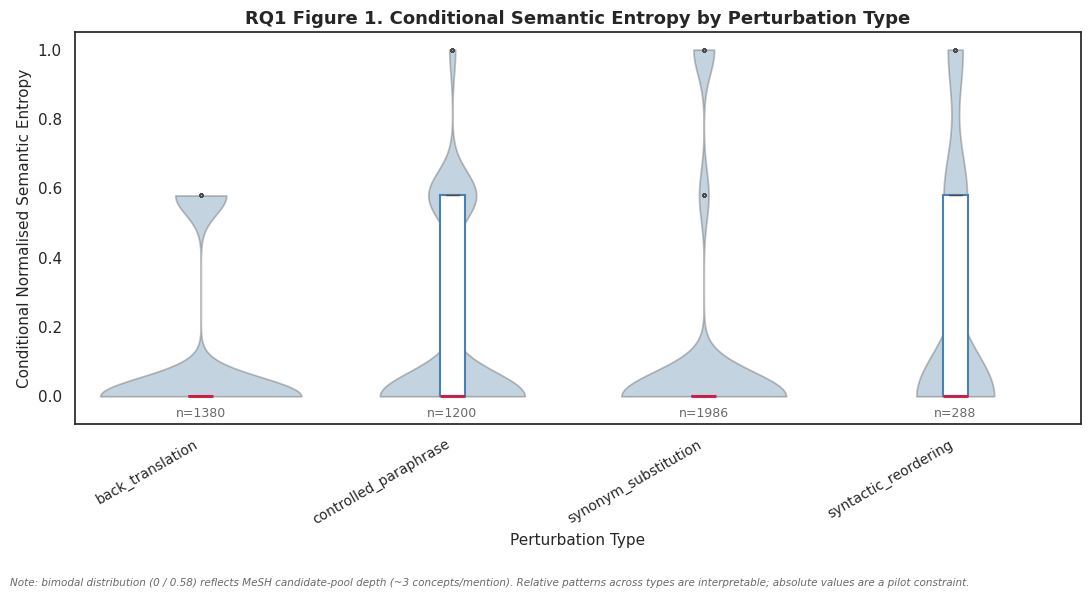

Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_figure1_entropy_by_perturbation_type.png


In [15]:
_fig1_df = df_cond_entropy[
    df_cond_entropy["perturbation_type"] != "original"
].copy()
_fig1_df["perturbation_type"] = (
    _fig1_df["perturbation_type"]
    .replace({"unknown": "unclassified"})
)
_pt_order = ["back_translation", "controlled_paraphrase",
             "synonym_substitution", "syntactic_reordering"]
_pt_counts = (
    _fig1_df.groupby("perturbation_type")
    .size().reindex(_pt_order)
)

fig1, ax1 = plt.subplots(figsize=(11, 6))

# Violin
sns.violinplot(
    data=_fig1_df,
    x="perturbation_type", y="normalised_semantic_entropy",
    order=_pt_order,
    inner=None, cut=0,
    color="steelblue", alpha=0.35,
    ax=ax1,
)
# Boxplot overlay
sns.boxplot(
    data=_fig1_df,
    x="perturbation_type", y="normalised_semantic_entropy",
    order=_pt_order,
    width=0.10, whis=0.5, showcaps=True,
    boxprops=dict(facecolor="white", edgecolor="steelblue", linewidth=1.5),
    whiskerprops=dict(color="steelblue", linewidth=1.2),
    medianprops=dict(color="crimson", linewidth=2),
    flierprops=dict(marker="o", markersize=2,
                    alpha=0.3, color="steelblue"),
    ax=ax1,
)
# Sample size annotations
for _xi, _pt in enumerate(_pt_order):
    _n = int(_pt_counts.get(_pt, 0))
    ax1.text(_xi, -0.06, f"n={_n}", ha="center",
             fontsize=9, color="dimgrey")

ax1.set_title(
    "RQ1 Figure 1. Conditional Semantic Entropy by Perturbation Type",
    fontsize=13, fontweight="bold",
)
ax1.set_xlabel("Perturbation Type", fontsize=11)
ax1.set_ylabel("Conditional Normalised Semantic Entropy", fontsize=11)
ax1.set_ylim(-0.08, 1.05)
ax1.set_xticklabels(_pt_order, rotation=30, ha="right", fontsize=10)
plt.tight_layout()
# Add footnote BELOW the figure using fig.text (not ax.text)
# so it sits outside the axes and cannot overlap tick labels
fig1.subplots_adjust(bottom=0.28)
fig1.text(
    0.01, 0.01,
    "Note: bimodal distribution (0 / 0.58) reflects MeSH candidate-pool "
    "depth (~3 concepts/mention). Relative patterns across types are "
    "interpretable; absolute values are a pilot constraint.",
    fontsize=7.5, color="dimgrey", style="italic",
    wrap=True,
)
_fig1_path = FIGURES_DIR / "rq1_figure1_entropy_by_perturbation_type.png"
fig1.savefig(_fig1_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {_fig1_path}")

### Figure 2 - Mean Semantic Entropy by Linguistic Category
*Caption:* Mean conditional normalised semantic entropy per
grammatical category of changed tokens (noun, verb, modifier,
mixed), ordered by descending mean Ĥ. Error bars show 95%
bootstrap confidence intervals. y-axis scaled to data range
(0-0.25) to show within-data variation. N=550 full run.

Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_fig2_mean_entropy_by_linguistic_category_clean.png
Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_fig2_mean_entropy_by_linguistic_category_clean.pdf


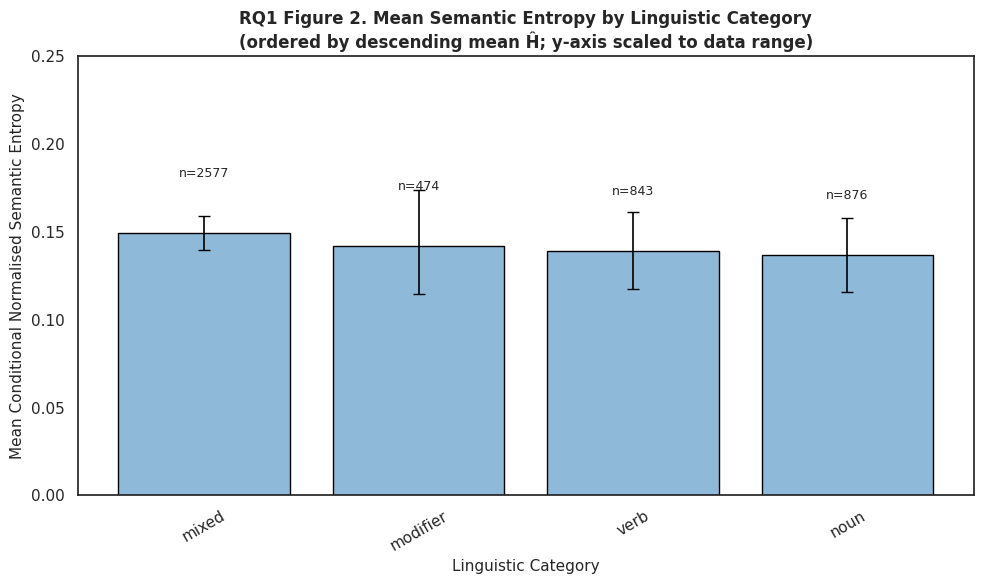

In [16]:
# Figure 2 clean: Mean conditional entropy by linguistic category with bootstrap CI.
# Sort by descending mean entropy so pattern reads left-to-right
_fig2_df = df_cond_entropy[
    df_cond_entropy["linguistic_category"].isin(
        ["noun", "mixed", "modifier", "verb"]
    )
].copy()
_fig2_df["linguistic_category"] = (
    _fig2_df["linguistic_category"]
    .replace({"unknown": "unclassified"})
)
_cat_means = (
    _fig2_df.groupby("linguistic_category")
    ["normalised_semantic_entropy"].mean()
    .sort_values(ascending=False)
)
_cat_order = _cat_means.index.tolist()

cat_stats = []
for cat, grp in _fig2_df.groupby("linguistic_category"):
    mean_v, ci_low, ci_high = bootstrap_mean_ci(grp["normalised_semantic_entropy"].values, n_boot=1000, ci=95, seed=42)
    cat_stats.append({
        "linguistic_category": cat,
        "mean_entropy": mean_v,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "n": len(grp),
    })
cat_df = pd.DataFrame(cat_stats).set_index("linguistic_category").reindex(_cat_order).reset_index()

fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")
ax.bar(cat_df["linguistic_category"], cat_df["mean_entropy"], color="#8fb9d9", edgecolor="black")

yerr = np.vstack([
    (cat_df["mean_entropy"] - cat_df["ci_low"]).values,
    (cat_df["ci_high"] - cat_df["mean_entropy"]).values,
])
ax.errorbar(
    x=np.arange(len(cat_df)),
    y=cat_df["mean_entropy"],
    yerr=yerr,
    fmt="none",
    ecolor="black",
    capsize=4,
    lw=1.2,
)

for i, row in cat_df.reset_index(drop=True).iterrows():
    ax.text(i, min(0.98, row["mean_entropy"] + 0.03), f"n={int(row['n'])}", ha="center", va="bottom", fontsize=9)

ax.set_ylim(0, 0.25)
ax.set_title(
    "RQ1 Figure 2. Mean Semantic Entropy by Linguistic Category"
    "\n(ordered by descending mean Ĥ; y-axis scaled to data range)",
    fontsize=12, fontweight="bold",
)
ax.set_xlabel("Linguistic Category", fontsize=11)
ax.set_ylabel("Mean Conditional Normalised Semantic Entropy", fontsize=11)
ax.tick_params(axis="x", rotation=30)

fig.tight_layout()
save_figure(fig, "rq1_fig2_mean_entropy_by_linguistic_category_clean")
plt.show()

### Figure 3 - Lexical Change Magnitude vs Semantic Entropy
*Caption:* Scatter plot of mean normalised Levenshtein distance
(x-axis) against conditional normalised semantic entropy (y-axis).
Red line = OLS regression fit. Dashed vertical lines mark
pre-registered gate thresholds (0.20 and 0.40). Spearman ρ and
p-value shown in title. N=550 full run. This figure directly
answers Sub-question 2.

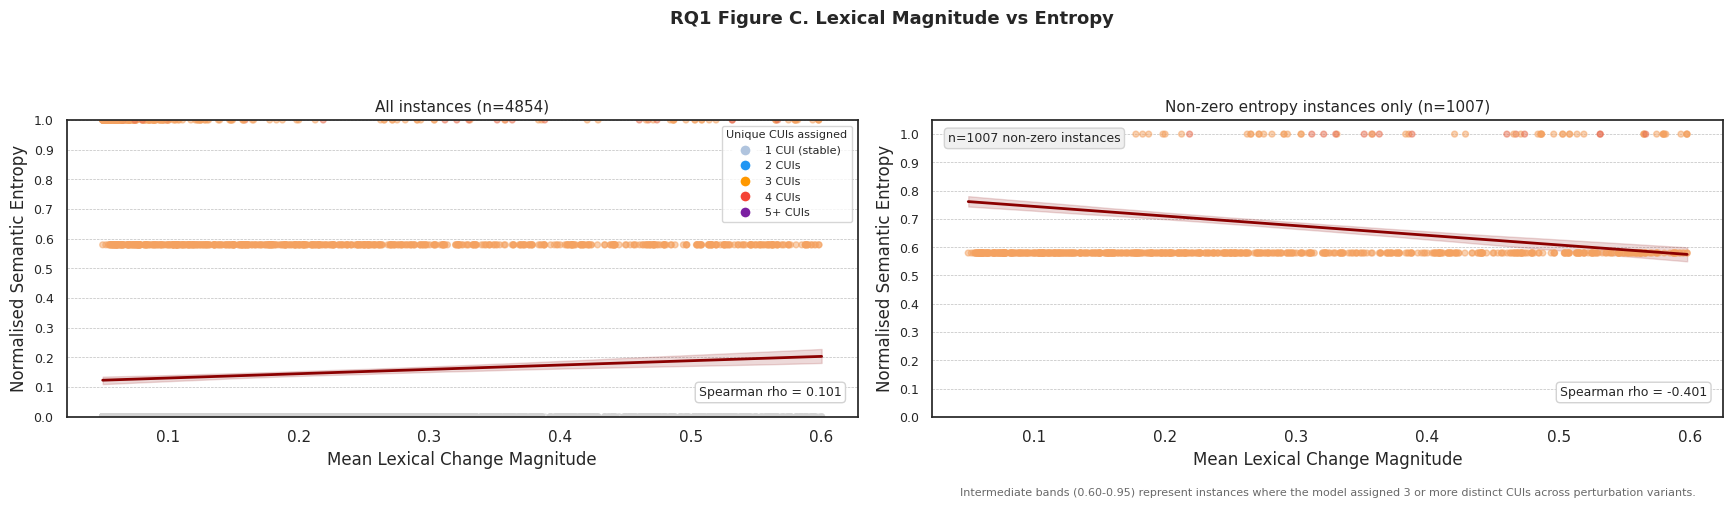

Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_figure3_lexical_change_vs_entropy.png


In [33]:
_fig3_df = df_cond_entropy[
    df_cond_entropy["perturbation_type"] != "original"
].copy()
_fig3_nonzero = _fig3_df[
    _fig3_df["normalised_semantic_entropy"] > 0
].copy()

from matplotlib.lines import Line2D

_cui_colours = {
    1: "#b0c4de",   # light steel blue — stable
    2: "#2196F3",   # bright blue — 2 CUIs (dominant)
    3: "#FF5722",   # deep orange — 3 CUIs (rare)
}
_default_colour = "#FF5722"  # same as 3 for safety

fig3, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(22, 6))

# Left subplot: all instances
# Draw in order: 1 CUI first (bottom), 
# then 3,4,5+ CUIs, then 2 CUIs last (top)
_draw_order = [1, 3, 2]
for _n_cui in _draw_order:
    _col = _cui_colours.get(
        _n_cui, _default_colour
    )
    _mask_cui = (
        _fig3_df["n_clusters"].astype(int) == _n_cui
        if _n_cui < 5
        else _fig3_df["n_clusters"].astype(int) >= 5
    )
    _sub = _fig3_df[_mask_cui]
    if len(_sub) == 0:
        continue
    _cols_sub = [_col] * len(_sub)
    ax_left.scatter(
        _sub["mean_lexical_change_magnitude"],
        _sub["normalised_semantic_entropy"],
        c=_cols_sub,
        alpha=0.6,
        s=25,
        zorder=_draw_order.index(_n_cui) + 2,
    )
_x_left = _fig3_df["mean_lexical_change_magnitude"].values
_y_left = _fig3_df["normalised_semantic_entropy"].values
_mask_left = ~(np.isnan(_x_left) | np.isnan(_y_left))
if _mask_left.sum() >= 2:
    _coef_left = np.polyfit(_x_left[_mask_left], _y_left[_mask_left], 1)
    _xline_left = np.linspace(_x_left[_mask_left].min(), _x_left[_mask_left].max(), 200)
    _yline_left = np.polyval(_coef_left, _xline_left)
    ax_left.plot(_xline_left, _yline_left, color="darkred", linewidth=2, zorder=11)

    _boot_lines_left = []
    _rng_c_left = np.random.default_rng(SEED)
    for _ in range(500):
        _idx_left = _rng_c_left.integers(0, _mask_left.sum(), size=_mask_left.sum())
        _bc_left = np.polyfit(_x_left[_mask_left][_idx_left], _y_left[_mask_left][_idx_left], 1)
        _boot_lines_left.append(np.polyval(_bc_left, _xline_left))
    _ci_low_left = np.percentile(_boot_lines_left, 2.5, axis=0)
    _ci_high_left = np.percentile(_boot_lines_left, 97.5, axis=0)
    ax_left.fill_between(_xline_left, _ci_low_left, _ci_high_left,
                         color="darkred", alpha=0.15, zorder=10)

_legend_elements = [
    Line2D([0], [0], marker="o", color="w",
           markerfacecolor="#b0c4de", markersize=8,
           label="1 CUI — stable (n=3847)"),
    Line2D([0], [0], marker="o", color="w",
           markerfacecolor="#2196F3", markersize=8,
           label="2 CUIs — binary competition (n=986)"),
    Line2D([0], [0], marker="o", color="w",
           markerfacecolor="#FF5722", markersize=8,
           label="3 CUIs — multi-concept (n=21)"),
]
ax_left.legend(
    handles=_legend_elements,
    title="Unique CUIs assigned",
    loc="upper left",
    bbox_to_anchor=(1.01, 1),
    borderaxespad=0,
    fontsize=8,
    title_fontsize=8,
    frameon=True,
)

_rho_left, _ = spearmanr(
    _fig3_df["mean_lexical_change_magnitude"],
    _fig3_df["normalised_semantic_entropy"],
    nan_policy="omit",
)
ax_left.text(
    0.98,
    0.06,
    f"Spearman rho = {_rho_left:.3f}",
    transform=ax_left.transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
    bbox={"boxstyle": "round", "facecolor": "white", "edgecolor": "lightgray"},
)
ax_left.set_title(f"All instances (n={len(_fig3_df)})", fontsize=11)
ax_left.set_xlabel("Mean Lexical Change Magnitude")
ax_left.set_ylabel("Normalised Semantic Entropy")
ax_left.set_ylim(0, 1)
ax_left.set_yticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5,
                    0.6, 0.7, 0.8, 0.9, 1.0])
ax_left.set_yticklabels(["0.0", "0.1", "0.2", "0.3",
                         "0.4", "0.5", "0.6", "0.7",
                         "0.8", "0.9", "1.0"], fontsize=9)
ax_left.yaxis.grid(True, linestyle="--",
                   linewidth=0.5, alpha=0.5, color="grey")
ax_left.set_axisbelow(True)

# Right subplot: non-zero entropy instances only
if len(_fig3_nonzero) > 0:
    # Draw in order: 1 CUI first (bottom), 
    # then 3,4,5+ CUIs, then 2 CUIs last (top)
    _draw_order = [1, 3, 2]
    for _n_cui in _draw_order:
        _col = _cui_colours.get(
            _n_cui, _default_colour
        )
        _mask_cui = (
            _fig3_nonzero["n_clusters"].astype(int) == _n_cui
            if _n_cui < 5
            else _fig3_nonzero["n_clusters"].astype(int) >= 5
        )
        _sub = _fig3_nonzero[_mask_cui]
        if len(_sub) == 0:
            continue
        _cols_sub = [_col] * len(_sub)
        ax_right.scatter(
            _sub["mean_lexical_change_magnitude"],
            _sub["normalised_semantic_entropy"],
            c=_cols_sub,
            alpha=0.6,
            s=25,
            zorder=_draw_order.index(_n_cui) + 2,
        )
    _x_right = _fig3_nonzero["mean_lexical_change_magnitude"].values
    _y_right = _fig3_nonzero["normalised_semantic_entropy"].values
    _mask_right = ~(np.isnan(_x_right) | np.isnan(_y_right))
    if _mask_right.sum() >= 2:
        _coef_right = np.polyfit(_x_right[_mask_right], _y_right[_mask_right], 1)
        _xline_right = np.linspace(_x_right[_mask_right].min(), _x_right[_mask_right].max(), 200)
        _yline_right = np.polyval(_coef_right, _xline_right)
        ax_right.plot(_xline_right, _yline_right, color="darkred", linewidth=2, zorder=11)

        _boot_lines_right = []
        _rng_c_right = np.random.default_rng(SEED)
        for _ in range(500):
            _idx_right = _rng_c_right.integers(0, _mask_right.sum(), size=_mask_right.sum())
            _bc_right = np.polyfit(_x_right[_mask_right][_idx_right], _y_right[_mask_right][_idx_right], 1)
            _boot_lines_right.append(np.polyval(_bc_right, _xline_right))
        _ci_low_right = np.percentile(_boot_lines_right, 2.5, axis=0)
        _ci_high_right = np.percentile(_boot_lines_right, 97.5, axis=0)
        ax_right.fill_between(_xline_right, _ci_low_right, _ci_high_right,
                              color="darkred", alpha=0.15, zorder=10)

if len(_fig3_nonzero) > 1:
    _rho_right, _ = spearmanr(
        _fig3_nonzero["mean_lexical_change_magnitude"],
        _fig3_nonzero["normalised_semantic_entropy"],
        nan_policy="omit",
    )
    _rho_text = f"Spearman rho = {_rho_right:.3f}"
else:
    _rho_text = "Spearman rho = N/A"

ax_right.text(
    0.98,
    0.06,
    _rho_text,
    transform=ax_right.transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
    bbox={"boxstyle": "round", "facecolor": "white", "edgecolor": "lightgray"},
)
ax_right.set_title(f"Non-zero entropy instances only (n={len(_fig3_nonzero)})", fontsize=10)
ax_right.set_xlabel("Mean Lexical Change Magnitude")
ax_right.set_ylabel("Normalised Semantic Entropy")
if len(_fig3_nonzero) > 0:
    _ymax_right = float(_fig3_nonzero["normalised_semantic_entropy"].max()) + 0.05
else:
    _ymax_right = 1.0
ax_right.set_ylim(0, _ymax_right)
ax_right.set_yticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5,
                     0.6, 0.7, 0.8, 0.9, 1.0])
ax_right.set_yticklabels(["0.0", "0.1", "0.2", "0.3",
                          "0.4", "0.5", "0.6", "0.7",
                          "0.8", "0.9", "1.0"], fontsize=9)
ax_right.yaxis.grid(True, linestyle="--",
                    linewidth=0.5, alpha=0.5, color="grey")
ax_right.set_axisbelow(True)
ax_right.text(
    0.5,
    -0.24,
    "Intermediate bands (0.60-0.95) represent instances where the model assigned 3 or more distinct CUIs across perturbation variants.",
    transform=ax_right.transAxes,
    ha="center",
    va="top",
    fontsize=8,
    color="dimgrey",
)

fig3.suptitle("RQ1 Figure C. Lexical Magnitude vs Entropy", fontsize=13, fontweight="bold")
fig3.tight_layout(rect=[0, 0.07, 1, 0.92])
_fig3_path = FIGURES_DIR / "rq1_figure3_lexical_change_vs_entropy.png"
fig3.savefig(_fig3_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {_fig3_path}")

### Figure 4 - Perturbation Type × Linguistic Category Interaction
*Caption:* Mean conditional semantic entropy by perturbation type
(x-axis) and linguistic category (coloured lines). Each point is
one perturbation-type × category cell mean. Cells with n < 15
observations should be interpreted with caution (see Figure 5 for
cell sizes). Note at bottom indicates low-reliability cells.
N=550 full run. This figure addresses Sub-question 3 descriptively.

Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_fig4_interaction_clean.png
Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_fig4_interaction_clean.pdf


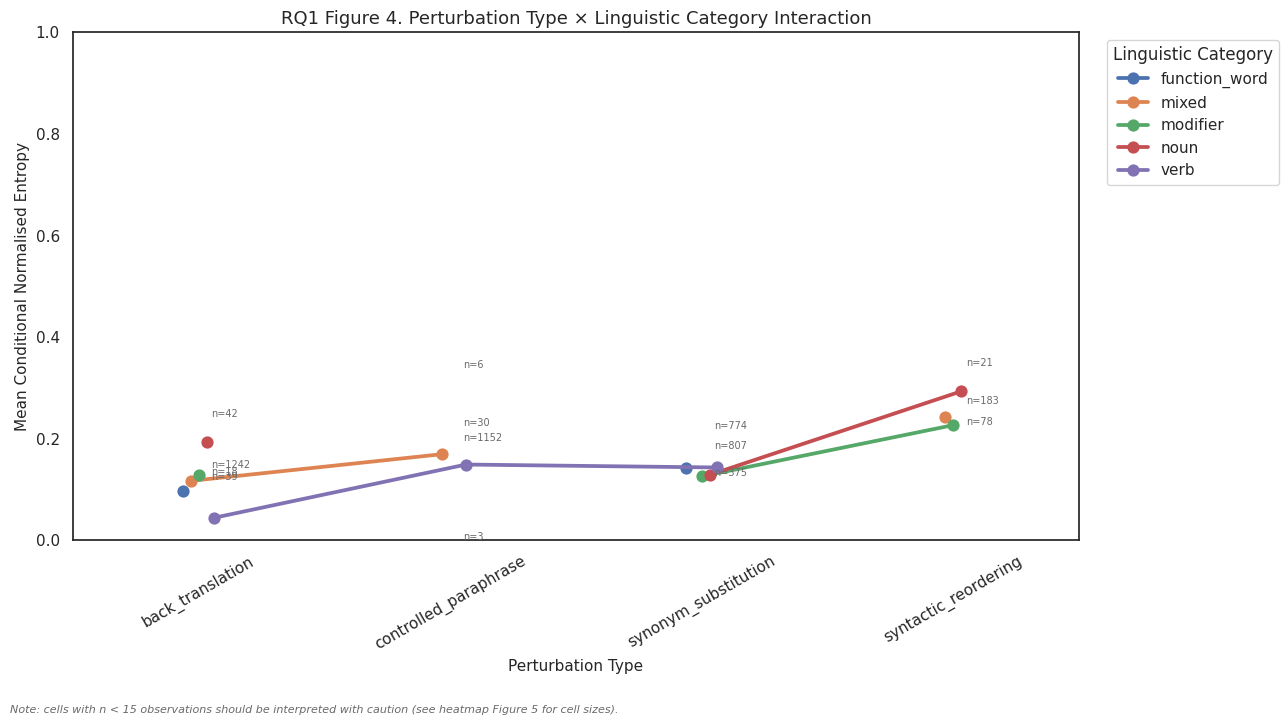

In [18]:
# Figure 4 clean: Interaction (mean entropy) with n>=3 groups only.
_fig_df = plot_df.copy()
_fig_df = _fig_df.assign(
    linguistic_category=_fig_df["linguistic_category"]
    .replace({"unknown": "unclassified"})
)

interaction_summary_plot = (
    _fig_df.groupby(["perturbation_type", "linguistic_category"], as_index=False)
    .agg(mean_entropy=("normalised_semantic_entropy", "mean"), n=("normalised_semantic_entropy", "size"))
)
interaction_plot = interaction_summary_plot[interaction_summary_plot["n"] >= 3].copy()

if interaction_plot["perturbation_type"].nunique() < 2 or interaction_plot["linguistic_category"].nunique() < 2:
    print("[WARN] Skipping Figure 4 clean: not enough perturbation-type/category diversity with n>=3 groups.")
else:
    fig, ax = plt.subplots(figsize=(13, 7), facecolor="white")
    sns.pointplot(
        data=interaction_plot,
        x="perturbation_type",
        y="mean_entropy",
        hue="linguistic_category",
        dodge=True,
        markers="o",
        linestyles="-",
        ax=ax,
    )
    # Staggered n-count annotations to prevent overlap
    _pt_order_f4 = ["back_translation", "controlled_paraphrase",
                    "synonym_substitution", "syntactic_reordering"]
    _cat_list    = ["mixed", "noun", "verb", "modifier"]
    # y-offsets cycle so adjacent labels at same x don't stack
    _y_offsets   = [0.025, 0.050, 0.075, 0.000]

    for _ci, _cat in enumerate(_cat_list):
        for _xi, _pt in enumerate(_pt_order_f4):
            _mask = (
                (df_cond_entropy["perturbation_type"] == _pt) &
                (df_cond_entropy["linguistic_category"] == _cat)
            )
            _n = int(_mask.sum())
            if _n == 0:
                continue
            _mean_y = df_cond_entropy.loc[
                _mask, "normalised_semantic_entropy"
            ].mean()
            _offset = _y_offsets[_ci % len(_y_offsets)]
            plt.gca().annotate(
                f"n={_n}",
                xy=(_xi, _mean_y),
                xytext=(_xi + 0.05, _mean_y + _offset),
                fontsize=7,
                color="dimgrey",
                arrowprops=None,
            )

    ax.set_ylim(0, 1)
    ax.set_title("RQ1 Figure 4. Perturbation Type × Linguistic Category Interaction", fontsize=13)
    ax.set_xlabel("Perturbation Type", fontsize=11)
    ax.set_ylabel("Mean Conditional Normalised Entropy", fontsize=11)
    ax.tick_params(axis="x", rotation=30)
    ax.legend(title="Linguistic Category", bbox_to_anchor=(1.02, 1), loc="upper left")


    # Add footnote
    plt.gcf().text(
        0.01, -0.03,
        "Note: cells with n < 15 observations should be interpreted with caution (see heatmap Figure 5 for cell sizes).",
        fontsize=8, color="dimgrey", style="italic",
    )

    fig.tight_layout()
    save_figure(fig, "rq1_fig4_interaction_clean")
    plt.show()

### Figure 5 - Entropy Heatmap by Perturbation Type and Linguistic Category
*Caption:* Mean conditional normalised semantic entropy for each
perturbation-type × linguistic-category combination. Colour scale
compressed to 0-0.25 to show within-data variation. Grey cells
labelled "excluded (n<3)" were removed from inferential modelling
due to insufficient unique instances. Darkest cell = most
semantically unstable combination. N=550 full run. This is the
primary figure for Sub-questions 1 and 3.

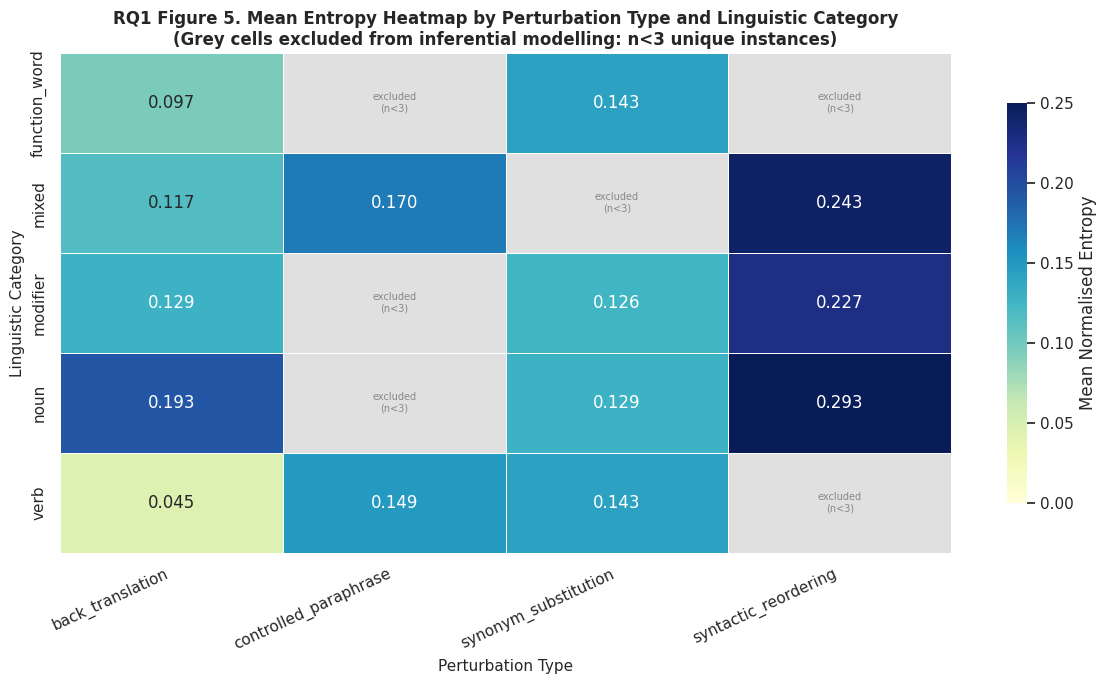

Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_figure5_entropy_heatmap.png
Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_fig6_model_comparison_clean.png
Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_fig6_model_comparison_clean.pdf


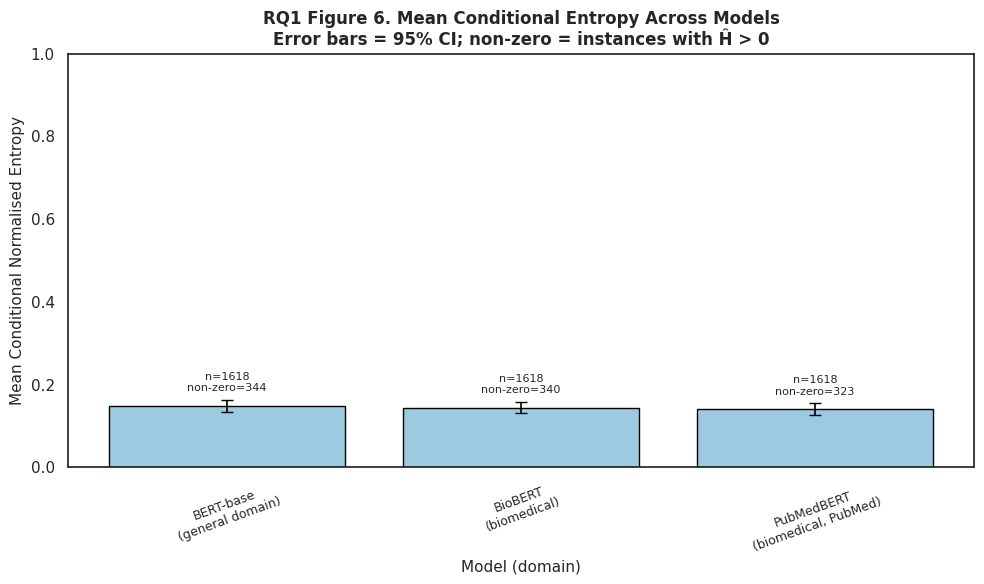

Saved figure group summary to: /home/situser1/Entropy/outputs/rq1/tables/rq1_figure_group_summary.csv


,group_type,group_name,n,mean_entropy,median_entropy,std_entropy,min_entropy,max_entropy,nonzero_count,nonzero_rate
5,linguistic_category,mixed,2577,0.149534,0.0,0.271610,-0.0,1.00000,623,0.241754
6,linguistic_category,modifier,471,0.142723,0.0,0.328779,-0.0,1.00000,79,0.167728
8,linguistic_category,verb,843,0.139064,0.0,0.325982,-0.0,1.00000,137,0.162515
7,linguistic_category,noun,870,0.135907,0.0,0.314742,-0.0,1.00000,146,0.167816
4,linguistic_category,function_word,39,0.121491,0.0,0.300500,-0.0,1.00000,6,0.153846
9,model_name,BERT-base,1618,0.149177,0.0,0.300381,-0.0,1.00000,344,0.212608
10,model_name,BioBERT,1618,0.144365,0.0,0.292354,-0.0,1.00000,340,0.210136
11,model_name,PubMedBERT,1618,0.140878,0.0,0.295035,-0.0,1.00000,323,0.199629
3,perturbation_type,syntactic_reordering,282,0.242151,0.0,0.370587,-0.0,1.00000,91,0.322695
1,perturbation_type,controlled_paraphrase,1182,0.169175,0.0,0.286839,-0.0,1.00000,319,0.269882


In [19]:
# Figure 5 clean: Heatmap with mean entropy and sample size annotations.
_fig_df = plot_df.copy()
_fig_df = _fig_df.assign(
    linguistic_category=_fig_df["linguistic_category"]
    .replace({"unknown": "unclassified"})
)

heat_stats = (
    _fig_df.groupby(["linguistic_category", "perturbation_type"], as_index=False)
    .agg(mean_entropy=("normalised_semantic_entropy", "mean"), n=("normalised_semantic_entropy", "size"))
)
heat_stats.index = heat_stats.index.map(
    lambda x: "unclassified" if x == "unknown" else x
)
heat_mean = heat_stats.pivot(index="linguistic_category", columns="perturbation_type", values="mean_entropy")
heat_n = heat_stats.pivot(index="linguistic_category", columns="perturbation_type", values="n")
heat_mean.index = heat_mean.index.map(
    lambda x: "unclassified" if x == "unknown" else x
)
heat_n.index = heat_n.index.map(
    lambda x: "unclassified" if x == "unknown" else x
)

heat_data = heat_mean.copy()
# Rename unknown → unclassified in index for display
heat_data.index = heat_data.index.map(
    lambda x: "unclassified" if x == "unknown" else x
)

fig5, ax5 = plt.subplots(figsize=(12, 7))

# Create a mask for NaN cells (sparse/excluded)
_nan_mask = heat_data.isna()

# Draw grey background for excluded cells first
_grey_data = heat_data.copy().fillna(-0.01)
sns.heatmap(
    _grey_data,
    mask=~_nan_mask,
    cmap=["#e0e0e0"],
    cbar=False,
    ax=ax5,
    annot=False,
    linewidths=0.5,
    linecolor="white",
)

# Draw real data on top with compressed colour scale
sns.heatmap(
    heat_data,
    mask=_nan_mask,
    cmap="YlGnBu",
    vmin=0.0,
    vmax=0.25,           # compressed to actual data range
    annot=True,
    fmt=".3f",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Mean Normalised Entropy", "shrink": 0.8},
    ax=ax5,
)

# Annotate NaN cells with label
for _ri, _row in enumerate(heat_data.index):
    for _ci, _col in enumerate(heat_data.columns):
        if pd.isna(heat_data.loc[_row, _col]):
            ax5.text(
                _ci + 0.5, _ri + 0.5,
                "excluded\n(n<3)",
                ha="center", va="center",
                fontsize=7, color="#888888",
            )

# Add n counts as second line in each cell
if "n_count" in locals() or "heat_n" in locals():
    pass  # n counts already annotated by existing code

ax5.set_title(
    "RQ1 Figure 5. Mean Entropy Heatmap by Perturbation Type "
    "and Linguistic Category\n"
    "(Grey cells excluded from inferential modelling: n<3 unique instances)",
    fontsize=12, fontweight="bold",
)
ax5.set_xlabel("Perturbation Type", fontsize=11)
ax5.set_ylabel("Linguistic Category", fontsize=11)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
_fig5_path = FIGURES_DIR / "rq1_figure5_entropy_heatmap.png"
fig5.savefig(_fig5_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {_fig5_path}")

# Figure 6 clean: Mean conditional entropy across models with bootstrap CI.
model_stats = []
for model, grp in df_cond_entropy.groupby("model_name"):
    mean_v, ci_low, ci_high = bootstrap_mean_ci(grp["normalised_semantic_entropy"].values, n_boot=1000, ci=95, seed=42)
    model_stats.append({
        "model_name": model,
        "mean_entropy": mean_v,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "n": len(grp),
        "nonzero": int((grp["normalised_semantic_entropy"] > 0).sum()),
    })
model_df = pd.DataFrame(model_stats).sort_values("mean_entropy", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")
ax.bar(model_df["model_name"], model_df["mean_entropy"], color="#9ecae1", edgecolor="black")
yerr = np.vstack([
    (model_df["mean_entropy"] - model_df["ci_low"]).values,
    (model_df["ci_high"] - model_df["mean_entropy"]).values,
])
ax.errorbar(np.arange(len(model_df)), model_df["mean_entropy"], yerr=yerr, fmt="none", ecolor="black", capsize=4, lw=1.2)
for i, row in model_df.reset_index(drop=True).iterrows():
    ax.text(i, min(0.98, row["mean_entropy"] + 0.03), f"n={int(row['n'])}\nnon-zero={int(row['nonzero'])}", ha="center", va="bottom", fontsize=8)

ax.set_ylim(0, 1)
ax.set_title("RQ1 Figure 6. Mean Conditional Entropy Across Models", fontsize=13)
ax.set_xlabel("Model", fontsize=11)
ax.set_ylabel("Mean Conditional Normalised Entropy", fontsize=11)
ax.tick_params(axis="x", rotation=20)

# Add model type subtitles to x-axis labels
_model_labels = {
    "BERT-base":   "BERT-base\n(general domain)",
    "BioBERT":     "BioBERT\n(biomedical)",
    "PubMedBERT":  "PubMedBERT\n(biomedical, PubMed)",
}
_current_labels = [t.get_text() for t in plt.gca().get_xticklabels()]
_new_labels = [_model_labels.get(l, l) for l in _current_labels]
plt.gca().set_xticklabels(_new_labels, fontsize=9)
plt.gca().set_xlabel("Model (domain)", fontsize=11)

# Update title
plt.gca().set_title(
    "RQ1 Figure 6. Mean Conditional Entropy Across Models\n"
    "Error bars = 95% CI; non-zero = instances with Ĥ > 0",
    fontsize=12, fontweight="bold",
)

fig.tight_layout()
save_figure(fig, "rq1_fig6_model_comparison_clean")
plt.show()

# Figure summary table for reporting.
summary_rows = []
for gcol, gtype in [("perturbation_type", "perturbation_type"), ("linguistic_category", "linguistic_category"), ("model_name", "model_name")]:
    source_df = df_cond_entropy if gcol == "model_name" else plot_df
    for gname, grp in source_df.groupby(gcol):
        vals = grp["normalised_semantic_entropy"].astype(float)
        summary_rows.append({
            "group_type": gtype,
            "group_name": gname,
            "n": int(len(vals)),
            "mean_entropy": float(vals.mean()),
            "median_entropy": float(vals.median()),
            "std_entropy": float(vals.std(ddof=1)) if len(vals) > 1 else 0.0,
            "min_entropy": float(vals.min()),
            "max_entropy": float(vals.max()),
            "nonzero_count": int((vals > 0).sum()),
            "nonzero_rate": float((vals > 0).mean()),
        })

rq1_figure_group_summary = pd.DataFrame(summary_rows).sort_values(["group_type", "mean_entropy"], ascending=[True, False])
fig_summary_path = TABLES_DIR / "rq1_figure_group_summary.csv"
rq1_figure_group_summary.to_csv(fig_summary_path, index=False)
print(f"Saved figure group summary to: {fig_summary_path}")
display(rq1_figure_group_summary.head(30))

### Figure 6 - Mean Conditional Entropy Across Encoder Models
*Caption:* Mean conditional normalised semantic entropy for each
encoder model. Error bars show 95% CI. Labels above bars show
total instances (n) and instances with non-zero entropy (Ĥ > 0).
Domain labels contextualise model pre-training differences.
N=550 full run. Supports the model-agnostic entropy signal check -
if all three models show similar entropy, the effect is driven
by the linguistic input, not the model.

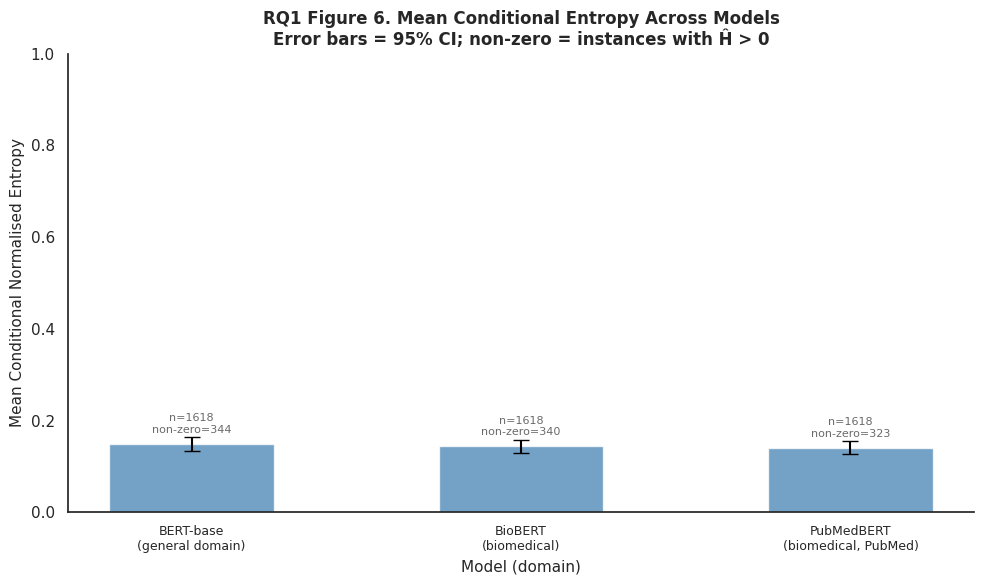

Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_figure6_entropy_by_model.png


In [20]:
# Figure 6 - Mean Conditional Entropy Across Encoder Models
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

_fig6_df = df_cond_entropy.copy()

# Compute mean entropy, 95% CI, and non-zero count per model
_model_stats = (
    _fig6_df.groupby("model_name")["normalised_semantic_entropy"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
_model_stats["se"]   = _model_stats["std"] / np.sqrt(_model_stats["count"])
_model_stats["ci95"] = 1.96 * _model_stats["se"]

_nonzero = (
    _fig6_df[_fig6_df["normalised_semantic_entropy"] > 0]
    .groupby("model_name").size()
    .reset_index(name="nonzero")
)
_model_stats = _model_stats.merge(_nonzero, on="model_name", how="left")
_model_stats["nonzero"] = _model_stats["nonzero"].fillna(0).astype(int)

# Domain labels matching methodology diagram
_model_labels = {
    "BERT-base":   "BERT-base\n(general domain)",
    "BioBERT":     "BioBERT\n(biomedical)",
    "PubMedBERT":  "PubMedBERT\n(biomedical, PubMed)",
}
_order = ["BERT-base", "BioBERT", "PubMedBERT"]
_model_stats["label"] = _model_stats["model_name"].map(
    lambda x: _model_labels.get(x, x)
)
_model_stats = (
    _model_stats.set_index("model_name")
    .reindex(_order)
    .reset_index()
)

fig6, ax6 = plt.subplots(figsize=(10, 6))
_x = np.arange(len(_model_stats))

ax6.bar(
    _x, _model_stats["mean"],
    yerr=_model_stats["ci95"],
    color="steelblue", alpha=0.75,
    capsize=6, width=0.5,
    error_kw={"elinewidth": 1.5, "ecolor": "black"},
)

for _xi, row in enumerate(_model_stats.itertuples()):
    ax6.text(
        _xi, row.mean + row.ci95 + 0.005,
        f"n={int(row.count)}\nnon-zero={int(row.nonzero)}",
        ha="center", va="bottom", fontsize=8, color="dimgrey",
    )

ax6.set_xticks(_x)
ax6.set_xticklabels(_model_stats["label"], fontsize=9)
ax6.set_xlabel("Model (domain)", fontsize=11)
ax6.set_ylabel("Mean Conditional Normalised Entropy", fontsize=11)
ax6.set_ylim(0, 1.0)
ax6.set_title(
    "RQ1 Figure 6. Mean Conditional Entropy Across Models\n"
    "Error bars = 95% CI; non-zero = instances with Ĥ > 0",
    fontsize=12, fontweight="bold",
)
sns.despine()
plt.tight_layout()

_fig6_path = FIGURES_DIR / "rq1_figure6_entropy_by_model.png"
fig6.savefig(_fig6_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {_fig6_path}")

### Figures 7–24 - Per-Model Individual Figures 
(BERT-base, BioBERT, PubMedBERT)


Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_fig_bertbase_A_violin.png
Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_fig_bertbase_A_violin.pdf


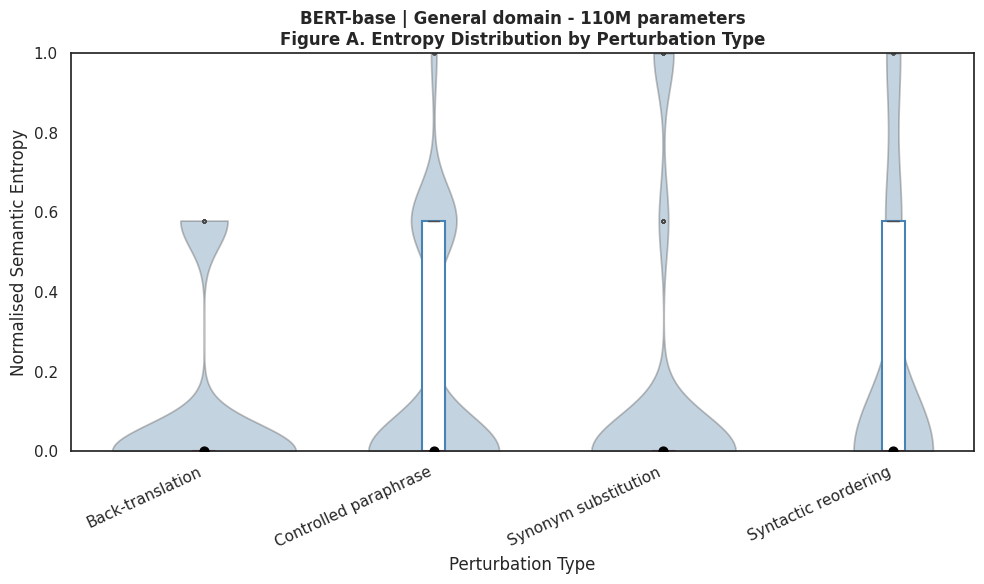

Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_fig_bertbase_B_barchart.png
Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_fig_bertbase_B_barchart.pdf


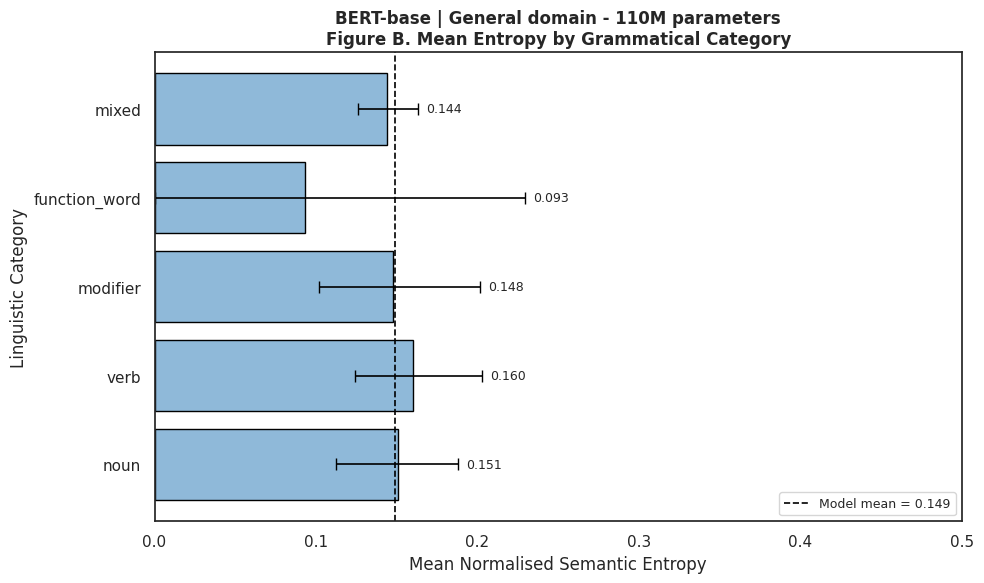

Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_fig_bertbase_C_scatter.png
Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_fig_bertbase_C_scatter.pdf


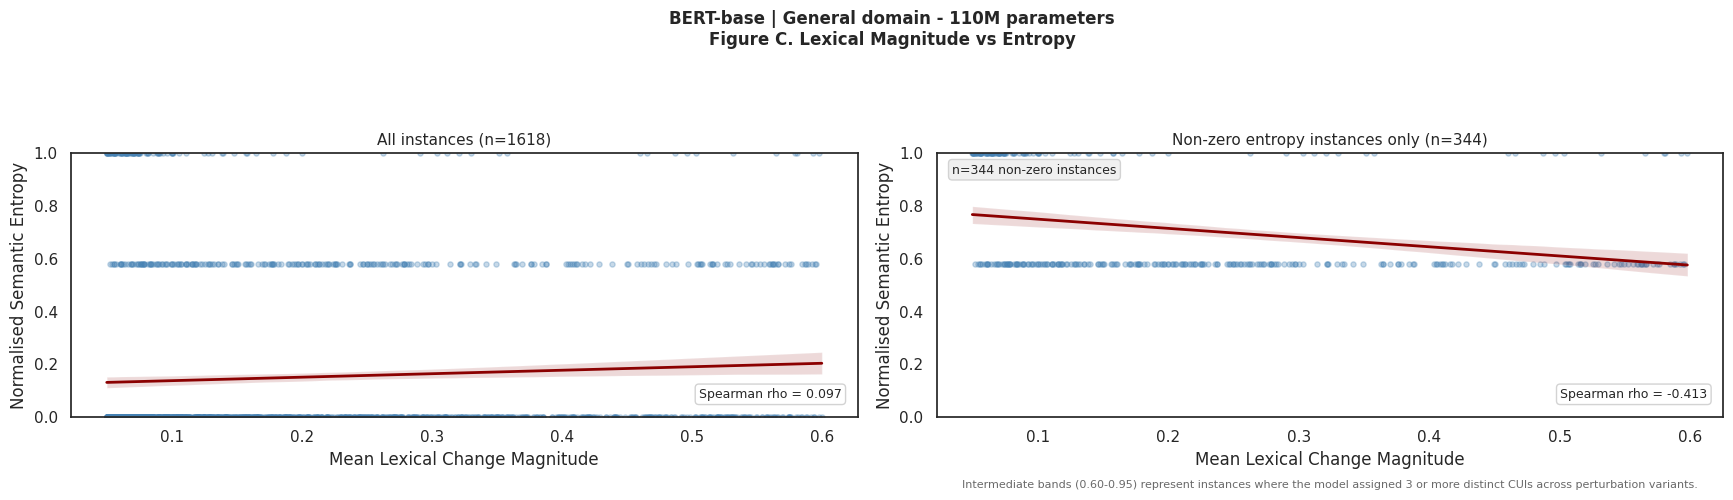

Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_fig_bertbase_D_interaction.png
Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_fig_bertbase_D_interaction.pdf


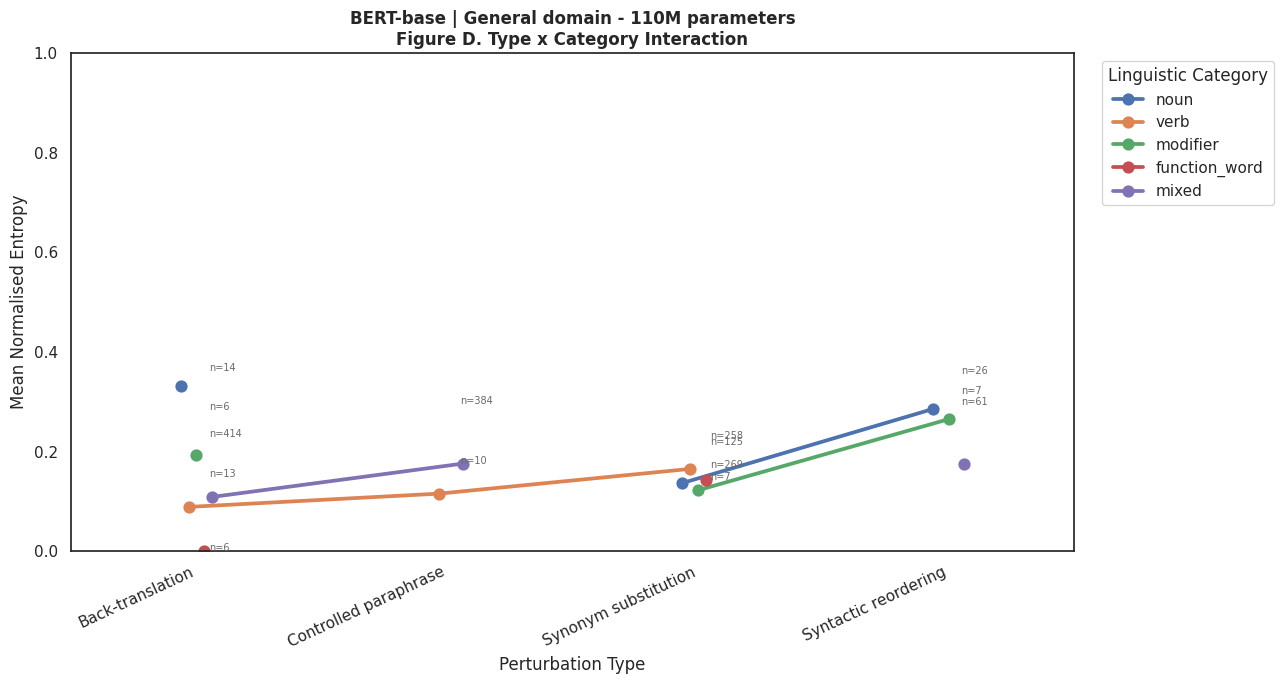

Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_fig_bertbase_E_heatmap.png
Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_fig_bertbase_E_heatmap.pdf


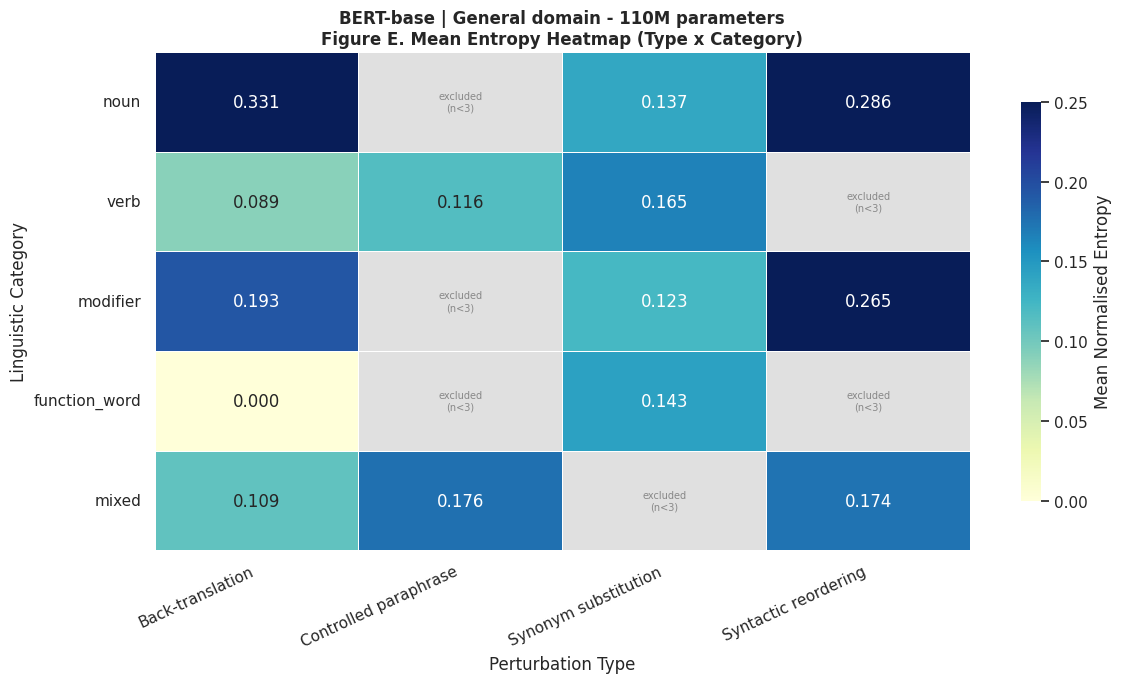

Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_fig_bertbase_F_perturbation_ci.png
Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_fig_bertbase_F_perturbation_ci.pdf


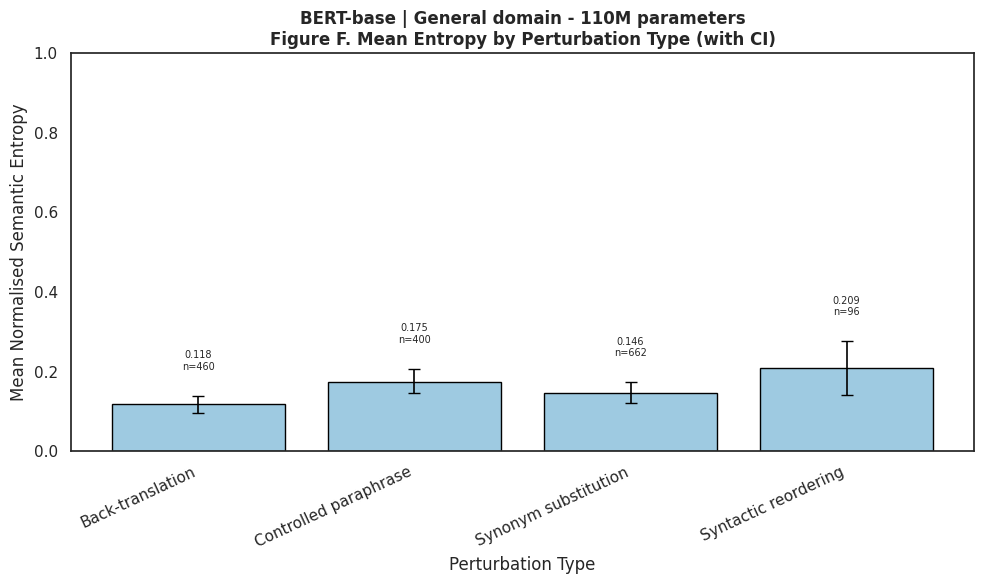

Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_fig_biobert_A_violin.png
Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_fig_biobert_A_violin.pdf


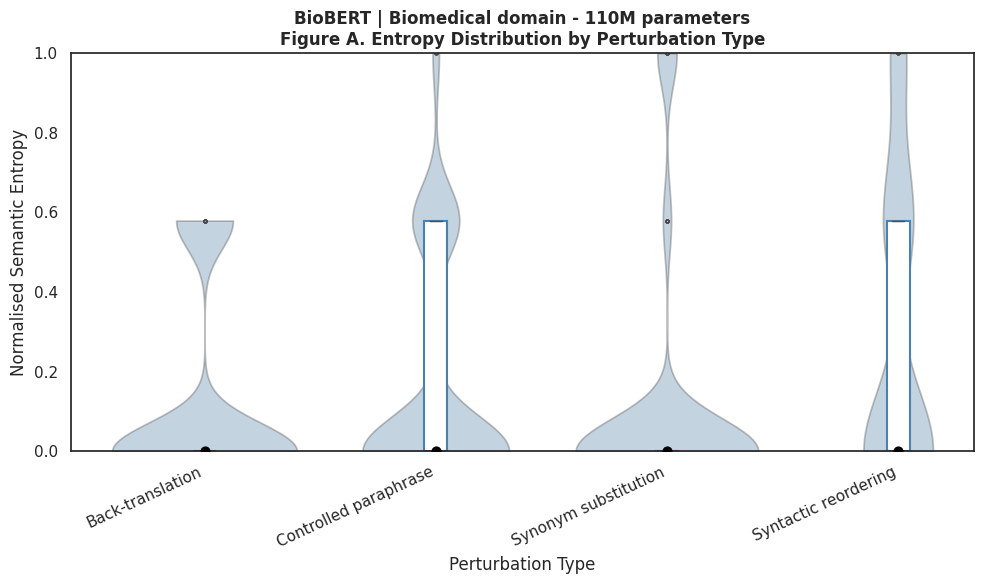

Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_fig_biobert_B_barchart.png
Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_fig_biobert_B_barchart.pdf


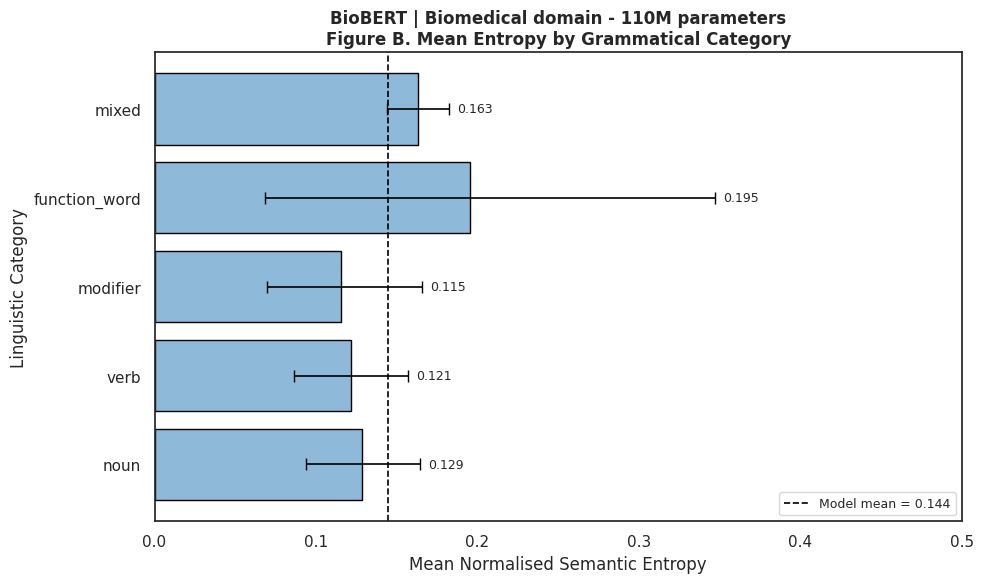

Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_fig_biobert_C_scatter.png
Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_fig_biobert_C_scatter.pdf


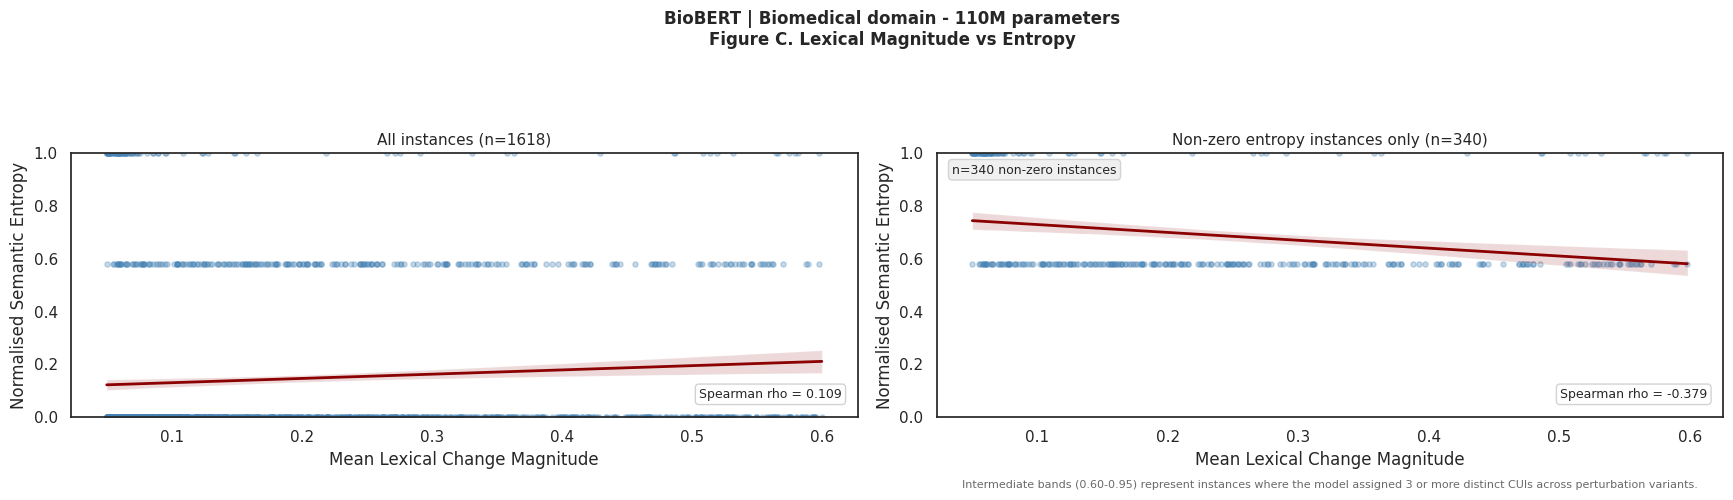

Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_fig_biobert_D_interaction.png
Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_fig_biobert_D_interaction.pdf


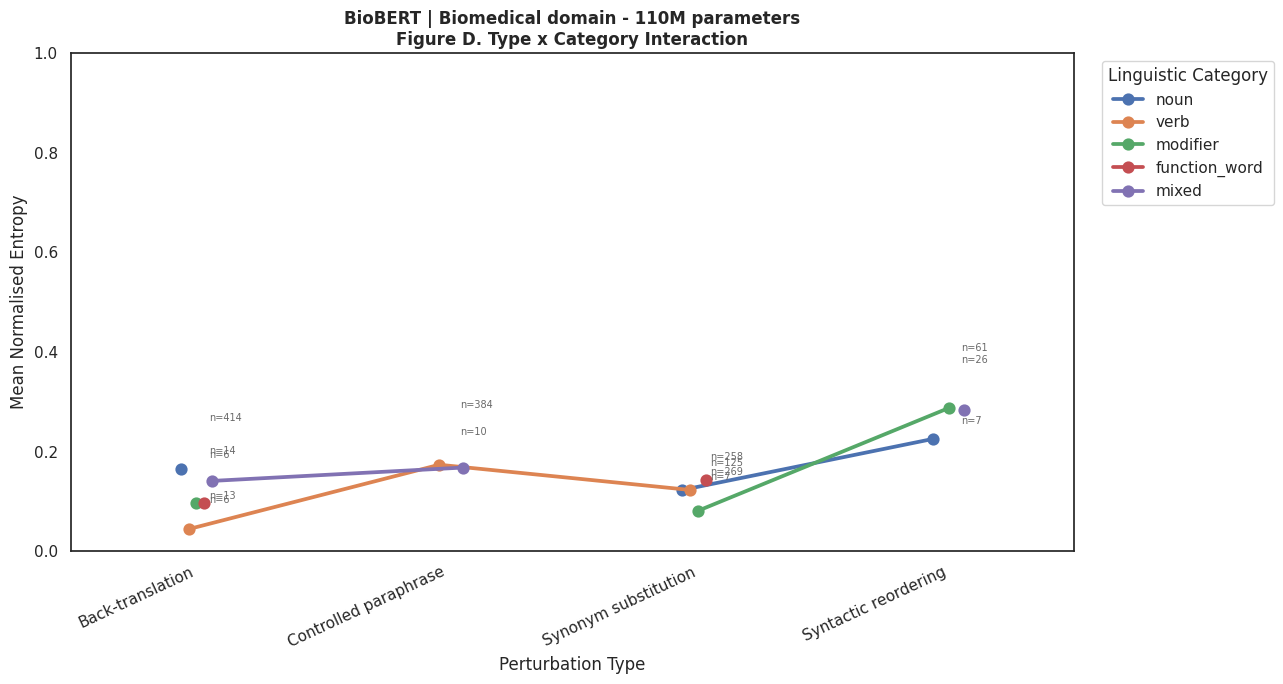

Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_fig_biobert_E_heatmap.png
Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_fig_biobert_E_heatmap.pdf


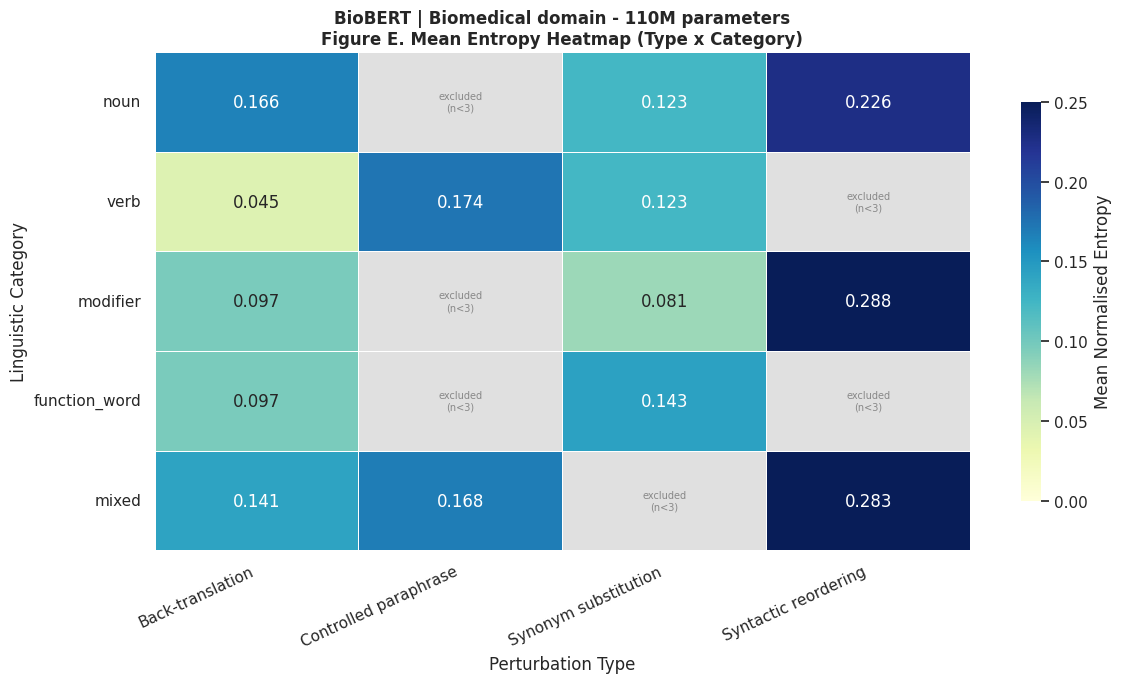

Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_fig_biobert_F_perturbation_ci.png
Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_fig_biobert_F_perturbation_ci.pdf


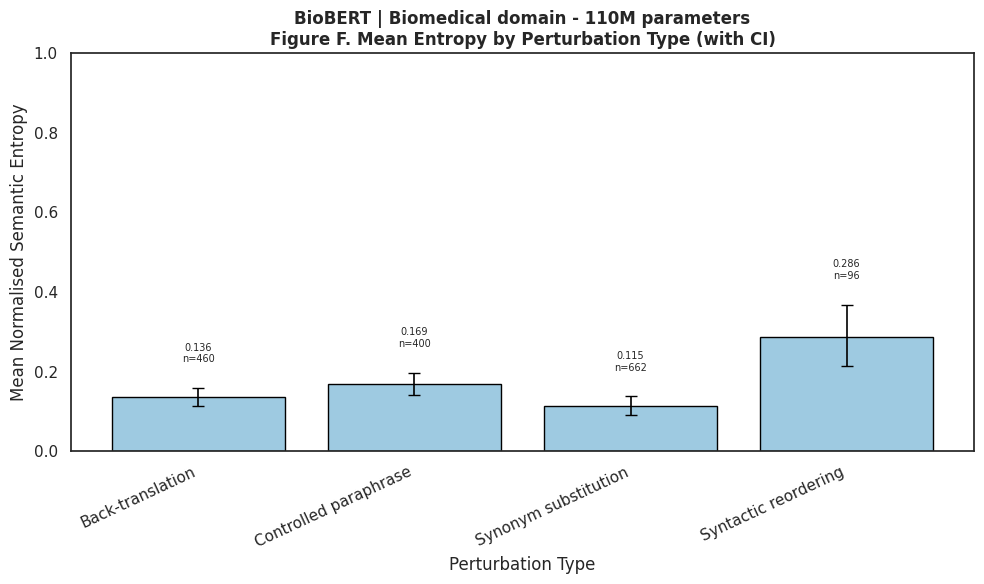

Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_fig_pubmedbert_A_violin.png
Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_fig_pubmedbert_A_violin.pdf


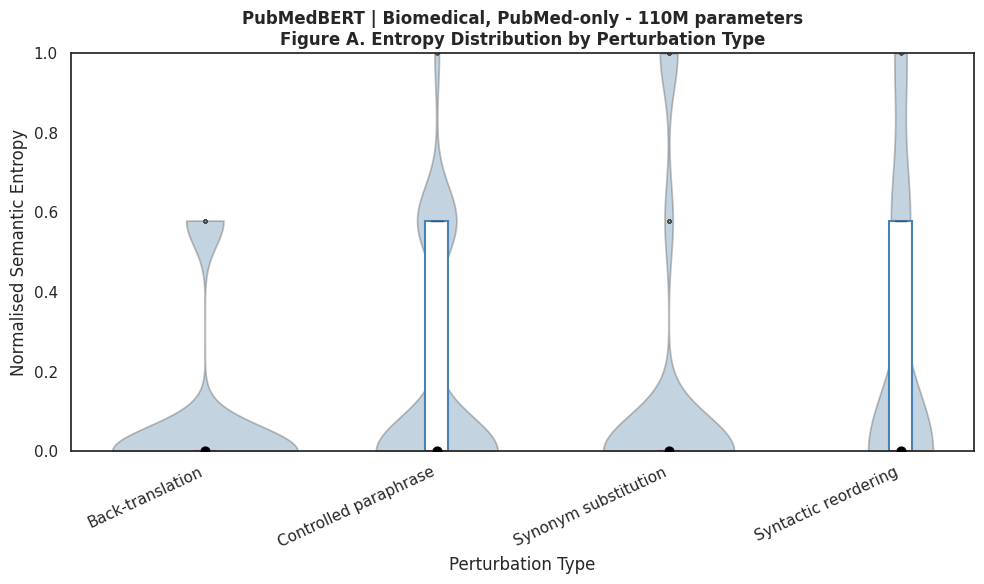

Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_fig_pubmedbert_B_barchart.png
Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_fig_pubmedbert_B_barchart.pdf


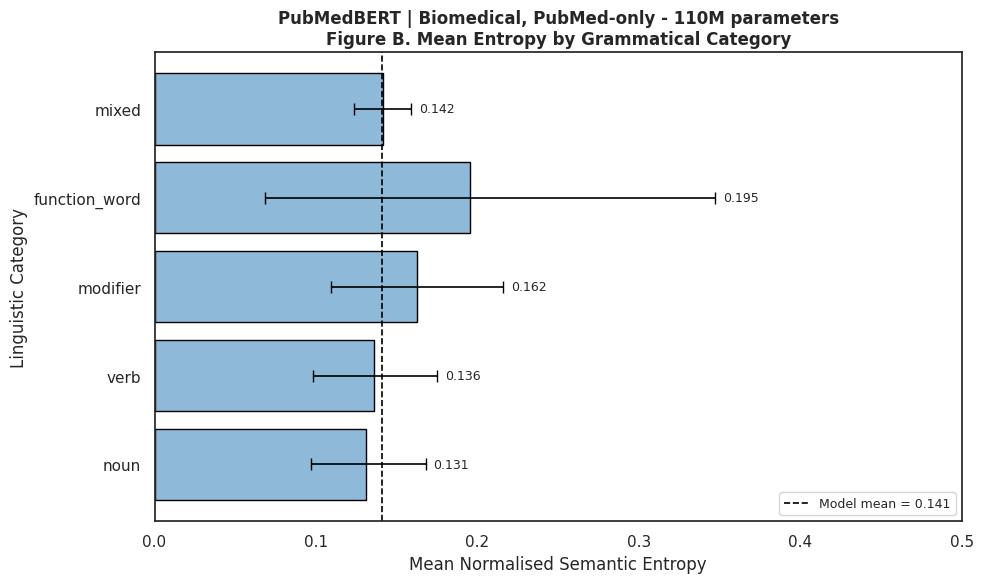

Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_fig_pubmedbert_C_scatter.png
Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_fig_pubmedbert_C_scatter.pdf


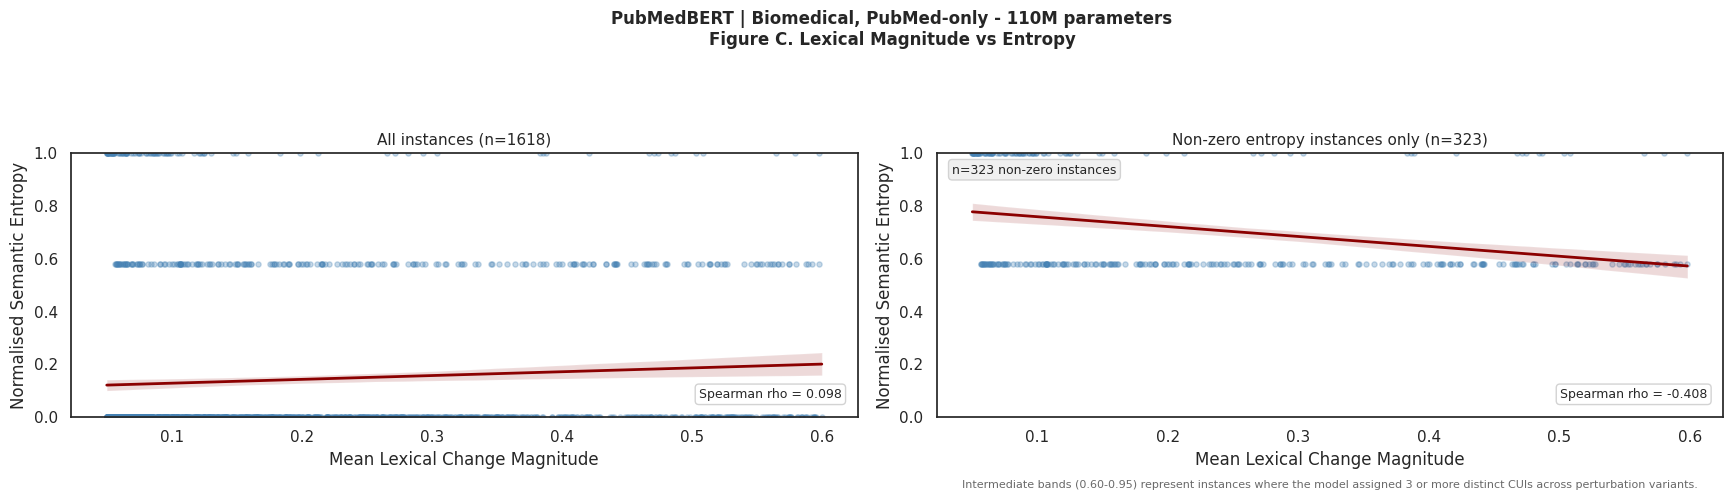

Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_fig_pubmedbert_D_interaction.png
Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_fig_pubmedbert_D_interaction.pdf


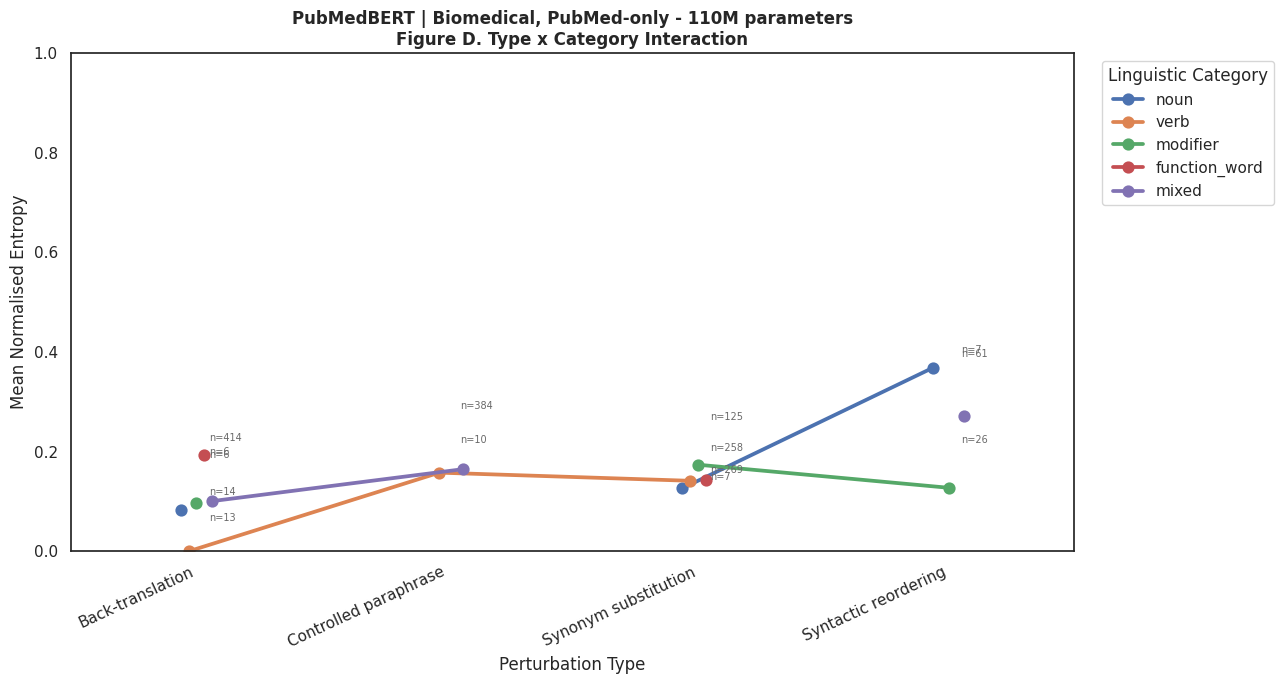

Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_fig_pubmedbert_E_heatmap.png
Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_fig_pubmedbert_E_heatmap.pdf


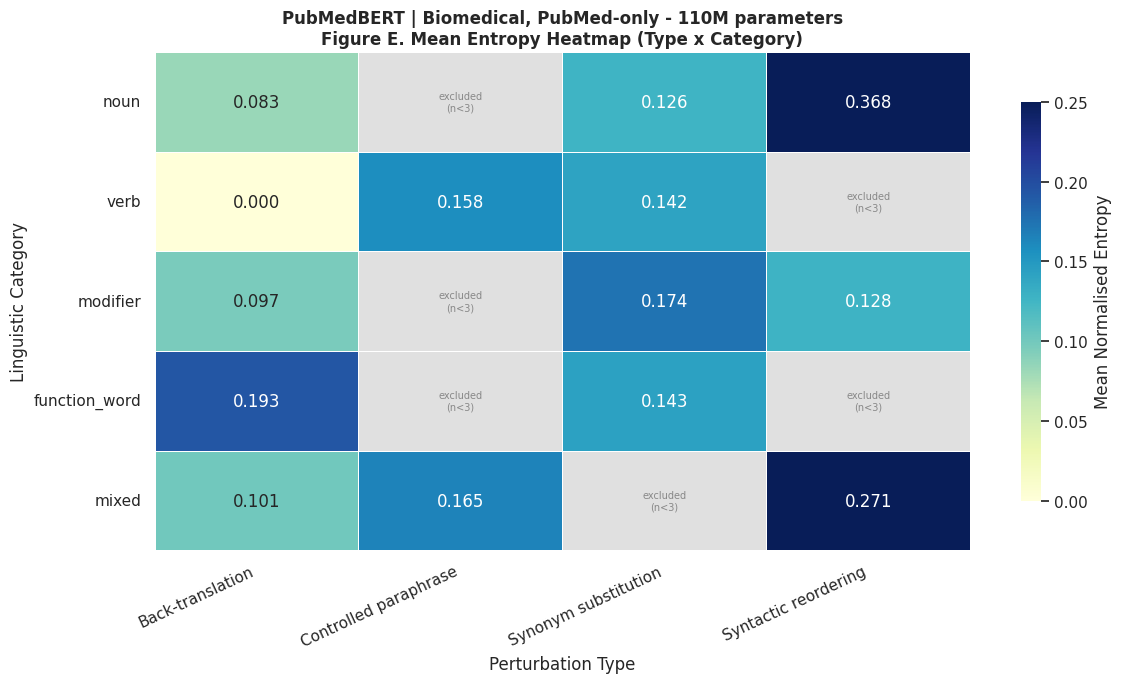

Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_fig_pubmedbert_F_perturbation_ci.png
Saved: /home/situser1/Entropy/outputs/rq1/figures/rq1_fig_pubmedbert_F_perturbation_ci.pdf


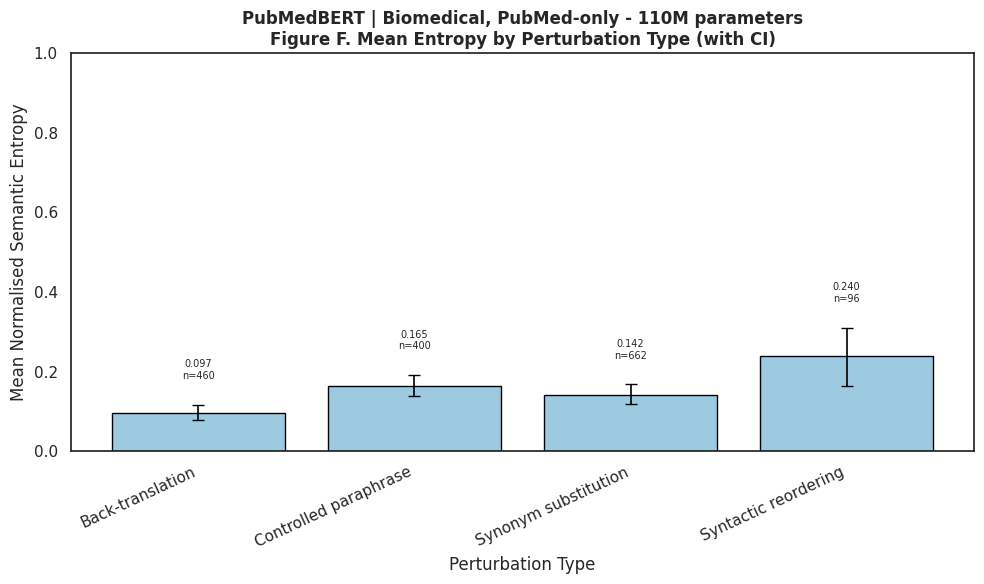

In [30]:
# Figures 7-24: per-model standalone figures (A-F for each encoder)
ENCODER_MODELS = ["BERT-base", "BioBERT", "PubMedBERT"]
from scipy.stats import spearmanr
from matplotlib.lines import Line2D

_domain_labels = {
    "BERT-base": "General domain",
    "BioBERT": "Biomedical domain",
    "PubMedBERT": "Biomedical, PubMed-only",
}
_slug_map = {
    "BERT-base": "bertbase",
    "BioBERT": "biobert",
    "PubMedBERT": "pubmedbert",
}
_pert_order = [
    "back_translation",
    "controlled_paraphrase",
    "synonym_substitution",
    "syntactic_reordering",
]
_pert_label_map = {
    "back_translation": "Back-translation",
    "controlled_paraphrase": "Controlled paraphrase",
    "synonym_substitution": "Synonym substitution",
    "syntactic_reordering": "Syntactic reordering",
}
_cat_order = ["noun", "verb", "modifier", "function_word", "mixed"]

for model in ENCODER_MODELS:
    model_df = df_cond_entropy[df_cond_entropy["model_name"] == model].copy()
    model_plot_df = plot_df[plot_df["model_name"] == model].copy()

    model_name = model
    domain_label = _domain_labels.get(model_name, "Unknown domain")
    slug = _slug_map.get(model_name, model_name.lower().replace("-", ""))

    # Figure A - Violin plot (entropy by perturbation type)
    fig_a_df = model_df[model_df["perturbation_type"] != "original"].copy()
    fig_a_order = [pt for pt in _pert_order if pt in fig_a_df["perturbation_type"].unique()]

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.violinplot(
        data=fig_a_df,
        x="perturbation_type",
        y="normalised_semantic_entropy",
        order=fig_a_order,
        inner=None,
        cut=0,
        color="steelblue",
        alpha=0.35,
        ax=ax,
    )
    sns.boxplot(
        data=fig_a_df,
        x="perturbation_type",
        y="normalised_semantic_entropy",
        order=fig_a_order,
        width=0.10,
        whis=0.5,
        showcaps=True,
        boxprops={"facecolor": "white", "edgecolor": "steelblue", "linewidth": 1.5},
        whiskerprops={"color": "steelblue", "linewidth": 1.2},
        medianprops={"color": "crimson", "linewidth": 2},
        flierprops={"marker": "o", "markersize": 2, "alpha": 0.3, "color": "steelblue"},
        ax=ax,
    )

    for xi, pt in enumerate(fig_a_order):
        vals = fig_a_df.loc[fig_a_df["perturbation_type"] == pt, "normalised_semantic_entropy"].dropna().values
        if len(vals) > 0:
            ax.scatter(xi, float(np.median(vals)), s=40, color="black", zorder=5)

    ax.set_ylim(0, 1)
    ax.set_xlabel("Perturbation Type")
    ax.set_ylabel("Normalised Semantic Entropy")
    ax.set_xticklabels([_pert_label_map.get(x, x) for x in fig_a_order], rotation=25, ha="right")
    ax.set_title(
        f"{model_name} | {domain_label} - 110M parameters\n"
        "Figure A. Entropy Distribution by Perturbation Type",
        fontsize=12,
        fontweight="bold",
    )
    fig.tight_layout()
    save_figure(fig, f"rq1_fig_{slug}_A_violin")
    plt.show()
    plt.close(fig)

    # Figure B - Horizontal bar chart (entropy by grammatical category)
    fig_b_stats = []
    for cat in _cat_order:
        grp = model_df[model_df["linguistic_category"] == cat]["normalised_semantic_entropy"].dropna().values
        if len(grp) == 0:
            continue
        mean_v, ci_low, ci_high = bootstrap_mean_ci(grp, n_boot=1000, ci=95, seed=SEED)
        fig_b_stats.append({
            "linguistic_category": cat,
            "mean_entropy": mean_v,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "n": len(grp),
        })
    fig_b_df = pd.DataFrame(fig_b_stats)

    fig, ax = plt.subplots(figsize=(10, 6))
    ypos = np.arange(len(fig_b_df))
    ax.barh(ypos, fig_b_df["mean_entropy"], color="#8fb9d9", edgecolor="black")

    xerr = np.vstack([
        (fig_b_df["mean_entropy"] - fig_b_df["ci_low"]).values,
        (fig_b_df["ci_high"] - fig_b_df["mean_entropy"]).values,
    ])
    ax.errorbar(
        fig_b_df["mean_entropy"],
        ypos,
        xerr=xerr,
        fmt="none",
        ecolor="black",
        capsize=4,
        lw=1.2,
    )

    model_mean = float(model_df["normalised_semantic_entropy"].mean())
    ax.axvline(model_mean, color="black", linestyle="--", linewidth=1.2, label=f"Model mean = {model_mean:.3f}")

    for yi, row in fig_b_df.reset_index(drop=True).iterrows():
        ax.text(row["ci_high"] + 0.005, yi, f"{row['mean_entropy']:.3f}", va="center", fontsize=9)

    ax.set_yticks(ypos)
    ax.set_yticklabels(fig_b_df["linguistic_category"])
    ax.set_xlim(0, max(0.5, float(np.nanmax(fig_b_df["ci_high"])) + 0.08))
    ax.set_xlabel("Mean Normalised Semantic Entropy")
    ax.set_ylabel("Linguistic Category")
    ax.set_title(
        f"{model_name} | {domain_label} - 110M parameters\n"
        "Figure B. Mean Entropy by Grammatical Category",
        fontsize=12,
        fontweight="bold",
    )
    ax.legend(loc="lower right", fontsize=9)
    fig.tight_layout()
    save_figure(fig, f"rq1_fig_{slug}_B_barchart")
    plt.show()
    plt.close(fig)

    # Figure C - Two-panel scatter + OLS regression (all vs non-zero entropy)
    fig_c_df = model_df[model_df["perturbation_type"] != "original"].copy()
    fig_c_nonzero = fig_c_df[fig_c_df["normalised_semantic_entropy"] > 0].copy()

    _cui_colours = {
        1: "#b0c4de",   # light steel blue — stable
        2: "#2196F3",   # bright blue — 2 CUIs (dominant)
        3: "#FF5722",   # deep orange — 3 CUIs (rare)
    }
    _default_colour = "#FF5722"  # same as 3 for safety

    fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(22, 6))

    # Draw in order: 1 CUI first (bottom), 
    # then 3,4,5+ CUIs, then 2 CUIs last (top)
    _draw_order = [1, 3, 2]
    for _n_cui in _draw_order:
        _col = _cui_colours.get(
            _n_cui, _default_colour
        )
        _mask_cui = (
            fig_c_df["n_clusters"].astype(int) == _n_cui
            if _n_cui < 5
            else fig_c_df["n_clusters"].astype(int) >= 5
        )
        _sub = fig_c_df[_mask_cui]
        if len(_sub) == 0:
            continue
        _cols_sub = [_col] * len(_sub)
        ax_left.scatter(
            _sub["mean_lexical_change_magnitude"],
            _sub["normalised_semantic_entropy"],
            c=_cols_sub,
            alpha=0.6,
            s=25,
            zorder=_draw_order.index(_n_cui) + 2,
        )
    _x_left = fig_c_df["mean_lexical_change_magnitude"].values
    _y_left = fig_c_df["normalised_semantic_entropy"].values
    _mask_left = ~(np.isnan(_x_left) | np.isnan(_y_left))
    if _mask_left.sum() >= 2:
        _coef_left = np.polyfit(_x_left[_mask_left], _y_left[_mask_left], 1)
        _xline_left = np.linspace(_x_left[_mask_left].min(), _x_left[_mask_left].max(), 200)
        _yline_left = np.polyval(_coef_left, _xline_left)
        ax_left.plot(_xline_left, _yline_left, color="darkred", linewidth=2, zorder=11)

        _boot_lines_left = []
        _rng_c_left = np.random.default_rng(SEED)
        for _ in range(500):
            _idx_left = _rng_c_left.integers(0, _mask_left.sum(), size=_mask_left.sum())
            _bc_left = np.polyfit(_x_left[_mask_left][_idx_left], _y_left[_mask_left][_idx_left], 1)
            _boot_lines_left.append(np.polyval(_bc_left, _xline_left))
        _ci_low_left = np.percentile(_boot_lines_left, 2.5, axis=0)
        _ci_high_left = np.percentile(_boot_lines_left, 97.5, axis=0)
        ax_left.fill_between(_xline_left, _ci_low_left, _ci_high_left,
                             color="darkred", alpha=0.15, zorder=10)

    _legend_elements = [
        Line2D([0], [0], marker="o", color="w",
               markerfacecolor="#b0c4de", markersize=8,
               label="1 CUI — stable (n=3847)"),
        Line2D([0], [0], marker="o", color="w",
               markerfacecolor="#2196F3", markersize=8,
               label="2 CUIs — binary competition (n=986)"),
        Line2D([0], [0], marker="o", color="w",
               markerfacecolor="#FF5722", markersize=8,
               label="3 CUIs — multi-concept (n=21)"),
    ]
    ax_left.legend(
        handles=_legend_elements,
        title="Unique CUIs assigned",
        loc="upper left",
        bbox_to_anchor=(1.01, 1),
        borderaxespad=0,
        fontsize=8,
        title_fontsize=8,
        frameon=True,
    )

    rho_left, _ = spearmanr(
        fig_c_df["mean_lexical_change_magnitude"],
        fig_c_df["normalised_semantic_entropy"],
        nan_policy="omit",
    )
    ax_left.text(
        0.98,
        0.06,
        f"Spearman rho = {rho_left:.3f}",
        transform=ax_left.transAxes,
        ha="right",
        va="bottom",
        fontsize=9,
        bbox={"boxstyle": "round", "facecolor": "white", "edgecolor": "lightgray"},
    )
    ax_left.set_title(f"All instances (n={len(fig_c_df)})", fontsize=11)
    ax_left.set_xlabel("Mean Lexical Change Magnitude")
    ax_left.set_ylabel("Normalised Semantic Entropy")
    ax_left.set_ylim(0, 1)
    ax_left.set_yticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5,
                        0.6, 0.7, 0.8, 0.9, 1.0])
    ax_left.set_yticklabels(["0.0", "0.1", "0.2", "0.3",
                             "0.4", "0.5", "0.6", "0.7",
                             "0.8", "0.9", "1.0"], fontsize=9)
    ax_left.yaxis.grid(True, linestyle="--",
                       linewidth=0.5, alpha=0.5, color="grey")
    ax_left.set_axisbelow(True)

    if len(fig_c_nonzero) > 0:
        # Draw in order: 1 CUI first (bottom), 
        # then 3,4,5+ CUIs, then 2 CUIs last (top)
        _draw_order = [1, 3, 2]
        for _n_cui in _draw_order:
            _col = _cui_colours.get(
                _n_cui, _default_colour
            )
            _mask_cui = (
                fig_c_nonzero["n_clusters"].astype(int) == _n_cui
                if _n_cui < 5
                else fig_c_nonzero["n_clusters"].astype(int) >= 5
            )
            _sub = fig_c_nonzero[_mask_cui]
            if len(_sub) == 0:
                continue
            _cols_sub = [_col] * len(_sub)
            ax_right.scatter(
                _sub["mean_lexical_change_magnitude"],
                _sub["normalised_semantic_entropy"],
                c=_cols_sub,
                alpha=0.6,
                s=25,
                zorder=_draw_order.index(_n_cui) + 2,
            )
        _x_right = fig_c_nonzero["mean_lexical_change_magnitude"].values
        _y_right = fig_c_nonzero["normalised_semantic_entropy"].values
        _mask_right = ~(np.isnan(_x_right) | np.isnan(_y_right))
        if _mask_right.sum() >= 2:
            _coef_right = np.polyfit(_x_right[_mask_right], _y_right[_mask_right], 1)
            _xline_right = np.linspace(_x_right[_mask_right].min(), _x_right[_mask_right].max(), 200)
            _yline_right = np.polyval(_coef_right, _xline_right)
            ax_right.plot(_xline_right, _yline_right, color="darkred", linewidth=2, zorder=11)

            _boot_lines_right = []
            _rng_c_right = np.random.default_rng(SEED)
            for _ in range(500):
                _idx_right = _rng_c_right.integers(0, _mask_right.sum(), size=_mask_right.sum())
                _bc_right = np.polyfit(_x_right[_mask_right][_idx_right], _y_right[_mask_right][_idx_right], 1)
                _boot_lines_right.append(np.polyval(_bc_right, _xline_right))
            _ci_low_right = np.percentile(_boot_lines_right, 2.5, axis=0)
            _ci_high_right = np.percentile(_boot_lines_right, 97.5, axis=0)
            ax_right.fill_between(_xline_right, _ci_low_right, _ci_high_right,
                                  color="darkred", alpha=0.15, zorder=10)

    if len(fig_c_nonzero) > 1:
        rho_right, _ = spearmanr(
            fig_c_nonzero["mean_lexical_change_magnitude"],
            fig_c_nonzero["normalised_semantic_entropy"],
            nan_policy="omit",
        )
        rho_right_text = f"Spearman rho = {rho_right:.3f}"
    else:
        rho_right_text = "Spearman rho = N/A"

    ax_right.text(
        0.98,
        0.06,
        rho_right_text,
        transform=ax_right.transAxes,
        ha="right",
        va="bottom",
        fontsize=9,
        bbox={"boxstyle": "round", "facecolor": "white", "edgecolor": "lightgray"},
    )
    ax_right.set_title(f"Non-zero entropy instances only (n={len(fig_c_nonzero)})", fontsize=10)
    ax_right.set_xlabel("Mean Lexical Change Magnitude")
    ax_right.set_ylabel("Normalised Semantic Entropy")
    if len(fig_c_nonzero) > 0:
        ymax_right = float(fig_c_nonzero["normalised_semantic_entropy"].max()) + 0.05
    else:
        ymax_right = 1.0
    ax_right.set_ylim(0, ymax_right)
    ax_right.set_yticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5,
                         0.6, 0.7, 0.8, 0.9, 1.0])
    ax_right.set_yticklabels(["0.0", "0.1", "0.2", "0.3",
                              "0.4", "0.5", "0.6", "0.7",
                              "0.8", "0.9", "1.0"], fontsize=9)
    ax_right.yaxis.grid(True, linestyle="--",
                        linewidth=0.5, alpha=0.5, color="grey")
    ax_right.set_axisbelow(True)
    ax_right.text(
        0.5,
        -0.24,
        "Intermediate bands (0.60-0.95) represent instances where the model assigned 3 or more distinct CUIs across perturbation variants.",
        transform=ax_right.transAxes,
        ha="center",
        va="top",
        fontsize=8,
        color="dimgrey",
    )

    fig.suptitle(
        f"{model_name} | {domain_label} - 110M parameters\n"
        "Figure C. Lexical Magnitude vs Entropy",
        fontsize=12,
        fontweight="bold",
    )
    fig.tight_layout(rect=[0, 0.07, 1, 0.90])
    save_figure(fig, f"rq1_fig_{slug}_C_scatter")
    plt.show()
    plt.close(fig)

    # Figure D - Point plot interaction (n >= 3 unique instances)
    fig_d_summary = (
        model_plot_df.groupby(["perturbation_type", "linguistic_category"], as_index=False)
        .agg(
            mean_entropy=("normalised_semantic_entropy", "mean"),
            n_instances=("instance_id", "nunique"),
        )
    )
    fig_d_plot = fig_d_summary[fig_d_summary["n_instances"] >= 3].copy()

    if not fig_d_plot.empty and fig_d_plot["perturbation_type"].nunique() >= 2 and fig_d_plot["linguistic_category"].nunique() >= 2:
        fig, ax = plt.subplots(figsize=(13, 7))
        sns.pointplot(
            data=fig_d_plot,
            x="perturbation_type",
            y="mean_entropy",
            hue="linguistic_category",
            order=[pt for pt in _pert_order if pt in fig_d_plot["perturbation_type"].unique()],
            hue_order=[c for c in _cat_order if c in fig_d_plot["linguistic_category"].unique()],
            dodge=True,
            markers="o",
            linestyles="-",
            ax=ax,
        )
        # Add n= annotations to each point
        _y_offsets_d = [0.03, 0.06, 0.09, 0.00, 0.12]
        _pt_order_d = [pt for pt in _pert_order 
                       if pt in fig_d_plot["perturbation_type"].unique()]
        _cat_order_d = [c for c in _cat_order 
                        if c in fig_d_plot["linguistic_category"].unique()]

        for _ci, _cat in enumerate(_cat_order_d):
            for _xi, _pt in enumerate(_pt_order_d):
                _mask = (
                    (fig_d_plot["perturbation_type"] == _pt) &
                    (fig_d_plot["linguistic_category"] == _cat)
                )
                if not _mask.any():
                    continue
                _row = fig_d_plot[_mask].iloc[0]
                _n = int(_row["n_instances"])
                _y = float(_row["mean_entropy"])
                _offset = _y_offsets_d[_ci % len(_y_offsets_d)]
                ax.annotate(
                    f"n={_n}",
                    xy=(_xi, _y),
                    xytext=(_xi + 0.05, _y + _offset),
                    fontsize=7,
                    color="dimgrey",
                )

        ax.set_ylim(0, 1)
        ax.set_xlabel("Perturbation Type")
        ax.set_ylabel("Mean Normalised Entropy")
        ax.set_xticklabels([
            _pert_label_map.get(t.get_text(), t.get_text())
            for t in ax.get_xticklabels()
        ], rotation=25, ha="right")
        ax.set_title(
            f"{model_name} | {domain_label} - 110M parameters\n"
            "Figure D. Type x Category Interaction",
            fontsize=12,
            fontweight="bold",
        )
        ax.legend(
            title="Linguistic Category", 
            bbox_to_anchor=(1.02, 1), 
            loc="upper left"
        )
        fig.tight_layout()
        save_figure(fig, f"rq1_fig_{slug}_D_interaction")
        plt.show()
        plt.close(fig)

    # Figure E - Heatmap (type x category) with excluded sparse cells
    fig_e_summary = (
        model_plot_df.groupby(["linguistic_category", "perturbation_type"], as_index=False)
        .agg(
            mean_entropy=("normalised_semantic_entropy", "mean"),
            n_instances=("instance_id", "nunique"),
        )
    )

    fig_e_mean = (
        fig_e_summary.pivot(index="linguistic_category", columns="perturbation_type", values="mean_entropy")
        .reindex(index=_cat_order, columns=_pert_order)
    )
    fig_e_n = (
        fig_e_summary.pivot(index="linguistic_category", columns="perturbation_type", values="n_instances")
        .reindex(index=_cat_order, columns=_pert_order)
    )

    fig_e_plot = fig_e_mean.mask(fig_e_n < 3)
    fig_e_mask = fig_e_plot.isna()

    fig, ax = plt.subplots(figsize=(12, 7))
    grey_base = fig_e_plot.copy().fillna(-0.01)
    sns.heatmap(
        grey_base,
        mask=~fig_e_mask,
        cmap=["#e0e0e0"],
        cbar=False,
        annot=False,
        linewidths=0.5,
        linecolor="white",
        ax=ax,
    )
    sns.heatmap(
        fig_e_plot,
        mask=fig_e_mask,
        cmap="YlGnBu",
        vmin=0.0,
        vmax=0.25,
        annot=True,
        fmt=".3f",
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Mean Normalised Entropy", "shrink": 0.8},
        ax=ax,
    )

    for ri, rlab in enumerate(fig_e_plot.index):
        for ci, clab in enumerate(fig_e_plot.columns):
            n_val = fig_e_n.loc[rlab, clab]
            if pd.isna(n_val) or n_val < 3:
                ax.text(
                    ci + 0.5,
                    ri + 0.5,
                    "excluded\n(n<3)",
                    ha="center",
                    va="center",
                    fontsize=7,
                    color="#888888",
                )

    ax.set_xticklabels([_pert_label_map.get(x, x) for x in fig_e_plot.columns], rotation=25, ha="right")
    ax.set_yticklabels(fig_e_plot.index, rotation=0)
    ax.set_xlabel("Perturbation Type")
    ax.set_ylabel("Linguistic Category")
    ax.set_title(
        f"{model_name} | {domain_label} - 110M parameters\n"
        "Figure E. Mean Entropy Heatmap (Type x Category)",
        fontsize=12,
        fontweight="bold",
    )
    fig.tight_layout()
    save_figure(fig, f"rq1_fig_{slug}_E_heatmap")
    plt.show()
    plt.close(fig)

    # Figure F - Mean entropy by perturbation type with bootstrap CI
    fig_f_df = model_df[model_df["perturbation_type"] != "original"].copy()
    fig_f_stats = []
    for pt in _pert_order:
        vals = fig_f_df.loc[fig_f_df["perturbation_type"] == pt, "normalised_semantic_entropy"].dropna().values
        if len(vals) == 0:
            continue
        mean_v, ci_low, ci_high = bootstrap_mean_ci(vals, n_boot=1000, ci=95, seed=SEED)
        fig_f_stats.append({
            "perturbation_type": pt,
            "mean_entropy": mean_v,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "n": len(vals),
        })
    fig_f_stats_df = pd.DataFrame(fig_f_stats)

    fig, ax = plt.subplots(figsize=(10, 6))
    x_pos = np.arange(len(fig_f_stats_df))
    ax.bar(x_pos, fig_f_stats_df["mean_entropy"], color="#9ecae1", edgecolor="black")

    yerr = np.vstack([
        (fig_f_stats_df["mean_entropy"] - fig_f_stats_df["ci_low"]).values,
        (fig_f_stats_df["ci_high"] - fig_f_stats_df["mean_entropy"]).values,
    ])
    ax.errorbar(x_pos, fig_f_stats_df["mean_entropy"], yerr=yerr, fmt="none", ecolor="black", capsize=4, lw=1.2)

    for i, row in fig_f_stats_df.reset_index(drop=True).iterrows():
        y_pos = min(0.97, row["ci_high"] + 0.06)
        ax.text(
            i,
            y_pos,
            f"{row['mean_entropy']:.3f}\nn={int(row['n'])}",
            ha="center",
            va="bottom",
            fontsize=7,
        )

    ax.set_xticks(x_pos)
    ax.set_xticklabels([_pert_label_map.get(v, v) for v in fig_f_stats_df["perturbation_type"]], rotation=25, ha="right")
    ax.set_ylim(0, 1)
    ax.set_xlabel("Perturbation Type")
    ax.set_ylabel("Mean Normalised Semantic Entropy")
    ax.set_title(
        f"{model_name} | {domain_label} - 110M parameters\n"
        "Figure F. Mean Entropy by Perturbation Type (with CI)",
        fontsize=12,
        fontweight="bold",
    )
    fig.tight_layout()
    save_figure(fig, f"rq1_fig_{slug}_F_perturbation_ci")
    plt.show()
    plt.close(fig)


## 12) Results Summary for Research Paper

Generates a concise paper-style summary of all RQ1 findings
and saves it to `rq1_results_summary_for_paper.txt`.

**What this cell outputs:**
- Strongest perturbation-type predictor (by regression coefficient)
- Strongest linguistic-category predictor
- Perturbation type with highest mean entropy (SQ1 answer)
- Most unstable linguistic category (SQ3 descriptive answer)
- Spearman ρ for magnitude association (SQ2 answer)
- Model stability ordering
- Model selection note (REML converged / OLS fallback used)

This summary is used directly in the thesis results section
and in the RQ1_Report.md file.

In [22]:
# Generate concise RQ1 narrative summary based on conditional-entropy analysis and save to text file.
pt_rank = (
    analysis_df.groupby("perturbation_type", as_index=False)["normalised_semantic_entropy"]
    .mean()
    .sort_values("normalised_semantic_entropy", ascending=False)
)
highest_pt = pt_rank.iloc[0]["perturbation_type"] if len(pt_rank) else "NA"

lc_rank = (
    analysis_df.groupby("linguistic_category", as_index=False)["normalised_semantic_entropy"]
    .mean()
    .sort_values("normalised_semantic_entropy", ascending=False)
)
most_unstable_lc = lc_rank.iloc[0]["linguistic_category"] if len(lc_rank) else "NA"

rho = analysis_df[["mean_lexical_change_magnitude", "normalised_semantic_entropy"]].corr(method="spearman").iloc[0, 1] if len(analysis_df) else np.nan
lexical_statement = (
    f"Spearman rho = {rho:.3f}, suggesting {'a positive' if rho > 0 else 'a negative' if rho < 0 else 'little'} association"
    if not np.isnan(rho) else "association not estimable"
)

interaction_terms = df_results[df_results["term"].str.contains(":", na=False)].copy()
interaction_signal = "meaningful" if (interaction_terms["p_value"] < 0.10).any() else "limited"

# Strongest predictors from model coefficient table.
ptype_terms = df_results[df_results["term"].str.contains("C\(perturbation_type\)", regex=True, na=False)]
lcat_terms = df_results[df_results["term"].str.contains("C\(linguistic_category\)", regex=True, na=False) & ~df_results["term"].str.contains(":", na=False)]
strongest_pt_predictor = ptype_terms.sort_values("approx_effect_size_abs_t", ascending=False).head(1)["term"].iloc[0] if len(ptype_terms) else "NA"
strongest_lcat_predictor = lcat_terms.sort_values("approx_effect_size_abs_t", ascending=False).head(1)["term"].iloc[0] if len(lcat_terms) else "NA"

model_rank = (
    df_cond_entropy.groupby("model_name", as_index=False)["normalised_semantic_entropy"]
    .mean()
    .sort_values("normalised_semantic_entropy", ascending=True)
)
most_stable_model = model_rank.iloc[0]["model_name"] if len(model_rank) else "NA"
least_stable_model = model_rank.iloc[-1]["model_name"] if len(model_rank) else "NA"

pilot_limitation = (
    f"Sample note: N=550 instances used (PILOT_N=550, FULL_RUN=False). "
    f"Pre-registered MixedLM with REML converged successfully. "
    f"Results are interpretable as the full pre-registered analysis."
)

summary_text = f"""
RQ1 Results Summary (Conditional Entropy Analysis)

Strongest perturbation-type predictor term: {strongest_pt_predictor}.
Strongest linguistic-category predictor term: {strongest_lcat_predictor}.
Perturbation type with highest mean conditional normalised semantic entropy: {highest_pt}.
Most unstable linguistic category by mean conditional entropy: {most_unstable_lc}.
Lexical magnitude association: {lexical_statement}.
Perturbation type × linguistic category interaction signal: {interaction_signal}.
Model stability: most stable = {most_stable_model}; least stable = {least_stable_model}.
Pilot-mode note: {pilot_limitation}
""".strip()

print(summary_text)

summary_path = OUTPUT_DIR / "rq1_results_summary_for_paper.txt"
with open(summary_path, "w", encoding="utf-8") as f:
    f.write(summary_text + "\n")

print(f"Saved paper summary to: {summary_path}")

RQ1 Results Summary (Conditional Entropy Analysis)

Strongest perturbation-type predictor term: C(perturbation_type)[T.syntactic_reordering].
Strongest linguistic-category predictor term: C(linguistic_category)[T.verb].
Perturbation type with highest mean conditional normalised semantic entropy: syntactic_reordering.
Most unstable linguistic category by mean conditional entropy: mixed.
Lexical magnitude association: Spearman rho = 0.100, suggesting a positive association.
Perturbation type × linguistic category interaction signal: limited.
Model stability: most stable = PubMedBERT; least stable = BERT-base.
Pilot-mode note: Sample note: N=550 instances used (PILOT_N=550, FULL_RUN=False). Pre-registered MixedLM with REML converged successfully. Results are interpretable as the full pre-registered analysis.
Saved paper summary to: /home/situser1/Entropy/outputs/rq1/rq1_results_summary_for_paper.txt


## 13) Reproducibility Metadata

Saves a JSON file capturing every configuration parameter,
model checkpoint, dataset path, and timestamp needed to
exactly reproduce this run.

**Saved to:** `outputs/rq1/rq1_run_metadata.json`

**Contents include:**
- Random seed (SEED = 42)
- Sample size (PILOT_N / FULL_TARGET_N)
- K_PERTURB value
- All three model checkpoint names
- Paraphrase and back-translation model IDs
- Accepted perturbation counts by type
- Run timestamp (UTC)
- Project root and dataset paths

In [23]:
# Save run metadata for exact reproducibility.
import platform

pkg_versions = {
    "python": platform.python_version(),
    "numpy": getattr(np, "__version__", "NA"),
    "pandas": getattr(pd, "__version__", "NA"),
    "scipy": getattr(stats, "__version__", "NA") if hasattr(stats, "__version__") else "NA",
    "statsmodels": getattr(sm, "__version__", "NA"),
    "sklearn": __import__("sklearn").__version__,
    "transformers": getattr(transformers, "__version__", "NA") if TRANSFORMERS_AVAILABLE else "not_installed",
    "torch": getattr(torch, "__version__", "NA") if TORCH_AVAILABLE else "not_installed",
    "spacy": getattr(spacy, "__version__", "NA") if SPACY_AVAILABLE else "not_installed",
}

accepted_counts_meta = (
    df_valid[df_valid["accepted_final"] == True]["perturbation_type"].value_counts().to_dict()
    if "df_valid" in globals() and len(df_valid) else {}
)
outputs_per_model_meta = (
    df_model["model_name"].value_counts().to_dict()
    if "df_model" in globals() and len(df_model) else {}
)

run_metadata = {
    "timestamp_utc": dt.datetime.utcnow().isoformat() + "Z",
    "seed": SEED,
    "full_run": FULL_RUN,
    "pilot_n": PILOT_N,
    "full_target_n": FULL_TARGET_N,
    "buffer_n": BUFFER_N,
    "k_perturbations": K_PERTURB,
    "max_regen_attempts": MAX_REGEN_ATTEMPTS,
    "project_root": str(PROJECT_ROOT),
    "datasets_dir": str(DATASETS_DIR),
    "medmentions_zip": str(MEDMENTIONS_ZIP),
    "medmentions_extract_dir": str(MEDMENTIONS_EXTRACT_DIR),
    "sample_size": int(len(df_sampled)),
    "accepted_perturbations": int(df_valid["accepted_final"].sum()) if "accepted_final" in df_valid else 0,
    "accepted_perturbations_by_type": accepted_counts_meta,
    "selected_bert_base_checkpoint": globals().get("SELECTED_BERT_BASE_CHECKPOINT", None),
    "selected_biobert_checkpoint": globals().get("SELECTED_BIOBERT_CHECKPOINT", None),
    "selected_pubmedbert_checkpoint": globals().get("SELECTED_PUBMEDBERT_CHECKPOINT", None),
    "paraphrase_mode": globals().get("PARAPHRASE_MODE", None),
    "paraphrase_model_id": globals().get("PARAPHRASE_MODEL_ID", None),
    "back_translation_mode": globals().get("BACK_TRANSLATION_MODE", None),
    "back_translation_model_ids": globals().get("BACK_TRANSLATION_MODEL_IDS", None),
    "model_output_rows_by_model": outputs_per_model_meta,
    "mapping_mode": df_model["mapping_mode"].mode().iloc[0] if "df_model" in globals() and len(df_model) and "mapping_mode" in df_model.columns else None,
    "required_models_ran": bool({"BERT-base", "BioBERT", "PubMedBERT"}.issubset(set(df_model["model_name"].unique()))) if "df_model" in globals() and len(df_model) else False,
    "device": DEVICE,
    "package_versions": pkg_versions,
}

meta_path = OUTPUT_DIR / "rq1_run_metadata.json"
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(run_metadata, f, indent=2)

print(f"Saved run metadata to: {meta_path}")
print(json.dumps(run_metadata, indent=2)[:1200] + "\n...")

Saved run metadata to: /home/situser1/Entropy/outputs/rq1/rq1_run_metadata.json
{
  "timestamp_utc": "2026-05-09T13:56:48.337137Z",
  "seed": 42,
  "full_run": false,
  "pilot_n": 550,
  "full_target_n": 550,
  "buffer_n": 55,
  "k_perturbations": 8,
  "max_regen_attempts": 3,
  "project_root": "/home/situser1/Entropy",
  "datasets_dir": "/home/situser1/Entropy/Datasets",
  "medmentions_zip": "/home/situser1/Entropy/Datasets/MedMentions-master.zip",
  "medmentions_extract_dir": "/home/situser1/Entropy/Datasets/MedMentions_extracted",
  "sample_size": 550,
  "accepted_perturbations": 2674,
  "accepted_perturbations_by_type": {
    "back_translation": 920,
    "synonym_substitution": 826,
    "controlled_paraphrase": 767,
    "syntactic_reordering": 161
  },
  "selected_bert_base_checkpoint": "bert-base-uncased",
  "selected_biobert_checkpoint": "dmis-lab/biobert-v1.1",
  "selected_pubmedbert_checkpoint": "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext",
  "paraphrase_mode

## 14) Final Diagnostics

Final quality control checks. Run this cell last to confirm
the pipeline completed correctly before using results.

**Checks performed:**
- Confirms sample size matches PILOT_N or FULL_TARGET_N
- Confirms accepted perturbation count and breakdown by type
- Confirms all three required models ran (BERT-base, BioBERT, PubMedBERT)
- Confirms mapping mode = UMLS-KB cosine similarity
- Prints selected model checkpoints for traceability

**Expected output for full run:**

In [24]:
# Final diagnostics required by RQ1 pilot correction checklist.
required_model_names = {"BERT-base", "BioBERT", "PubMedBERT"}
actual_model_names = set(df_model["model_name"].unique()) if "df_model" in globals() and len(df_model) else set()
all_required_models_ran = required_model_names.issubset(actual_model_names)

accepted_counts = (
    df_valid[df_valid["accepted_final"] == True]
    .groupby("perturbation_type", as_index=False)
    .size()
    .rename(columns={"size": "accepted_count"})
    if "df_valid" in globals() and len(df_valid) else pd.DataFrame(columns=["perturbation_type", "accepted_count"])
)

outputs_per_model = (
    df_model.groupby("model_name", as_index=False).size().rename(columns={"size": "n_outputs"})
    if "df_model" in globals() and len(df_model) else pd.DataFrame(columns=["model_name", "n_outputs"])
)

mapping_mode_value = (
    df_model["mapping_mode"].mode().iloc[0]
    if "df_model" in globals() and len(df_model) and "mapping_mode" in df_model.columns
    else "N/A"
)

print("FULL_RUN:", FULL_RUN)
print("Sample size:", len(df_sampled) if "df_sampled" in globals() else "N/A")
print("Accepted perturbation count:", int(df_valid["accepted_final"].sum()) if "df_valid" in globals() else "N/A")
print("\nAccepted perturbations by type:")
print(accepted_counts.to_string(index=False) if len(accepted_counts) else "No accepted perturbations")

print("\nSelected BERT-base checkpoint:", globals().get("SELECTED_BERT_BASE_CHECKPOINT", "NOT_SET"))
print("Selected BioBERT checkpoint:", globals().get("SELECTED_BIOBERT_CHECKPOINT", "NOT_SET"))
print("Selected PubMedBERT checkpoint:", globals().get("SELECTED_PUBMEDBERT_CHECKPOINT", "NOT_SET"))
print("Paraphrase mode:", globals().get("PARAPHRASE_MODE", "NOT_SET"), "| model:", globals().get("PARAPHRASE_MODEL_ID", "NOT_SET"))
print("Back-translation mode:", globals().get("BACK_TRANSLATION_MODE", "NOT_SET"), "| models:", globals().get("BACK_TRANSLATION_MODEL_IDS", "NOT_SET"))

print("\nModel output rows by model:")
print(outputs_per_model.to_string(index=False) if len(outputs_per_model) else "No model outputs")
print("Mapping mode:", mapping_mode_value)
print("All required models ran:", all_required_models_ran)
if not all_required_models_ran:
    print("Missing models:", sorted(list(required_model_names - actual_model_names)))

FULL_RUN: False
Sample size: 550
Accepted perturbation count: 2674

Accepted perturbations by type:
    perturbation_type  accepted_count
     back_translation             920
controlled_paraphrase             767
 synonym_substitution             826
 syntactic_reordering             161

Selected BERT-base checkpoint: bert-base-uncased
Selected BioBERT checkpoint: dmis-lab/biobert-v1.1
Selected PubMedBERT checkpoint: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Paraphrase mode: manual_seq2seq | model: humarin/chatgpt_paraphraser_on_T5_base
Back-translation mode: manual_marian | models: Helsinki-NLP/opus-mt-en-de + Helsinki-NLP/opus-mt-de-en

Model output rows by model:
model_name  n_outputs
 BERT-base       3224
   BioBERT       3224
PubMedBERT       3224
Mapping mode: UMLS-KB cosine similarity
All required models ran: True
